<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/BRICS_PolSys_MARL_v10_0_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRICS–PolSys MARL V10.0

## Самореферентная политическая система как многоуровневая архитектура адаптации

V10 — заново собранный воспроизводимый контрфактический вычислительно-политологический эксперимент. Он сохраняет каноническую онтологию **47 состояний, 14 действий, 10 стран и четырёх архитектур**, но устраняет расхождение между предметной логикой, статистикой и программным конвейером.

Главный объект сравнения — **архитектура координации**, а не отдельное государство. Агент-страна является формальным контуром решения, MetaBRICS — ограниченным механизмом координации, а PolSys — постоценочным диагностическим разложением, не рейтингом политических режимов.

Ноутбук рассчитан на **Google Colab T4/L4**, выполняется сверху вниз, имеет единый текстовый progress-bar, namespace-кэш, контрольные точки, fail-fast контракты, атомарный экспорт и статически читается в GitHub.


## 0. Научный статус, предметные границы и правило интерпретации

Эксперимент не прогнозирует политику БРИКС, не реконструирует намерения правительств и не доказывает причинные эффекты в наблюдаемом мире. Допустимы только внутримодельные сравнительные выводы при заданных переходах, информационных наборах, reward-функции и кризисном дизайне.

Политологическая логика V10:

1. **Exp.1 — устойчивость фиксированного правила.** Коалиция действует по неизменяемой пропорции каналов `дела/слова/образы = 0.50/0.25/0.25`.
2. **Exp.2.1 — полицентрическая state-only адаптация.** Приоритеты меняются по текущему состоянию, но без памяти о последствиях собственных решений.
3. **Exp.2.2 — распределённая самореферентность.** Локальные контроллеры учитывают прежние веса, результат, потерю, неопределённость, proxy drift и ошибку ожидания.
4. **Exp.2.3 — ограниченная координация разнообразия.** MetaBRICS не подменяет действия стран, а корректирует локальные приоритеты в заданных пределах и несёт отдельную координационную стоимость.
5. **Exp.3 — независимая постоценка.** PolSys показывает, из каких компонентов складывается модельная устойчивость; он не служит внешней валидацией reward и не образует страновой рейтинг.

Каждый итоговый тезис должен быть помечен как: **формула модели → вычисленный результат → политологическая интерпретация → внешняя эмпирическая проверка**. Последний переход не выполняется автоматически.


## 1. Многоуровневая карта V10

```mermaid
flowchart TD
    A[Историческая панель и каталог кризисов] --> B[Train-only индексы и шкалы]
    B --> C[Exp.0: country-gated DNLSSM]
    C --> D[Exp.1: MAPPO / CTDE]
    D --> E[Exp.2.1: state-only controller]
    E --> F[Exp.2.2: reflexive controller]
    F --> G[Exp.2.3: bounded MetaBRICS]
    G --> H[Observed test 2021–2025]
    G --> I[Synthetic OOD 2026–2036]
    H --> J[Loss, recovery, PolSys]
    I --> J
    J --> K[P1–P5 and E1–E12]
    K --> L[Figures, Excel, manifest, ZIP]
```

На кооперативном уровне вычислительный объект читается как Dec-POMDP с централизованным обучением и децентрализованным исполнением. Наличие несовпадающих национальных полезностей, координационных издержек и внешнего давления делает расширенную среду ближе к Dec-POSG. V10 не смешивает эти уровни: общая политика действий обучается в CTDE-контуре, а различия архитектур возникают в информационном наборе и механизме настройки канальных приоритетов.


a) **общественная система** задаёт ресурсные и нормативные ограничения;  
b) **политическая подсистема** преобразует давление и поддержку в решения;  
c) **организации и страны-агенты** выбирают действия;  
d) **обратная связь** возвращает последствия в память самонастройки.


## 2. Исполнительный контракт Colab/GitHub

`Preflight → Exp.0 → Exp.1 → Exp.2.1 → Exp.2.2 → Exp.2.3 → Evaluation → Exp.3 → Statistics → Figures → Export`.

- Профиль задаётся переменной среды `BRICS_POLSYS_PROFILE=STANDARD|SAFE_T4|SMOKE`; скрытого автоматического переключения нет.
- `STANDARD` предназначен для production-прогона порядка 3–4 часов; `SAFE_T4` уменьшает итерационный бюджет, не меняя онтологию и статистический дизайн; `SMOKE` проверяет только связность конвейера.
- Outer observed test 2021–2025 не участвует в выборе world model, ранней остановке или настройке контроллеров.
- Кэш и checkpoints привязаны к SHA-256 конфигурации и реестра гипотез; артефакты другого запуска не подхватываются молча.
- Любая нарушенная схема, неполная пара архитектур или невалидный экспорт останавливает конвейер до публикации результатов.


## 3. Среда Google Colab

Выберите **Runtime → Change runtime type → T4 GPU или L4 GPU**. Установочная ячейка не переустанавливает PyTorch/CUDA, а добавляет только отсутствующие библиотеки. Для production запуска рекомендуются High-RAM и сохранение notebook-копии в GitHub до старта.


In [1]:
# Устанавливаем только отсутствующие пакеты: это снижает риск конфликта с CUDA-стеком Colab.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "openpyxl": "openpyxl>=3.1",
    "xlsxwriter": "xlsxwriter>=3.2",
    "pyarrow": "pyarrow>=17",
    "patsy": "patsy>=0.5",
    "statsmodels": "statsmodels>=0.14",
    "seaborn": "seaborn>=0.13",
}

missing = [spec for module, spec in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Среда готова; PyTorch/CUDA не переустанавливались.")


Среда готова; PyTorch/CUDA не переустанавливались.


In [2]:
# Базовые зависимости и единый визуальный стиль.
from __future__ import annotations

import gc
import itertools
import hashlib
import json
import math
import os
import random
import shutil
import time
import textwrap
import warnings
import zipfile
from collections import defaultdict
from contextlib import contextmanager
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sps
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import expit
from statsmodels.stats.multitest import multipletests
from torch.distributions import Dirichlet, Normal
from torch.func import functional_call, vmap
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CUDA_ENABLED = DEVICE.type == "cuda"
if CUDA_ENABLED:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = False
    torch.set_float32_matmul_precision("high")

print(f"Устройство: {DEVICE}")
if CUDA_ENABLED:
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Устройство: cuda
GPU: Tesla T4


In [3]:
def set_global_seed(seed: int) -> None:
    """Фиксирует генераторы; детерминированные операции включаются в безопасном warn-only режиме."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if CUDA_ENABLED:
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)


def stable_int_seed(*parts: Any) -> int:
    digest = hashlib.sha256("|".join(map(str, parts)).encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def cleanup_memory() -> None:
    gc.collect()
    if CUDA_ENABLED:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


set_global_seed(17)


## 4. Конфигурация и вычислительный бюджет

Временной дизайн зафиксирован до запуска: gate-train `≤2018`, gate-validation `2019–2020`, полное обучение `≤2020`, observed test `2021–2025`, synthetic OOD `2026–2036`. Production использует десять независимых seed, три observed-сценария и шесть OOD-сценариев: три одиночных и три составных.


In [4]:
@dataclass(frozen=True)
class ComputeProfile:
    name: str
    wm_min_epochs: int
    wm_max_epochs: int
    wm_refit_epochs: int
    mappo_min_episodes: int
    mappo_max_episodes: int
    nes_min_rounds: int
    nes_max_rounds: int
    meta_min_rounds: int
    meta_max_rounds: int


PROFILES = {
    "STANDARD": ComputeProfile("STANDARD", 60, 150, 20, 320, 520, 45, 80, 55, 90),
    "SAFE_T4": ComputeProfile("SAFE_T4", 50, 125, 15, 260, 420, 36, 64, 42, 72),
    "SMOKE": ComputeProfile("SMOKE", 2, 4, 1, 8, 12, 2, 3, 2, 3),
}


@dataclass
class ExperimentConfig:
    project: str = "BRICS-PolSys-MARL"
    version: str = "10.0"
    seeds: tuple[int, ...] = (17, 42, 101, 202, 303, 404, 505, 606, 707, 808)
    countries: tuple[str, ...] = ("RUS", "CHN", "IND", "BRA", "ZAF", "IRN", "ARE", "ETH", "EGY", "IDN")

    gate_train_year_end: int = 2018
    gate_validation_year_start: int = 2019
    gate_validation_year_end: int = 2020
    train_year_end: int = 2020
    observed_test_year_start: int = 2021
    observed_test_year_end: int = 2025
    ood_year_start: int = 2026
    ood_year_end: int = 2036
    horizon: int = 40
    recovery_reserve_steps: int = 9
    n_eval_observed: int = 3
    n_eval_ood: int = 6

    n_state: int = 47
    n_actions: int = 14
    n_agents: int = 10
    channel_weights: tuple[float, float, float] = (0.50, 0.25, 0.25)

    wm_members: int = 5
    wm_hidden: int = 160
    wm_layers: int = 3
    wm_batch: int = 256
    wm_lr: float = 8e-4
    wm_residual_scale: float = 0.05
    wm_patience: int = 22
    wm_required_ratio: float = 0.995
    wm_required_median_country_ratio: float = 1.00
    wm_max_country_ratio: float = 1.08
    wm_full_weight_ratio: float = 0.94

    actor_hidden: tuple[int, int, int] = (256, 128, 64)
    policy_weight_randomization: float = 70.0
    gamma: float = 0.975
    gae_lambda: float = 0.95
    mappo_lr: float = 2.5e-4
    clip_eps: float = 0.20
    update_epochs: int = 8
    minibatches: int = 4
    entropy_coef: float = 0.012
    value_coef: float = 0.50
    max_grad_norm: float = 0.50
    update_every_episodes: int = 4
    rl_patience: int = 36
    rl_rel_delta: float = 0.0005

    controller_hidden: int = 72
    controller_country_embedding: int = 8
    reflexive_memory_dim: int = 12
    controller_max_logit_shift: float = 1.35
    nes_population: int = 10
    nes_sigma: float = 0.070
    nes_lr: float = 0.032
    nes_patience: int = 14
    nes_scenarios_per_round: int = 2
    controller_floor_weight: float = 0.20
    controller_dispersion_penalty: float = 0.08

    meta_hidden: int = 176
    meta_lr: float = 2e-4
    meta_patience: int = 18
    meta_max_logit_shift: float = 0.85
    dirichlet_concentration: float = 26.0
    supervisor_regularization: float = 0.012
    meta_entropy_coef: float = 0.001
    meta_mean_weight: float = 0.35
    meta_floor_weight: float = 0.25
    meta_tail_weight: float = 0.20
    meta_cohesion_weight: float = 0.10
    meta_inequality_penalty: float = 0.10
    meta_floor_fraction: float = 0.20

    coord_penalty: float = 0.006
    uncertainty_penalty: float = 0.010
    proxy_drift_penalty: float = 0.010
    meta_coord_overhead: float = 0.35
    standardized_sesoi: float = 0.10
    tail_cvar_fraction: float = 0.20

    ood_single_stress: tuple[float, ...] = (1.10, 1.20, 1.30)
    ood_compound_stress: tuple[float, ...] = (1.18, 1.28, 1.38)
    ood_aftershock_ratio: float = 0.38
    ood_tail_decay: float = 0.16
    observed_aftershock_ratio: float = 0.15
    observed_tail_decay: float = 0.20
    vulnerability_exposure_strength: float = 0.35

    recovery_baseline_window: int = 3
    recovery_sustain_periods: int = 4
    recovery_tolerance_floor: float = 0.006
    recovery_volatility_multiplier: float = 0.75
    rmst_tau: int = 9

    target_runtime_min: int = 180
    target_runtime_max: int = 220
    hard_runtime_min: int = 240
    finalization_reserve_min: int = 20
    stage_budget_min: dict[str, float] = field(default_factory=lambda: {
        "Preflight":8, "Exp.0":30, "Exp.1":70, "Exp.2.1":18,
        "Exp.2.2":25, "Exp.2.3":25, "Evaluation":20,
        "Exp.3":8, "Statistics":12, "Figures":6, "Export":8,
    })

    input_mode: str = "upload"
    panel_filename: str = "brics_polsys_panel_v2_full.xlsx"
    crisis_filename: str = "crises_and_scenarios_generated.xlsx"
    panel_url: str = ""
    crisis_url: str = ""
    output_root: str = "/content/BRICS_PolSys_MARL_v10_0_results"
    work_root: str = "/content/BRICS_PolSys_MARL_v10_0_work"
    resume: bool = True
    keep_checkpoints: bool = False
    export_full_mechanism_steps: bool = False
    bootstrap_draws: int = 2000
    mediation_bootstrap_draws: int = 1000
    e4_bootstrap_draws: int = 800


CFG = ExperimentConfig()
PROFILE_NAME = os.getenv("BRICS_POLSYS_PROFILE", "STANDARD").strip().upper()
if PROFILE_NAME not in PROFILES:
    raise ValueError(f"Неизвестный BRICS_POLSYS_PROFILE={PROFILE_NAME!r}; допустимо {tuple(PROFILES)}")
PROFILE = PROFILES[PROFILE_NAME]
ARCHITECTURE_LABELS = {
    "Exp.1":"Fixed rule", "Exp.2.1":"State-only distributed",
    "Exp.2.2":"Reflexive distributed", "Exp.2.3":"Bounded MetaBRICS",
}
print(json.dumps({**asdict(CFG), "profile":asdict(PROFILE), "architectures":ARCHITECTURE_LABELS}, ensure_ascii=False, indent=2))


{
  "project": "BRICS-PolSys-MARL",
  "version": "10.0",
  "seeds": [
    17,
    42,
    101,
    202,
    303,
    404,
    505,
    606,
    707,
    808
  ],
  "countries": [
    "RUS",
    "CHN",
    "IND",
    "BRA",
    "ZAF",
    "IRN",
    "ARE",
    "ETH",
    "EGY",
    "IDN"
  ],
  "gate_train_year_end": 2018,
  "gate_validation_year_start": 2019,
  "gate_validation_year_end": 2020,
  "train_year_end": 2020,
  "observed_test_year_start": 2021,
  "observed_test_year_end": 2025,
  "ood_year_start": 2026,
  "ood_year_end": 2036,
  "horizon": 40,
  "recovery_reserve_steps": 9,
  "n_eval_observed": 3,
  "n_eval_ood": 6,
  "n_state": 47,
  "n_actions": 14,
  "n_agents": 10,
  "channel_weights": [
    0.5,
    0.25,
    0.25
  ],
  "wm_members": 5,
  "wm_hidden": 160,
  "wm_layers": 3,
  "wm_batch": 256,
  "wm_lr": 0.0008,
  "wm_residual_scale": 0.05,
  "wm_patience": 22,
  "wm_required_ratio": 0.995,
  "wm_required_median_country_ratio": 1.0,
  "wm_max_country_ratio": 1.08,
  "wm

## 5. Каноническая онтология V10

Состояние страны $i$ в момент $t$:

$$s_{i,t}=[D_{12},W_{8},M_{6},Q_{6},X_{4},K_{4},Z_{7}]\in[0,1]^{47}.$$

`D/W/M` — латентные аналитические конструкции «дела/слова/образы»; `Q` — структурный фон; `X` — кризисный блок; `K=(SDI,ECI,MPI,DPI)`; `Z=(L,S,P,G,I,O,T)`. Порядок 47 признаков защищён опубликованной контрольной суммой.

Действие $a_{i,t}\in[-1,1]^{14}$ включает четыре инструмента дел, четыре инструмента слов, три инструмента образов и три институционально-гуманитарные опоры. Последний блок **не является четвёртым коммуникационным каналом** и не получает отдельного канального веса.


In [5]:
STATE_BLOCKS = {
    "deeds": [
        "gdp_growth_final", "gdp_per_capita", "trade_openness_final", "fdi_inflow_pct_gdp",
        "gross_capital_form_wdi", "exports_gdp_wdi", "imports_gdp_wdi", "manufacturing_gdp_wdi",
        "military_spending_gdp_final", "hitech_exports_wdi", "rd_gdp_wdi", "patents_residents_wdi",
    ],
    "words": [
        "electoral_democracy_vdem", "liberal_democracy_vdem", "political_corruption_vdem",
        "voice_accountability", "political_stability", "regulatory_quality", "rule_of_law",
        "control_of_corruption",
    ],
    "images": [
        "corruption_perception", "government_effectiveness", "internet_users_final",
        "mobile_subs_wdi", "broadband_wdi", "secure_servers_pm_wdi",
    ],
    "structural": [
        "population_growth_rate", "urbanization", "dependency_ratio", "net_migration_wb",
        "gini_index_final", "unemployment_final",
    ],
    "shocks": ["active_crisis_flag", "sanction_severity", "anomaly_score", "elite_pressure_index"],
    "core": ["SDI", "ECI", "MPI", "DPI"],
    "strategic": [
        "L_internal_legitimacy_proxy", "S_narrative_sync_proxy", "P_external_pressure_constructed",
        "G_ai_tech_gap_proxy", "I_institutional_maturity_constructed",
        "O_regional_operationalization_proxy", "T_audience_trust_proxy",
    ],
}
STATE_NAMES = tuple(name for block in STATE_BLOCKS.values() for name in block)
STATE_INDEX = {name: i for i, name in enumerate(STATE_NAMES)}
# Каноническое представление онтологии: одно имя показателя на строку.
# Именно по нему рассчитана опубликованная контрольная сумма.
STATE_ORDER_SHA256 = hashlib.sha256("\n".join(STATE_NAMES).encode("utf-8")).hexdigest()
EXPECTED_STATE_SHA256 = "407edb27a53044727d10e5983637ad4a3ac0739fccc16e7ca07c82bc5ba2243c"

STATE_DEFINITIONS = {
    "gdp_growth_final": "темп роста ВВП", "gdp_per_capita": "ВВП на душу населения",
    "trade_openness_final": "внешнеторговая открытость", "fdi_inflow_pct_gdp": "приток ПИИ, % ВВП",
    "gross_capital_form_wdi": "валовое накопление капитала", "exports_gdp_wdi": "экспорт, % ВВП",
    "imports_gdp_wdi": "импорт, % ВВП", "manufacturing_gdp_wdi": "обрабатывающая промышленность, % ВВП",
    "military_spending_gdp_final": "военные расходы, % ВВП", "hitech_exports_wdi": "высокотехнологичный экспорт",
    "rd_gdp_wdi": "НИОКР, % ВВП", "patents_residents_wdi": "патентные заявки резидентов",
    "electoral_democracy_vdem": "электорально-демократический компонент V-Dem",
    "liberal_democracy_vdem": "либерально-демократический компонент V-Dem",
    "political_corruption_vdem": "политическая коррупция V-Dem; больше означает хуже",
    "voice_accountability": "участие и подотчётность", "political_stability": "политическая стабильность",
    "regulatory_quality": "качество регулирования", "rule_of_law": "верховенство права",
    "control_of_corruption": "контроль коррупции", "corruption_perception": "восприятие чистоты публичного управления",
    "government_effectiveness": "эффективность правительства", "internet_users_final": "пользователи интернета",
    "mobile_subs_wdi": "мобильные подключения", "broadband_wdi": "фиксированный широкополосный доступ",
    "secure_servers_pm_wdi": "защищённые серверы на миллион человек", "population_growth_rate": "рост населения",
    "urbanization": "доля городского населения", "dependency_ratio": "демографическая нагрузка",
    "net_migration_wb": "чистая миграция", "gini_index_final": "неравенство Джини; больше означает хуже",
    "unemployment_final": "безработица; больше означает хуже", "active_crisis_flag": "активность кризиса",
    "sanction_severity": "интенсивность санкционного давления", "anomaly_score": "аномальность траектории",
    "elite_pressure_index": "давление на элитную коалицию", "SDI": "Social Development Index",
    "ECI": "Elite Concentration Index", "MPI": "Material Power Index",
    "DPI": "Destructive Potential Index = rescale(ECI) × rescale(MPI)",
    "L_internal_legitimacy_proxy": "L: внутренняя легитимность",
    "S_narrative_sync_proxy": "S: согласованность нарратива",
    "P_external_pressure_constructed": "P: внешнее давление",
    "G_ai_tech_gap_proxy": "G: технологический разрыв",
    "I_institutional_maturity_constructed": "I: институциональная зрелость",
    "O_regional_operationalization_proxy": "O: операционализация обязательств",
    "T_audience_trust_proxy": "T: доверие аудитории",
}

ACTION_GROUPS = {
    "deeds": (0, 1, 2, 3), "words": (4, 5, 6, 7),
    "images": (8, 9, 10), "structural": (11, 12, 13),
}
ACTION_NAMES = (
    "trade_intensity_brics", "ndb_investment", "bilateral_preferences", "fdi_openness",
    "unga_alignment_brics", "initiate_declaration", "support_member", "multilateral_forum",
    "media_coverage_intensity", "narrative_tone", "counter_disinfo_ops",
    "migration_policy", "education_exchange", "elite_stabilization",
)
ACTION_DEFINITIONS = {
    "trade_intensity_brics": "интенсивность взаимной торговли", "ndb_investment": "инвестиции НБР",
    "bilateral_preferences": "двусторонние преференции", "fdi_openness": "открытость для ПИИ",
    "unga_alignment_brics": "согласование позиций в ГА ООН", "initiate_declaration": "инициирование декларации",
    "support_member": "публичная поддержка участника", "multilateral_forum": "многосторонняя координация",
    "media_coverage_intensity": "интенсивность медиаприсутствия", "narrative_tone": "тон нарратива",
    "counter_disinfo_ops": "информационная устойчивость", "migration_policy": "миграционная политика",
    "education_exchange": "образовательные и экспертные обмены", "elite_stabilization": "элитное согласование",
}

assert len(STATE_NAMES) == 47 and STATE_ORDER_SHA256 == EXPECTED_STATE_SHA256
assert len(ACTION_NAMES) == 14
print(f"Онтология: {len(STATE_NAMES)} состояний, {len(ACTION_NAMES)} действий; SHA-256 подтверждён.")


Онтология: 47 состояний, 14 действий; SHA-256 подтверждён.


## 6. Индексы, ориентация показателей и функция результата

Индексы и шкалы строятся только на обучающем прошлом. Каноническая пропорция приоритетов:

$$w^{canon}=(0.50,0.25,0.25).$$

Валовой результат отделяется от цены координации, неопределённости и proxy drift:

$$R^{gross}=0.30Y_D+0.25Y_W+0.15Y_M+0.20Coh-0.10Risk,$$

$$R^{net,total}=R^{gross}-\lambda_C C^{total}-\lambda_U U-\lambda_D Drift.$$

Такое разложение не позволяет объявить символическую синхронизацию результатом, если она не подтверждается операциональным каналом и сопровождается ростом функциональной потери.


In [6]:
INDEX_SPECS = {
    "SDI": {
        "positive": ("edu_exp_pct_gdp", "health_exp_pct_gdp", "life_expectancy", "electricity_access", "water_basic_access", "social_contrib_pct_gdp"),
        "negative": ("poverty_headcount",),
        "minimum_coverage": 5,
    },
    "ECI": {
        "positive": ("gini_wb", "income_top20", "tax_revenue_pct_gdp", "npl_pct", "private_credit_pct_gdp"),
        "negative": ("income_bottom20",),
        "minimum_coverage": 4,
    },
    "MPI": {
        "positive": ("military_exp_pct_gdp", "hitech_exports_pct", "rd_exp_pct_gdp", "secure_servers_per1m", "broadband_per100", "patents_residents", "internet_users_pct"),
        "negative": (),
        "minimum_coverage": 5,
    },
}

NEGATIVE_STATE_FEATURES = {
    "political_corruption_vdem", "gini_index_final", "unemployment_final",
    "dependency_ratio", "sanction_severity", "anomaly_score", "elite_pressure_index",
    "ECI", "DPI", "P_external_pressure_constructed", "G_ai_tech_gap_proxy",
}
NEUTRAL_STATE_FEATURES = {"military_spending_gdp_final", "net_migration_wb", "population_growth_rate"}


class TrainOnlyIndexBuilder:
    """Вычисляет SDI/ECI/MPI/DPI без использования holdout при оценке шкал."""
    def __init__(self, specs: Mapping[str, Mapping[str, Any]]):
        self.specs = specs
        self.center_: dict[str, float] = {}
        self.scale_: dict[str, float] = {}
        self.index_bounds_: dict[str, tuple[float, float]] = {}
        self.used_: dict[str, list[str]] = {}

    def fit(self, train: pd.DataFrame) -> "TrainOnlyIndexBuilder":
        for index_name, spec in self.specs.items():
            requested = [*spec["positive"], *spec["negative"]]
            used = [c for c in requested if c in train.columns and train[c].notna().sum() >= 5]
            if len(used) < int(spec["minimum_coverage"]):
                raise ValueError(f"{index_name}: доступно {len(used)} индикаторов из требуемых {spec['minimum_coverage']}: {used}")
            self.used_[index_name] = used
            for col in used:
                values = pd.to_numeric(train[col], errors="coerce")
                med = float(values.median())
                mad = float((values - med).abs().median())
                self.center_[col] = med
                self.scale_[col] = max(1.4826 * mad, float(values.std(ddof=0)), 1e-8)

        train_indices = self._raw_indices(train)
        for name in ("SDI", "ECI", "MPI"):
            lo, hi = train_indices[name].quantile([0.01, 0.99]).tolist()
            self.index_bounds_[name] = (float(lo), float(max(hi, lo + 1e-8)))
        return self

    def _raw_indices(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = pd.DataFrame(index=frame.index)
        for name, spec in self.specs.items():
            parts = []
            for col in self.used_[name]:
                z = (pd.to_numeric(frame[col], errors="coerce").fillna(self.center_[col]) - self.center_[col]) / self.scale_[col]
                if col in spec["negative"]:
                    z = -z
                parts.append(z.rename(col))
            out[name] = pd.concat(parts, axis=1).mean(axis=1)
        return out

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        raw = self._raw_indices(frame)
        scaled = {}
        for name in ("SDI", "ECI", "MPI"):
            lo, hi = self.index_bounds_[name]
            scaled[name] = ((raw[name] - lo) / (hi - lo)).clip(0, 1)
            out[name] = scaled[name]
        out["DPI"] = (scaled["ECI"] * scaled["MPI"]).clip(0, 1)
        return out


class TrainOnlyMinMax:
    """Winsorized min–max: границы 1–99% оцениваются исключительно на train."""
    def fit(self, train: pd.DataFrame, columns: Sequence[str]) -> "TrainOnlyMinMax":
        self.columns = tuple(columns)
        self.lo = train.loc[:, self.columns].quantile(0.01).astype(float)
        self.hi = train.loc[:, self.columns].quantile(0.99).astype(float)
        self.hi = self.hi.where((self.hi - self.lo).abs() > 1e-8, self.lo + 1.0)
        self.fill = train.loc[:, self.columns].median().astype(float)
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        values = out.loc[:, self.columns].apply(pd.to_numeric, errors="coerce").fillna(self.fill)
        out.loc[:, self.columns] = ((values - self.lo) / (self.hi - self.lo)).clip(0, 1)
        return out


class OrientedChannelScorer:
    def fit(self, train_scaled: pd.DataFrame) -> "OrientedChannelScorer":
        self.median = train_scaled.loc[:, STATE_NAMES].median().astype(float)
        self.mad = (train_scaled.loc[:, STATE_NAMES] - self.median).abs().median().clip(lower=1e-6)
        direction = []
        for name in STATE_NAMES:
            direction.append(-1 if name in NEGATIVE_STATE_FEATURES else 0 if name in NEUTRAL_STATE_FEATURES else 1)
        self.direction = torch.tensor(direction, dtype=torch.int8, device=DEVICE)
        self.median_t = torch.tensor(self.median.values, dtype=torch.float32, device=DEVICE)
        self.mad_t = torch.tensor(self.mad.values, dtype=torch.float32, device=DEVICE)
        return self

    def oriented(self, state: torch.Tensor) -> torch.Tensor:
        positive = state
        negative = 1.0 - state
        neutral = (1.0 - (state - self.median_t).abs() / (3.0 * self.mad_t + 1e-8)).clamp(0, 1)
        return torch.where(self.direction > 0, positive, torch.where(self.direction < 0, negative, neutral))

    def channels(self, state: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        q = self.oriented(state)
        return q[..., 0:12].mean(-1), q[..., 12:20].mean(-1), q[..., 20:26].mean(-1)


## 7. Предзарегистрированный реестр: P1–P5 и E1–E12

V10 возвращается к полной канонической семье из **17 гипотез**. Primary-решения корректируются Holm; exploratory-механизмы — Benjamini–Hochberg FDR. Независимая единица вывода — seed; сценарии, страны и шаги вложены в seed.

Неинфериорность применяется только там, где она содержательно зарегистрирована: P3 и компонент P4 по общей результативности используют margin `0.10 SD`. P1, P2, хвостовой компонент P4 и P5 проверяют направленное отличие от нуля.


In [7]:
HYPOTHESES = [
    {"id":"P1","family":"primary","statement":"Локальная распределённая адаптация повышает валовую результативность относительно фиксированной архитектуры на observed test.","estimand":"IQM d(R_gross[Exp.2.2]-R_gross[Exp.1])","direction":"greater","margin":0.0,"method":"hierarchical seed bootstrap + exact seed sign-flip"},
    {"id":"P2","family":"primary","statement":"Локальная распределённая адаптация снижает среднюю функциональную AULC-потерю относительно фиксированной архитектуры в synthetic OOD.","estimand":"IQM d(mean_AULC[Exp.2.2]-mean_AULC[Exp.1])","direction":"less","margin":0.0,"method":"hierarchical seed bootstrap + exact seed sign-flip"},
    {"id":"P3","family":"primary","statement":"MetaBRICS не уступает локальной адаптации по полной чистой результативности более чем на 0.10 SD в synthetic OOD.","estimand":"IQM d(R_net_total[Exp.2.3]-R_net_total[Exp.2.2])","direction":"noninferior","margin":0.10,"method":"exact seed-cluster non-inferiority"},
    {"id":"P4","family":"primary","statement":"MetaBRICS снижает хвостовую CVaR20 AULC-потерю без существенной утраты валовой результативности.","estimand":"tail superiority AND gross-reward non-inferiority","direction":"joint","margin":0.10,"method":"intersection-union exact seed tests"},
    {"id":"P5","family":"primary","statement":"MetaBRICS снижает межстрановую дисперсию AULC относительно локальной адаптации в synthetic OOD.","estimand":"IQM d(AULC dispersion[Exp.2.3]-AULC dispersion[Exp.2.2])","direction":"less","margin":0.0,"method":"hierarchical seed bootstrap + exact seed sign-flip"},

    {"id":"E1","family":"exploratory","statement":"Докризисная ECI усиливает трансляцию шоковой нагрузки в AULC.","estimand":"beta(pre_ECI × shock burden)","direction":"greater","method":"exact seed-wild cluster coefficient test"},
    {"id":"E2","family":"exploratory","statement":"Докризисная легитимность L ослабляет трансляцию шоковой нагрузки в AULC.","estimand":"beta(pre_L × shock burden)","direction":"less","method":"exact seed-wild cluster coefficient test"},
    {"id":"E3","family":"exploratory","statement":"Преимущество локальной адаптации над фиксированным правилом возрастает с шоковой нагрузкой.","estimand":"beta(shock burden, R_gross Exp.2.2−Exp.1)","direction":"greater","method":"exact seed-wild cluster coefficient test"},
    {"id":"E4","family":"exploratory","statement":"Связь веса канала дел с R_net имеет внутренний максимум в диапазоне 0.40–0.60 и зависит от SDI.","estimand":"concavity and CI(w_deeds*) subset [0.40,0.60]","direction":"interval","method":"quadratic clustered model + seed-scenario bootstrap"},
    {"id":"E5","family":"exploratory","statement":"Разрыв слова−дела снижает последующее доверие T и легитимность L.","estimand":"beta(gap, ΔT[t+1])<0 AND beta(gap, ΔL[t+2])<0","direction":"joint_less","method":"intersection-union exact seed-wild tests"},
    {"id":"E6","family":"exploratory","statement":"Докризисная операционализация O ослабляет трансляцию шоковой нагрузки в AULC.","estimand":"beta(pre_O × shock burden)","direction":"less","method":"exact seed-wild cluster coefficient test"},
    {"id":"E7","family":"exploratory","statement":"Технологический разрыв G ослабляет превращение образов в последующее доверие.","estimand":"beta(images × G, ΔT[t+1])","direction":"less","method":"exact seed-wild cluster interaction test"},
    {"id":"E8","family":"exploratory","statement":"Ранние дела повышают среднесрочную O, которая снижает позднюю функциональную потерю.","estimand":"deeds_early → O_middle → loss_late","direction":"less","method":"temporally ordered seed-scenario bootstrap mediation"},
    {"id":"E9","family":"exploratory","statement":"Эффект Exp.2.2 относительно Exp.1 различается между новыми и первоначальными участниками.","estimand":"Δ_new − Δ_core","direction":"two_sided","method":"exact seed-wild cluster interaction test"},
    {"id":"E10","family":"exploratory","statement":"MetaBRICS снижает временной churn канальных весов относительно Exp.2.2 в synthetic OOD.","estimand":"IQM d(churn[Exp.2.3]−churn[Exp.2.2])","direction":"less","method":"hierarchical seed bootstrap + exact seed sign-flip"},
    {"id":"E11","family":"exploratory","statement":"Рост proxy drift внутри странового эпизода снижает R_gross.","estimand":"within-episode beta(proxy drift, R_gross)","direction":"less","method":"exact seed-wild cluster coefficient test"},
    {"id":"E12","family":"exploratory","statement":"MetaBRICS снижает межсидовую вариативность хвостовой OOD-потери относительно Exp.2.2.","estimand":"geometric scenario variance ratio CVaR20 AULC","direction":"less_than_one","method":"scenario-wise seed bootstrap"},
]
HYPOTHESIS_BY_ID = {h["id"]: h for h in HYPOTHESES}
assert len(HYPOTHESES) == 17 and len(HYPOTHESIS_BY_ID) == 17
HYPOTHESIS_REGISTRY_SHA256 = hashlib.sha256(
    json.dumps(HYPOTHESES, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()
ARCHITECTURES = tuple(ARCHITECTURE_LABELS)
NEW_MEMBERS = {"IRN", "ARE", "ETH", "EGY", "IDN"}
FOUNDING_MEMBERS = {"RUS", "CHN", "IND", "BRA", "ZAF"}


## 8. Статистическое ядро до дорогостоящего обучения

Перед запуском MARL выполняются синтетические smoke-тесты парного и exact wild-cluster контура. Это предотвращает повторение ситуации, когда многочасовое обучение завершается падением в статистической ячейке.

Primary использует иерархический bootstrap `seed → scenario` для интервалов и exact sign-flip по десяти seed для p-value. Регрессионные механизмы используют все $2^{10}$ Rademacher-знаков на уровне seed. Стандартизация парного эффекта строится по распределению **референтной архитектуры**, а не по объединённой выборке двух условий.


In [8]:
def iqm(values: Sequence[float]) -> float:
    x = np.sort(np.asarray(values, dtype=float))
    x = x[np.isfinite(x)]
    if not len(x):
        return np.nan
    lo, hi = int(math.floor(.25 * len(x))), int(math.ceil(.75 * len(x)))
    core = x[lo:hi]
    return float(core.mean() if len(core) else x.mean())


def robust_scale(values: Sequence[float]) -> float:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return 1.0
    q25, q75 = np.quantile(x, [.25, .75])
    scale = float((q75 - q25) / 1.349)
    if not np.isfinite(scale) or scale < 1e-10:
        scale = float(np.std(x, ddof=1))
    return scale if np.isfinite(scale) and scale >= 1e-10 else 1.0


def require_columns(frame: pd.DataFrame, columns: Sequence[str], name: str) -> None:
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise KeyError(f"{name}: отсутствуют колонки {missing}")
    if frame.empty:
        raise ValueError(f"{name}: пустая таблица")


def paired_architecture_units(
    frame: pd.DataFrame, metric: str, left: str, right: str,
    *, extra_keys: Sequence[str] = (),
) -> tuple[pd.DataFrame, float]:
    require_columns(frame, ["seed", "architecture", "scenario_id", metric], "paired_architecture_units")
    keys = ["seed"] + (["split"] if "split" in frame.columns else []) + ["scenario_id"] + list(extra_keys)
    block = frame[frame["architecture"].isin([left, right])].copy()
    pivot = block.pivot_table(index=keys, columns="architecture", values=metric, aggfunc="mean")
    if left not in pivot or right not in pivot:
        raise ValueError(f"Нет полной пары {left}/{right} для {metric}")
    pivot = pivot.dropna(subset=[left, right]).reset_index()
    if pivot.empty:
        raise ValueError(f"Нет полных paired units для {metric}: {left}/{right}")
    scale = robust_scale(pivot[left].to_numpy(float))
    pivot["left"] = pivot[left]
    pivot["right"] = pivot[right]
    pivot["effect_raw"] = pivot[right] - pivot[left]
    pivot["effect_sd"] = pivot["effect_raw"] / scale
    return pivot, scale


def _hierarchical_draw(units: pd.DataFrame, value: str, rng: np.random.Generator) -> float:
    seeds = np.asarray(sorted(units["seed"].unique()))
    sampled = rng.choice(seeds, size=len(seeds), replace=True)
    values: list[float] = []
    for seed in sampled:
        block = units[units["seed"] == seed]
        take = rng.integers(0, len(block), size=len(block))
        values.extend(block.iloc[take][value].astype(float).tolist())
    return iqm(values)


def hierarchical_seed_bootstrap_ci(
    units: pd.DataFrame, value: str = "effect_sd", draws: int | None = None, seed: int = 0,
) -> tuple[float, float]:
    draws = int(draws or CFG.bootstrap_draws)
    require_columns(units, ["seed", value], "hierarchical_seed_bootstrap_ci")
    if units["seed"].nunique() < 3:
        raise ValueError("Нужно не менее трёх seed")
    rng = np.random.default_rng(seed)
    samples = np.asarray([_hierarchical_draw(units, value, rng) for _ in range(draws)], dtype=float)
    return float(np.quantile(samples, .025)), float(np.quantile(samples, .975))


def _favorable(values: np.ndarray, direction: str, margin: float) -> np.ndarray:
    if direction in {"greater", "greater_margin"}:
        return values - (margin if direction == "greater_margin" else 0.0)
    if direction in {"less", "less_margin"}:
        return -values - (margin if direction == "less_margin" else 0.0)
    if direction == "noninferior":
        return values + margin
    if direction == "upper_noninferior":
        return margin - values
    raise ValueError(f"Неизвестное направление {direction}")


def exact_seed_signflip_p(units: pd.DataFrame, direction: str, margin: float = 0.0) -> float:
    seed_values = units.groupby("seed", observed=True)["effect_sd"].mean().dropna().to_numpy(float)
    n = len(seed_values)
    if n < 3:
        raise ValueError("Недостаточно независимых seed")
    signs = np.asarray(list(itertools.product([-1.0, 1.0], repeat=n)), dtype=float)
    if direction == "two_sided":
        observed = abs(float(seed_values.mean()))
        permuted = np.abs((signs * seed_values).mean(axis=1))
    else:
        shifted = _favorable(seed_values, direction, margin)
        observed = float(shifted.mean())
        permuted = (signs * shifted).mean(axis=1)
    return float((np.sum(permuted >= observed - 1e-15) + 1) / (len(permuted) + 1))


def decision_coordinates(estimate: float, ci_low: float, ci_high: float, direction: str, margin: float) -> tuple[float, float, float]:
    if direction in {"greater", "greater_margin"}:
        shift = margin if direction == "greater_margin" else 0.0
        return estimate-shift, ci_low-shift, ci_high-shift
    if direction in {"less", "less_margin"}:
        shift = margin if direction == "less_margin" else 0.0
        return -estimate-shift, -ci_high-shift, -ci_low-shift
    if direction == "noninferior":
        return estimate+margin, ci_low+margin, ci_high+margin
    if direction == "upper_noninferior":
        return margin-estimate, margin-ci_high, margin-ci_low
    if direction == "two_sided":
        supported = ci_low > 0 or ci_high < 0
        distance = min(abs(ci_low), abs(ci_high)) if supported else -min(abs(ci_low), abs(ci_high))
        return distance, distance, distance
    raise ValueError(direction)


def paired_test_result(
    hypothesis_id: str, units: pd.DataFrame, direction: str, margin: float = 0.0,
    component: str = "main",
) -> dict[str, Any]:
    require_columns(units, ["seed", "effect_raw", "effect_sd"], f"paired_test_result[{hypothesis_id}]")
    estimate = iqm(units["effect_sd"])
    raw_effect = iqm(units["effect_raw"])
    ci_low, ci_high = hierarchical_seed_bootstrap_ci(
        units, "effect_sd", seed=stable_int_seed("bootstrap", hypothesis_id, component)
    )
    raw_ci_low, raw_ci_high = hierarchical_seed_bootstrap_ci(
        units, "effect_raw", seed=stable_int_seed("bootstrap-raw", hypothesis_id, component)
    )
    p_raw = exact_seed_signflip_p(units, direction, margin)
    loo = [iqm(units.loc[units.seed != seed, "effect_sd"]) for seed in sorted(units.seed.unique())]
    d_est, d_lo, d_hi = decision_coordinates(estimate, ci_low, ci_high, direction, margin)
    return {
        "id": hypothesis_id, "component": component, "status": "ok", "direction": direction,
        "margin": float(margin), "estimate": estimate, "ci_low": ci_low, "ci_high": ci_high,
        "raw_effect": raw_effect, "raw_ci_low": raw_ci_low, "raw_ci_high": raw_ci_high,
        "p_raw": p_raw, "n_seeds": int(units.seed.nunique()), "n_seed_scenarios": int(len(units)),
        "loo_min": float(np.nanmin(loo)), "loo_max": float(np.nanmax(loo)),
        "decision_estimate": d_est, "decision_ci_low": d_lo, "decision_ci_high": d_hi,
        "direction_supported": bool(d_lo > 0),
    }


def _design_matrices(formula: str, data: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    y, X = patsy.dmatrices(formula, data=data, return_type="dataframe", NA_action="drop")
    return np.asarray(y).reshape(-1), X


def exact_seed_wild_result(
    hypothesis_id: str, frame: pd.DataFrame, formula: str, target: str, direction: str,
    *, component: str = "main", cluster: str = "seed",
) -> dict[str, Any]:
    require_columns(frame, [cluster, target], f"wild[{hypothesis_id}:{component}]")
    clean = frame.replace([np.inf, -np.inf], np.nan).dropna(subset=[cluster, target]).copy()
    y, X = _design_matrices(formula, clean)
    clean = clean.loc[X.index].copy()
    if target not in X.columns:
        raise KeyError(f"{target} не найден в design matrix: {list(X.columns)}")
    groups = clean[cluster].to_numpy()
    fit = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": groups, "use_correction": True})
    estimate, se = float(fit.params[target]), float(fit.bse[target])
    if not np.isfinite(se) or se <= 0:
        raise ValueError(f"Невалидная cluster SE для {target}")
    t_obs = estimate / se
    X0 = X.drop(columns=[target])
    restricted = sm.OLS(y, X0).fit()
    fitted0, resid0 = np.asarray(restricted.fittedvalues), np.asarray(restricted.resid)
    unique = np.asarray(sorted(pd.unique(groups)))
    if len(unique) > 15:
        raise ValueError("Exact wild sign test ограничен 15 seed")
    t_star: list[float] = []
    for signs in itertools.product([-1.0, 1.0], repeat=len(unique)):
        sign_map = dict(zip(unique, signs))
        y_star = fitted0 + resid0 * np.asarray([sign_map[g] for g in groups])
        star = sm.OLS(y_star, X).fit(cov_type="cluster", cov_kwds={"groups": groups, "use_correction": True})
        star_se = float(star.bse[target])
        if np.isfinite(star_se) and star_se > 0:
            t_star.append(float(star.params[target] / star_se))
    arr = np.asarray(t_star)
    if direction == "greater":
        p_raw = (np.sum(arr >= t_obs - 1e-15) + 1) / (len(arr) + 1)
        supported = estimate - 1.96*se > 0
    elif direction == "less":
        p_raw = (np.sum(arr <= t_obs + 1e-15) + 1) / (len(arr) + 1)
        supported = estimate + 1.96*se < 0
    elif direction == "two_sided":
        p_raw = (np.sum(np.abs(arr) >= abs(t_obs) - 1e-15) + 1) / (len(arr) + 1)
        supported = (estimate - 1.96*se > 0) or (estimate + 1.96*se < 0)
    else:
        raise ValueError(direction)
    loo: list[float] = []
    for seed in unique:
        keep = groups != seed
        if keep.sum() <= X.shape[1]:
            continue
        loo.append(float(sm.OLS(y[keep], X.loc[keep]).fit().params[target]))
    return {
        "id": hypothesis_id, "component": component, "status": "ok", "direction": direction,
        "margin": 0.0, "estimate": estimate, "ci_low": estimate-1.96*se, "ci_high": estimate+1.96*se,
        "raw_effect": estimate, "raw_ci_low": estimate-1.96*se, "raw_ci_high": estimate+1.96*se,
        "p_raw": float(p_raw), "n_seeds": int(len(unique)), "n_seed_scenarios": int(len(clean)),
        "loo_min": float(np.min(loo)) if loo else np.nan, "loo_max": float(np.max(loo)) if loo else np.nan,
        "decision_estimate": estimate if direction != "less" else -estimate,
        "decision_ci_low": (estimate-1.96*se) if direction != "less" else -(estimate+1.96*se),
        "decision_ci_high": (estimate+1.96*se) if direction != "less" else -(estimate-1.96*se),
        "direction_supported": bool(supported), "formula": formula, "target": target,
    }


def resample_seed_scenario(frame: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    require_columns(frame, ["seed", "scenario_id"], "resample_seed_scenario")
    seeds = np.asarray(sorted(frame.seed.unique()))
    parts = []
    for boot_seed, sampled_seed in enumerate(rng.choice(seeds, size=len(seeds), replace=True)):
        seed_block = frame[frame.seed == sampled_seed]
        scenarios = np.asarray(sorted(seed_block.scenario_id.unique()))
        sampled_scenarios = rng.choice(scenarios, size=len(scenarios), replace=True)
        for j, scenario in enumerate(sampled_scenarios):
            part = seed_block[seed_block.scenario_id == scenario].copy()
            part["seed"] = boot_seed
            part["scenario_id"] = f"boot-{boot_seed}-{j}"
            parts.append(part)
    return pd.concat(parts, ignore_index=True)


def result_shell(hypothesis_id: str, payload: Mapping[str, Any]) -> dict[str, Any]:
    h = HYPOTHESIS_BY_ID[hypothesis_id]
    base = {
        "id": hypothesis_id, "family": h["family"], "statement": h["statement"],
        "estimand": h["estimand"], "registered_direction": h["direction"], "method": h["method"],
        "status": "ok", "component": "main", "estimate": np.nan, "ci_low": np.nan, "ci_high": np.nan,
        "raw_effect": np.nan, "raw_ci_low": np.nan, "raw_ci_high": np.nan, "p_raw": np.nan,
        "n_seeds": np.nan, "n_seed_scenarios": np.nan, "loo_min": np.nan, "loo_max": np.nan,
        "decision_estimate": np.nan, "decision_ci_low": np.nan, "decision_ci_high": np.nan,
        "direction_supported": False, "details": "",
    }
    base.update(payload)
    return base


def statistics_smoke_test() -> None:
    probe = pd.DataFrame([
        {"seed": seed, "split": "x", "scenario_id": f"s{scenario}", "architecture": arch,
         "metric": .1*seed + .01*scenario + (.08 if arch == "B" else 0.0)}
        for seed in range(5) for scenario in range(3) for arch in ("A", "B")
    ])
    units, scale = paired_architecture_units(probe, "metric", "A", "B")
    result = paired_test_result("SMOKE", units, "greater")
    assert scale > 0 and result["n_seeds"] == 5 and 0 <= result["p_raw"] <= 1
    reg = pd.DataFrame({"seed": np.repeat(np.arange(5), 8)})
    reg["x"] = np.tile(np.linspace(-1, 1, 8), 5)
    reg["y"] = .4*reg.x + np.repeat(np.linspace(-.1, .1, 5), 8)
    wild = exact_seed_wild_result("SMOKE", reg, "y ~ x", "x", "greater")
    assert np.isfinite(wild["estimate"]) and 0 <= wild["p_raw"] <= 1


statistics_smoke_test()
print("Статистическое ядро V10: smoke-test пройден")


Статистическое ядро V10: smoke-test пройден


## 9. Namespace-кэш, checkpoints и единый progress-bar

Временные объекты записываются в `work/<run_namespace>/`; namespace вычисляется по SHA-256 конфигурации, онтологии и реестра гипотез. Это исключает молчаливое возобновление от несовместимой версии. Каждый stage при завершении атомарно обновляет `run_progress.json`; неиспользованный ранней остановкой бюджет остаётся видимым как `unused budget`.


In [9]:
CONFIG_SHA256 = hashlib.sha256(
    json.dumps(asdict(CFG), ensure_ascii=False, sort_keys=True, default=str, separators=(",", ":")).encode("utf-8")
).hexdigest()
RUN_NAMESPACE = hashlib.sha256(
    f"{CONFIG_SHA256}|{HYPOTHESIS_REGISTRY_SHA256}|{STATE_ORDER_SHA256}".encode("utf-8")
).hexdigest()[:16]

ROOT = Path(CFG.output_root)
WORK = Path(CFG.work_root) / RUN_NAMESPACE
FIG_DIR, XLSX_DIR, GUIDE_DIR = ROOT / "figures", ROOT / "excel", ROOT / "guides"
CHECKPOINT_DIR, CACHE_DIR = WORK / "checkpoints", WORK / "cache"
for directory in (ROOT, WORK, FIG_DIR, XLSX_DIR, GUIDE_DIR, CHECKPOINT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def atomic_json(path: Path, payload: Mapping[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(payload, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    tmp.replace(path)


def save_frame(frame: pd.DataFrame, name: str) -> Path:
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        raise ValueError(f"Нельзя кэшировать пустой объект {name}")
    path = CACHE_DIR / f"{name}.parquet"
    tmp = path.with_suffix(".tmp.parquet")
    frame.to_parquet(tmp, index=False)
    check = pd.read_parquet(tmp)
    if len(check) != len(frame) or list(check.columns) != list(frame.columns):
        tmp.unlink(missing_ok=True)
        raise IOError(f"Семантическая проверка кэша {name} не пройдена")
    tmp.replace(path)
    return path


def load_frame(name: str) -> pd.DataFrame | None:
    path = CACHE_DIR / f"{name}.parquet"
    return pd.read_parquet(path) if path.exists() else None


def planned_work(profile: ComputeProfile) -> dict[str, int]:
    return {
        "Preflight": 8,
        "Exp.0": CFG.wm_members * (profile.wm_max_epochs + profile.wm_refit_epochs),
        "Exp.1": len(CFG.seeds) * profile.mappo_max_episodes,
        "Exp.2.1": len(CFG.seeds) * profile.nes_max_rounds,
        "Exp.2.2": len(CFG.seeds) * profile.nes_max_rounds,
        "Exp.2.3": len(CFG.seeds) * profile.meta_max_rounds,
        "Evaluation": len(CFG.seeds) * len(ARCHITECTURES) * (CFG.n_eval_observed + CFG.n_eval_ood),
        "Exp.3": 5, "Statistics": len(HYPOTHESES), "Figures": 8, "Export": 8,
    }


class StageHandle:
    def __init__(self, owner: "GlobalTimeline", name: str, planned: int):
        self.owner, self.name, self.planned = owner, name, int(planned)
        self.completed, self.started, self.status = 0, 0.0, "pending"

    def __enter__(self) -> "StageHandle":
        self.started, self.status = time.monotonic(), "running"
        self.owner._set_stage(self.name)
        return self

    def tick(self, n: int = 1, note: str = "") -> None:
        n = min(max(int(n), 0), self.planned - self.completed)
        if n:
            self.completed += n
            self.owner._advance(n, self.name, note)

    def resumed(self, note: str = "cache") -> None:
        self.status = "resumed"
        self.owner._set_stage(self.name, note)

    def __exit__(self, exc_type, exc, tb) -> bool:
        skipped = max(0, self.planned - self.completed)
        if skipped:
            label = "skipped/resume" if self.status == "resumed" else "unused budget"
            self.owner._advance(skipped, self.name, label)
        self.status = "failed" if exc is not None else ("resumed" if self.status == "resumed" else "completed")
        now = time.monotonic()
        self.owner.timeline.append({
            "stage": self.name, "started_min": (self.started-self.owner.started)/60,
            "ended_min": (now-self.owner.started)/60, "duration_min": (now-self.started)/60,
            "planned_units": self.planned, "completed_units": self.completed,
            "unused_units": skipped, "status": self.status,
            "budget_min": CFG.stage_budget_min.get(self.name, np.nan),
        })
        self.owner.persist()
        return False


class GlobalTimeline:
    """Один текстовый tqdm: устойчив в Colab и сохраняет статический лог для GitHub."""
    def __init__(self, plan: Mapping[str, int]):
        self.plan, self.started, self.timeline = dict(plan), time.monotonic(), []
        self.log_path = WORK / "run_progress.json"
        self.bar = tqdm(
            total=sum(self.plan.values()), desc=f"BRICS–PolSys v{CFG.version} [{PROFILE.name}]",
            dynamic_ncols=True, leave=True, mininterval=.5,
            bar_format="{desc}: {percentage:5.1f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )

    def persist(self) -> None:
        atomic_json(self.log_path, {"namespace": RUN_NAMESPACE, "timeline": self.timeline,
                                    "elapsed_min": self.elapsed_min(), "profile": PROFILE.name})

    def _set_stage(self, stage: str, note: str = "") -> None:
        self.bar.set_postfix_str(f"{stage}{' · '+note if note else ''}", refresh=True)

    def _advance(self, n: int, stage: str, note: str = "") -> None:
        self._set_stage(stage, note)
        self.bar.update(n)

    def stage(self, name: str) -> StageHandle:
        return StageHandle(self, name, self.plan[name])

    def elapsed_min(self) -> float:
        return (time.monotonic()-self.started)/60

    def close(self) -> None:
        self.bar.set_postfix_str(f"готово · {self.elapsed_min():.1f} мин", refresh=True)
        self.bar.close()
        self.persist()

    def frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.timeline)


class RuntimeGovernor:
    """Останавливает итерационный бюджет только после научного минимума и до резерва экспорта."""
    def __init__(self, timeline: GlobalTimeline):
        self.timeline = timeline

    def must_finalize(self) -> bool:
        return self.timeline.elapsed_min() >= CFG.hard_runtime_min-CFG.finalization_reserve_min

    def stage_deadline(self, stage: str) -> float:
        hard = CFG.hard_runtime_min-CFG.finalization_reserve_min-self.timeline.elapsed_min()
        return time.monotonic()+60*max(1.0, min(CFG.stage_budget_min[stage], hard))

    def may_stop(self, iteration: int, minimum: int, converged: bool, deadline: float) -> bool:
        return iteration >= minimum and (converged or time.monotonic() >= deadline or self.must_finalize())


PROGRESS = GlobalTimeline(planned_work(PROFILE))
GOVERNOR = RuntimeGovernor(PROGRESS)
RUN_METADATA: dict[str, Any] = {
    "project": CFG.project, "version": CFG.version, "profile": PROFILE.name,
    "started_utc": pd.Timestamp.utcnow().isoformat(), "device": str(DEVICE),
    "state_order_sha256": STATE_ORDER_SHA256,
    "hypothesis_registry_sha256": HYPOTHESIS_REGISTRY_SHA256,
    "config_sha256": CONFIG_SHA256, "run_namespace": RUN_NAMESPACE,
}


BRICS–PolSys v10.0 [STANDARD]:   0.0%|          | 0/8956 [00:00<?] 

## 10. Входные данные и двойная защита от утечки

Используются две книги: страновая панель и каталог кризисов/сценариев. Все импутации, ориентации, индексы и шкалы оцениваются только на соответствующем обучающем прошлом. Outer observed test не используется ни прямо, ни косвенно до Evaluation.


In [10]:
def snake_case(value: Any) -> str:
    text = str(value).strip().lower()
    for token in (" ", "-", "/", "(", ")", "%", "."):
        text = text.replace(token, "_")
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_")


CANONICAL_COLUMN_CASE = {name.lower(): name for name in STATE_NAMES}
CANONICAL_COLUMN_CASE.update({"iso3":"iso3", "year":"year"})


def canonicalize_panel_columns(columns: Sequence[Any]) -> list[str]:
    canonical = [CANONICAL_COLUMN_CASE.get(snake_case(c), snake_case(c)) for c in columns]
    duplicated = pd.Series(canonical)[pd.Series(canonical).duplicated(keep=False)].unique().tolist()
    if duplicated:
        raise ValueError(f"После нормализации возникли дубли колонок: {duplicated}")
    return canonical


CONSTRUCT_SPECS = {
    "L_internal_legitimacy_proxy": ({"political_stability":1,"government_effectiveness":1,"voice_accountability":1,"control_of_corruption":1},3),
    "S_narrative_sync_proxy": ({"voice_accountability":1,"regulatory_quality":1,"internet_users_final":1,"political_corruption_vdem":-1},3),
    "P_external_pressure_constructed": ({"sanction_severity":1,"active_crisis_flag":1,"anomaly_score":1,"elite_pressure_index":1},3),
    "G_ai_tech_gap_proxy": ({"hitech_exports_wdi":-1,"rd_gdp_wdi":-1,"patents_residents_wdi":-1,"secure_servers_pm_wdi":-1},3),
    "I_institutional_maturity_constructed": ({"rule_of_law":1,"regulatory_quality":1,"government_effectiveness":1,"control_of_corruption":1},3),
    "O_regional_operationalization_proxy": ({"trade_openness_final":1,"exports_gdp_wdi":1,"fdi_inflow_pct_gdp":1,"gross_capital_form_wdi":1},3),
    "T_audience_trust_proxy": ({"corruption_perception":1,"voice_accountability":1,"government_effectiveness":1,"internet_users_final":1},3),
}


class TrainOnlyConstructBuilder:
    def fit(self, train: pd.DataFrame) -> "TrainOnlyConstructBuilder":
        self.missing = [name for name in CONSTRUCT_SPECS if name not in train or train[name].isna().all()]
        self.center, self.scale, self.used = {}, {}, {}
        for name in self.missing:
            candidates, minimum = CONSTRUCT_SPECS[name]
            used = [c for c in candidates if c in train and train[c].notna().sum() >= 10]
            if len(used) < minimum:
                raise ValueError(f"{name}: недостаточно исходных индикаторов ({used})")
            self.used[name] = used
            for col in used:
                values = pd.to_numeric(train[col], errors="coerce")
                self.center[col] = float(values.median())
                mad = float((values-self.center[col]).abs().median())
                self.scale[col] = max(1.4826*mad, float(values.std(ddof=0)), 1e-8)
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        for name in self.missing:
            signed = []
            for col in self.used[name]:
                z = (pd.to_numeric(out[col],errors="coerce").fillna(self.center[col])-self.center[col])/self.scale[col]
                signed.append(CONSTRUCT_SPECS[name][0][col]*z)
            out[name] = expit(pd.concat(signed,axis=1).mean(axis=1))
        return out


def latest_uploaded_file(filename: str) -> Path | None:
    requested, matches = Path(filename), []
    for directory in (Path("/content"), Path.cwd()):
        matches.extend(directory.glob(f"{requested.stem}*{requested.suffix}"))
    unique = {p.resolve():p for p in matches if p.is_file()}
    return max(unique.values(),key=lambda p:p.stat().st_mtime) if unique else None


def _download_public(url: str, destination: Path) -> Path:
    if not url.startswith(("https://","http://")):
        raise ValueError("Для режима github нужен публичный HTTP(S) raw URL.")
    from urllib.request import urlretrieve
    urlretrieve(url,destination)
    return destination


def resolve_input_files() -> tuple[Path,Path]:
    panel, crisis = latest_uploaded_file(CFG.panel_filename), latest_uploaded_file(CFG.crisis_filename)
    if CFG.input_mode == "github":
        panel = panel or _download_public(CFG.panel_url,Path("/content")/CFG.panel_filename)
        crisis = crisis or _download_public(CFG.crisis_url,Path("/content")/CFG.crisis_filename)
    elif panel is None or crisis is None:
        try:
            from google.colab import files
            print(f"Загрузите {CFG.panel_filename} и {CFG.crisis_filename}"); files.upload()
        except ImportError as exc:
            raise FileNotFoundError("Файлы не найдены; поместите их в рабочий каталог.") from exc
        panel, crisis = latest_uploaded_file(CFG.panel_filename), latest_uploaded_file(CFG.crisis_filename)
    if panel is None or crisis is None:
        raise FileNotFoundError({"panel":str(panel),"crisis":str(crisis)})
    return panel, crisis


def read_input_books(panel_path: Path, crisis_path: Path) -> tuple[pd.DataFrame,pd.DataFrame,pd.DataFrame]:
    panel = pd.read_excel(panel_path)
    panel.columns = canonicalize_panel_columns(panel.columns)
    panel = panel.rename(columns={"country_code":"iso3","iso":"iso3"})
    panel["iso3"] = panel["iso3"].astype(str).str.upper().str.strip()
    panel["year"] = pd.to_numeric(panel["year"],errors="raise").astype(int)
    xls = pd.ExcelFile(crisis_path)
    crisis_sheet = "crises_catalog_100" if "crises_catalog_100" in xls.sheet_names else xls.sheet_names[0]
    scenario_sheet = "scenarios_20" if "scenarios_20" in xls.sheet_names else xls.sheet_names[-1]
    crises = pd.read_excel(crisis_path,sheet_name=crisis_sheet)
    scenarios = pd.read_excel(crisis_path,sheet_name=scenario_sheet)
    crises.columns = [snake_case(c) for c in crises.columns]
    scenarios.columns = [snake_case(c) for c in scenarios.columns]
    return panel, crises, scenarios


def fit_transform_bundle(train_raw: pd.DataFrame, *targets: pd.DataFrame) -> tuple[dict[str,Any],list[pd.DataFrame]]:
    construct = TrainOnlyConstructBuilder().fit(train_raw)
    train_constructed = construct.transform(train_raw)
    index = TrainOnlyIndexBuilder(INDEX_SPECS).fit(train_constructed)
    train_indexed = index.transform(train_constructed)
    missing = sorted(set(STATE_NAMES)-set(train_indexed))
    if missing:
        raise ValueError(f"После train-only построения нет показателей: {missing}")
    scaler = TrainOnlyMinMax().fit(train_indexed,STATE_NAMES)
    train = scaler.transform(train_indexed)
    scorer = OrientedChannelScorer().fit(train)
    transformed = [train]
    for target in targets:
        transformed.append(scaler.transform(index.transform(construct.transform(target))))
    bundle = {"construct_builder":construct,"index_builder":index,"scaler":scaler,"scorer":scorer}
    return bundle, transformed


def prepare_panel(raw_panel: pd.DataFrame) -> dict[str,Any]:
    if {"iso3","year"}-set(raw_panel):
        raise ValueError("В панели отсутствует ключ iso3-year.")
    raw = raw_panel[raw_panel.iso3.isin(CFG.countries)].copy()
    if raw.duplicated(["iso3","year"]).any():
        raise ValueError("Панель содержит дубли iso3-year.")
    missing_countries = sorted(set(CFG.countries)-set(raw.iso3))
    if missing_countries:
        raise ValueError(f"В панели отсутствуют страны: {missing_countries}")

    gate_train_raw = raw[raw.year <= CFG.gate_train_year_end].copy()
    gate_validation_raw = raw[raw.year.between(CFG.gate_validation_year_start,CFG.gate_validation_year_end)].copy()
    pretest_raw = raw[raw.year <= CFG.train_year_end].copy()
    observed_test_raw = raw[raw.year.between(CFG.observed_test_year_start,CFG.observed_test_year_end)].copy()
    if any(x.empty for x in (gate_train_raw,gate_validation_raw,pretest_raw,observed_test_raw)):
        raise ValueError("Одно из вложенных временных разбиений пусто.")

    gate_bundle, gate_frames = fit_transform_bundle(gate_train_raw,gate_validation_raw)
    final_bundle, final_frames = fit_transform_bundle(pretest_raw,observed_test_raw)
    result = {
        "gate_train":gate_frames[0], "gate_validation":gate_frames[1],
        "train":final_frames[0], "observed_test":final_frames[1],
        "gate_bundle":gate_bundle, **final_bundle,
    }
    for key in ("gate_train","gate_validation","train","observed_test"):
        result[key] = result[key].sort_values(["iso3","year"]).reset_index(drop=True)
    return result


## 11. Кризисный дизайн и common random numbers

Observed test содержит три уникальных наблюдавшихся кризиса 2021–2025. Synthetic OOD содержит три одиночных и три составных кризиса различной интенсивности. Последние девять шагов каждого эпизода зарезервированы для наблюдения восстановления; один и тот же `seed × scenario` задаёт одинаковую случайность всем архитектурам.


In [11]:
def parse_tokens(value: Any) -> list[str]:
    if value is None or (isinstance(value,float) and np.isnan(value)):
        return []
    if isinstance(value,(list,tuple,set)):
        return [str(x).strip() for x in value if str(x).strip()]
    return [x.strip() for x in str(value).replace(";",",").replace("|",",").split(",") if x.strip()]


def as_bool(value: Any) -> bool:
    return str(value).strip().lower() in {"1","true","yes","да","истина"}


@dataclass(frozen=True)
class Crisis:
    id: int
    name: str
    year: int
    affected: tuple[str,...]
    kind: str
    intensity: float
    duration: int
    impact_dims: tuple[str,...]
    historical: bool


@dataclass(frozen=True)
class CrisisScenario:
    scenario_id: str
    name: str
    split: str
    start_year: int
    end_year: int
    crises: tuple[Crisis,...]
    crisis_type: str
    stress_multiplier: float = 1.0
    aftershock_ratio: float = 0.0
    tail_decay: float = 0.18
    compound: bool = False


class ScenarioFactory:
    def __init__(self, crises_frame: pd.DataFrame, scenarios_frame: pd.DataFrame):
        self.crises = self._parse_crises(crises_frame)
        self.by_id = {c.id:c for c in self.crises}
        self.scenarios_frame = scenarios_frame.copy()

    def _parse_crises(self, frame: pd.DataFrame) -> list[Crisis]:
        required = {"id","name","year","type","intensity","duration"}
        if required-set(frame):
            raise ValueError(f"В каталоге кризисов нет колонок: {sorted(required-set(frame))}")
        out = []
        for row in frame.to_dict("records"):
            affected = tuple(x.upper() for x in parse_tokens(row.get("affected")) if x.upper() in CFG.countries)
            year = int(row["year"])
            out.append(Crisis(
                int(row["id"]),str(row["name"]),year,affected or CFG.countries,
                str(row["type"]).lower().strip(),float(np.clip(row["intensity"],0,1)),
                max(1,int(row["duration"])),tuple(x.lower() for x in parse_tokens(row.get("impact_dims"))) or ("deeds",),
                as_bool(row.get("historical",int(year <= CFG.observed_test_year_end))),
            ))
        return sorted(out,key=lambda c:(c.year,c.id))

    @staticmethod
    def _kind(crises: Sequence[Crisis]) -> str:
        mode = pd.Series([c.kind for c in crises]).mode()
        return str(mode.iloc[0] if len(mode) else "mixed")

    def build(self) -> dict[str,list[CrisisScenario]]:
        observed = [CrisisScenario(
            f"OBS-{c.id}",c.name,"observed_test",CFG.observed_test_year_start,CFG.observed_test_year_end,
            (c,),c.kind,1.0,CFG.observed_aftershock_ratio,CFG.observed_tail_decay,False,
        ) for c in self.crises if CFG.observed_test_year_start <= c.year <= CFG.observed_test_year_end]

        prospective = [c for c in self.crises if c.year >= CFG.ood_year_start]
        singles = [CrisisScenario(
            f"OOD-S-{c.id}",c.name,"synthetic_ood",CFG.ood_year_start,CFG.ood_year_end,
            (c,),c.kind,1.0,CFG.ood_aftershock_ratio,CFG.ood_tail_decay,False,
        ) for c in prospective]

        compounds: list[CrisisScenario] = []
        for n,row in enumerate(self.scenarios_frame.to_dict("records"),start=1):
            ids = [int(x) for x in parse_tokens(row.get("crisis_ids")) if str(x).lstrip("-").isdigit()]
            chosen = tuple(self.by_id[i] for i in ids if i in self.by_id and self.by_id[i].year >= CFG.ood_year_start)
            if len(chosen) < 2:
                continue
            compounds.append(CrisisScenario(
                str(row.get("scenario_id") or f"OOD-C-{n:02d}"),str(row.get("name") or f"Compound {n}"),
                "synthetic_ood",CFG.ood_year_start,CFG.ood_year_end,chosen,self._kind(chosen),1.0,
                CFG.ood_aftershock_ratio,CFG.ood_tail_decay,True,
            ))
        if len(compounds) < 3:
            if len(prospective) < 3:
                raise ValueError("Для трёх уникальных compound OOD нужно не менее трёх перспективных кризисов.")
            ordered = sorted(prospective,key=lambda c:stable_int_seed("compound",c.id))
            seen = {tuple(c.id for c in s.crises) for s in compounds}
            for i in range(len(ordered)):
                pair = tuple(sorted((ordered[i],ordered[(i+1)%len(ordered)]),key=lambda c:c.id))
                ids = tuple(c.id for c in pair)
                if ids in seen:
                    continue
                compounds.append(CrisisScenario(
                    f"OOD-C-SYN-{i+1:02d}"," + ".join(c.name for c in pair),"synthetic_ood",
                    CFG.ood_year_start,CFG.ood_year_end,pair,self._kind(pair),1.0,
                    CFG.ood_aftershock_ratio,CFG.ood_tail_decay,True,
                )); seen.add(ids)
                if len(compounds) >= 3:
                    break
        return {"train":self.training_pool(),"observed_test":observed,"ood_single":singles,"ood_compound":compounds}

    def training_pool(self) -> list[CrisisScenario]:
        historical = [c for c in self.crises if c.year <= CFG.gate_train_year_end]
        return [CrisisScenario(
            f"TR-{c.id}",c.name,"train",min(c.year,CFG.gate_train_year_end-1),CFG.gate_train_year_end,
            (c,),c.kind,1.0,.12,.20,False,
        ) for c in historical]


def precrisis_exposure(state: torch.Tensor) -> torch.Tensor:
    vulnerability = (
        .30*state[...,STATE_INDEX["ECI"]]+.30*state[...,STATE_INDEX["DPI"]]
        +.20*state[...,STATE_INDEX["P_external_pressure_constructed"]]
        +.20*(1-state[...,STATE_INDEX["L_internal_legitimacy_proxy"]])
    ).clamp(0,1)
    s = CFG.vulnerability_exposure_strength
    return ((1-s)+2*s*vulnerability).clamp(.65,1.35)


class ShockTensorEngine:
    def __init__(self,countries:Sequence[str],horizon:int):
        self.countries,self.horizon = tuple(countries),int(horizon)
        self.active_horizon = self.horizon-CFG.recovery_reserve_steps
        if self.active_horizon < 2:
            raise ValueError("Слишком короткое активное окно кризиса.")

    def tensor(self,scenario:CrisisScenario,step:int,batch:int=1,exposure:torch.Tensor|None=None)->torch.Tensor:
        shock = torch.zeros((batch,len(self.countries),4),dtype=torch.float32,device=DEVICE)
        if step >= self.active_horizon:
            return shock
        exposure = torch.ones((batch,len(self.countries)),device=DEVICE) if exposure is None else exposure
        span = max(1,scenario.end_year-scenario.start_year)
        for crisis in scenario.crises:
            onset = int(np.clip(round((crisis.year-scenario.start_year)/span*(self.active_horizon-1)),0,self.active_horizon-1))
            duration = max(2,int(round(crisis.duration/span*self.active_horizon)))
            age = step-onset
            if age < 0:
                continue
            primary = 1-.35*age/duration if age <= duration else math.exp(-scenario.tail_decay*(age-duration))
            aftershock_at = min(self.active_horizon-1,onset+duration+max(2,duration//2))
            aftershock = scenario.aftershock_ratio*math.exp(-.5*((step-aftershock_at)/1.5)**2)
            wave = max(primary,aftershock)
            if wave < .01:
                continue
            for i,country in enumerate(self.countries):
                spill = 1.0 if country in crisis.affected else (.35 if scenario.compound else .15)
                magnitude = (crisis.intensity*scenario.stress_multiplier*wave*spill*exposure[:,i]).clamp(0,1)
                sanction = magnitude*(.95 if crisis.kind in {"sanctions","geopolitical","military"} else .45)
                anomaly = magnitude*(.90 if {"words","images"}&set(crisis.impact_dims) else .60)
                elite = magnitude*(.95 if crisis.kind=="elite" else .70 if "struct" in crisis.impact_dims else .40)
                contribution = torch.stack([(1.2*magnitude).clamp(0,1),sanction,anomaly,elite],dim=-1)
                shock[:,i] = (shock[:,i]+contribution).clamp(0,1)
        return shock


def deterministic_scenario_sample(pool:Sequence[CrisisScenario],n:int,label:str)->list[CrisisScenario]:
    if len(pool) < n:
        raise ValueError(f"{label}: требуется {n} уникальных сценариев, доступно {len(pool)}")
    return sorted(pool,key=lambda s:stable_int_seed(label,s.scenario_id))[:n]


def stratified_ood_sample(pools:Mapping[str,list[CrisisScenario]])->list[CrisisScenario]:
    singles = deterministic_scenario_sample(pools["ood_single"],3,"ood-single")
    compounds = deterministic_scenario_sample(pools["ood_compound"],3,"ood-compound")
    def with_stress(s:CrisisScenario,m:float)->CrisisScenario:
        return CrisisScenario(s.scenario_id,s.name,s.split,s.start_year,s.end_year,s.crises,s.crisis_type,
                              m,s.aftershock_ratio,s.tail_decay,s.compound)
    singles = [with_stress(s,m) for s,m in zip(singles,CFG.ood_single_stress)]
    compounds = [with_stress(s,m) for s,m in zip(compounds,CFG.ood_compound_stress)]
    return singles+compounds


## 12. Preflight и воспроизводимый выбор профиля

Preflight проверяет файловую схему, временные окна, онтологию 47×14, число сценариев, GPU и прогноз времени. Профиль не переключается автоматически: benchmark только предупреждает, если выбранный production-бюджет может выйти за целевой диапазон.


In [12]:
def gpu_microbenchmark() -> dict[str,float]:
    probe = nn.Sequential(nn.Linear(50,256),nn.Tanh(),nn.Linear(256,160),nn.Tanh(),nn.Linear(160,14)).to(DEVICE)
    optimizer = torch.optim.AdamW(probe.parameters(),lr=3e-4)
    x = torch.rand((2048,50),device=DEVICE); timings=[]
    for iteration in range(16):
        if CUDA_ENABLED: torch.cuda.synchronize()
        started=time.perf_counter(); loss=probe(x).square().mean()
        optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
        if CUDA_ENABLED: torch.cuda.synchronize()
        if iteration >= 4: timings.append(time.perf_counter()-started)
    median_ms=1000*float(np.median(timings))
    forecast=float(np.clip(205*median_ms/4.5,120,260))
    return {"probe_median_ms":median_ms,"forecast_minutes":forecast}


with PROGRESS.stage("Preflight") as stage:
    panel_path,crisis_path=resolve_input_files(); stage.tick(note="входные книги")
    PANEL_RAW,CRISES_RAW,SCENARIOS_RAW=read_input_books(panel_path,crisis_path); stage.tick(note="схема")
    PANEL_DATA=prepare_panel(PANEL_RAW); stage.tick(3,note="nested temporal split")
    SCENARIO_POOLS=ScenarioFactory(CRISES_RAW,SCENARIOS_RAW).build()
    EVAL_SCENARIOS={
        "observed_test":deterministic_scenario_sample(SCENARIO_POOLS["observed_test"],CFG.n_eval_observed,"observed-test"),
        "synthetic_ood":stratified_ood_sample(SCENARIO_POOLS),
    }
    if len({s.scenario_id for scenarios in EVAL_SCENARIOS.values() for s in scenarios}) != CFG.n_eval_observed+CFG.n_eval_ood:
        raise AssertionError("Evaluation scenarios должны быть уникальны.")
    stage.tick(note="3 observed + 3 single OOD + 3 compound OOD")
    BENCHMARK=gpu_microbenchmark()
    if BENCHMARK["forecast_minutes"] > CFG.target_runtime_max and PROFILE.name == "STANDARD":
        print("Предупреждение: benchmark выше целевого диапазона; для более надёжного T4-запуска задайте BRICS_POLSYS_PROFILE=SAFE_T4 и перезапустите runtime.")
    SHOCK_ENGINE=ShockTensorEngine(CFG.countries,CFG.horizon); stage.tick(note=f"профиль {PROFILE.name}")

RUN_METADATA.update({
    "panel_file":panel_path.name,"crisis_file":crisis_path.name,
    "gate_train_rows":len(PANEL_DATA["gate_train"]),"gate_validation_rows":len(PANEL_DATA["gate_validation"]),
    "pretest_train_rows":len(PANEL_DATA["train"]),"observed_test_rows":len(PANEL_DATA["observed_test"]),
    "observed_test_used_for_selection":False,
    "constructed_strategic_fields":",".join(PANEL_DATA["construct_builder"].missing) or "none",
    "compute_profile":PROFILE.name,**BENCHMARK,
})
print(pd.Series(RUN_METADATA,name="preflight"))


Загрузите brics_polsys_panel_v2_full.xlsx и crises_and_scenarios_generated.xlsx


Saving brics_polsys_panel_v2_full.xlsx to brics_polsys_panel_v2_full.xlsx
Saving crises_and_scenarios_generated.xlsx to crises_and_scenarios_generated.xlsx
project                                                             BRICS-PolSys-MARL
version                                                                          10.0
profile                                                                      STANDARD
started_utc                                          2026-08-03T15:37:35.582414+00:00
device                                                                           cuda
state_order_sha256                  407edb27a53044727d10e5983637ad4a3ac0739fccc16e...
hypothesis_registry_sha256          7b2b64338a19c787b6ba39fffe2fc8cadbeb5ccdcd4eb4...
config_sha256                       be46e3acee856aaf8767be55eb04361ad1fcd9649cdf20...
run_namespace                                                        90af45d772dc7865
panel_file                                            brics_polsys_pan

## 13. Exp.0 — country-gated DNLSSM

Пять residual DNLSSM сравниваются с persistence на внутреннем окне 2019–2020. Страновой коэффициент смешения определяется только этой проверкой; при проигрыше persistence нейросетевая компонента для страны отключается. После gate модель кратко дообучается на данных до 2020 года без доступа к outer test.


In [13]:
def build_transition_pairs(frame:pd.DataFrame)->tuple[torch.Tensor,torch.Tensor]:
    xs,ys=[],[]
    for country in CFG.countries:
        block=frame[frame.iso3==country].sort_values("year")
        values,years=block.loc[:,STATE_NAMES].to_numpy(np.float32),block.year.to_numpy()
        consecutive=np.where(np.diff(years)==1)[0]
        if len(consecutive):
            xs.append(values[consecutive]); ys.append(values[consecutive+1])
    if not xs: raise ValueError("Не сформированы годовые переходы для DNLSSM.")
    return torch.from_numpy(np.concatenate(xs)),torch.from_numpy(np.concatenate(ys))


class DNLSSM(nn.Module):
    def __init__(self,n_state:int,hidden:int,layers:int,residual_scale:float):
        super().__init__(); blocks=[nn.Linear(n_state,hidden),nn.ELU()]
        for _ in range(layers-1): blocks.extend([nn.Linear(hidden,hidden),nn.ELU()])
        blocks.append(nn.Linear(hidden,n_state)); self.transition=nn.Sequential(*blocks); self.residual_scale=residual_scale
        for module in self.transition:
            if isinstance(module,nn.Linear):
                nn.init.orthogonal_(module.weight,gain=.1 if module.out_features==n_state else math.sqrt(2)); nn.init.zeros_(module.bias)

    def forward(self,state:torch.Tensor)->torch.Tensor:
        return (state+self.residual_scale*torch.tanh(self.transition(state))).clamp(0,1)


class PatienceStopper:
    def __init__(self,patience:int,rel_delta:float=0.,mode:str="max"):
        self.patience,self.rel_delta,self.mode=patience,rel_delta,mode
        self.best,self.bad=(-np.inf if mode=="max" else np.inf),0
    def step(self,value:float)->bool:
        scale=max(abs(self.best),1.) if np.isfinite(self.best) else 1.
        improved=value>self.best+self.rel_delta*scale if self.mode=="max" else value<self.best-self.rel_delta*scale
        if improved: self.best,self.bad=value,0
        else: self.bad+=1
        return self.bad>=self.patience


class WorldModelEnsemble:
    def __init__(self):
        self.models=nn.ModuleList([DNLSSM(CFG.n_state,CFG.wm_hidden,CFG.wm_layers,CFG.wm_residual_scale) for _ in range(CFG.wm_members)]).to(DEVICE)
        self.validation_summary_:dict[str,Any]={}; self.country_alpha_=np.zeros(CFG.n_agents,dtype=np.float32)

    def fit_gate(self,train:pd.DataFrame,validation:pd.DataFrame,stage:StageHandle)->pd.DataFrame:
        x_train,y_train=build_transition_pairs(train); x_val,y_val=build_transition_pairs(validation)
        persistence_rmse=float(F.mse_loss(x_val,y_val).sqrt()); metrics=[]; deadline=GOVERNOR.stage_deadline("Exp.0")
        for member,model in enumerate(self.models):
            generator=torch.Generator().manual_seed(stable_int_seed("wm-bootstrap",CFG.seeds[member]))
            index=torch.randint(0,len(x_train),(len(x_train),),generator=generator)
            loader=DataLoader(TensorDataset(x_train[index],y_train[index]),batch_size=min(CFG.wm_batch,len(index)),shuffle=True,generator=generator,pin_memory=CUDA_ENABLED)
            optimizer=torch.optim.AdamW(model.parameters(),lr=CFG.wm_lr,weight_decay=1e-5)
            scaler=torch.cuda.amp.GradScaler(enabled=CUDA_ENABLED); stopper=PatienceStopper(CFG.wm_patience,1e-4,"min")
            best_loss,best_state=np.inf,None
            for epoch in range(PROFILE.wm_max_epochs):
                model.train(); losses=[]
                for xb,yb in loader:
                    xb,yb=xb.to(DEVICE),yb.to(DEVICE); optimizer.zero_grad(set_to_none=True)
                    with torch.autocast(device_type=DEVICE.type,dtype=torch.float16,enabled=CUDA_ENABLED):
                        loss=F.smooth_l1_loss(model(xb),yb,beta=.02)
                    scaler.scale(loss).backward(); scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(),1.)
                    scaler.step(optimizer); scaler.update(); losses.append(float(loss.detach()))
                model.eval()
                with torch.inference_mode(): val_rmse=float(F.mse_loss(model(x_val.to(DEVICE)),y_val.to(DEVICE)).sqrt())
                if val_rmse<best_loss: best_loss,best_state=val_rmse,{k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                converged=stopper.step(val_rmse)
                metrics.append({"record_type":"training","country":"","member":member,"epoch":epoch+1,"train_loss":np.mean(losses),"validation_rmse":val_rmse,"persistence_rmse":persistence_rmse,"ratio":val_rmse/max(persistence_rmse,1e-12)})
                stage.tick(note=f"gate member {member+1}/{CFG.wm_members}, epoch {epoch+1}")
                if GOVERNOR.may_stop(epoch+1,PROFILE.wm_min_epochs,converged,deadline): break
            if best_state is None: raise RuntimeError("DNLSSM не сохранила допустимое состояние.")
            model.load_state_dict(best_state)

        with torch.inference_mode():
            prediction=torch.stack([m(x_val.to(DEVICE)) for m in self.models]).mean(0)
            ensemble_rmse=float(F.mse_loss(prediction,y_val.to(DEVICE)).sqrt())
        ratios=[]
        for country in CFG.countries:
            xc,yc=build_transition_pairs(validation[validation.iso3==country])
            with torch.inference_mode(): pc=torch.stack([m(xc.to(DEVICE)) for m in self.models]).mean(0)
            rmse=float(F.mse_loss(pc,yc.to(DEVICE)).sqrt()); persistence=float(F.mse_loss(xc,yc).sqrt())
            ratio=rmse/max(persistence,1e-12); ratios.append(ratio)
            metrics.append({"record_type":"country_gate","country":country,"member":-1,"epoch":0,"train_loss":np.nan,"validation_rmse":rmse,"persistence_rmse":persistence,"ratio":ratio})
        self.country_alpha_=np.clip((1-np.asarray(ratios))/(1-CFG.wm_full_weight_ratio),0,1).astype(np.float32)
        global_ratio=ensemble_rmse/max(persistence_rmse,1e-12)
        metrics.append({"record_type":"global_gate","country":"ALL","member":-1,"epoch":0,"train_loss":np.nan,"validation_rmse":ensemble_rmse,"persistence_rmse":persistence_rmse,"ratio":global_ratio})
        self.validation_summary_={"persistence_rmse":persistence_rmse,"ensemble_rmse":ensemble_rmse,"ratio":global_ratio,"median_country_ratio":float(np.median(ratios)),"max_country_ratio":float(np.max(ratios)),"country_alpha":dict(zip(CFG.countries,self.country_alpha_.tolist()))}
        return pd.DataFrame(metrics)

    def refit_pretest(self,frame:pd.DataFrame,stage:StageHandle)->None:
        x,y=build_transition_pairs(frame); loader=DataLoader(TensorDataset(x,y),batch_size=min(CFG.wm_batch,len(x)),shuffle=True)
        for member,model in enumerate(self.models):
            optimizer=torch.optim.AdamW(model.parameters(),lr=CFG.wm_lr*.35,weight_decay=1e-5)
            for epoch in range(PROFILE.wm_refit_epochs):
                model.train()
                for xb,yb in loader:
                    xb,yb=xb.to(DEVICE),yb.to(DEVICE); optimizer.zero_grad(set_to_none=True)
                    loss=F.smooth_l1_loss(model(xb),yb,beta=.02); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.); optimizer.step()
                stage.tick(note=f"pretest refit {member+1}/{CFG.wm_members}, epoch {epoch+1}")

    @torch.inference_mode()
    def predict_raw(self,state:torch.Tensor,stochastic:bool,generator:torch.Generator|None)->tuple[torch.Tensor,torch.Tensor]:
        original,flat=state.shape,state.reshape(-1,CFG.n_state)
        predictions=torch.stack([m(flat) for m in self.models]); mean=predictions.mean(0); variance=predictions.var(0,unbiased=False).clamp_min(1e-10)
        if stochastic:
            noise=torch.randn(mean.shape,generator=generator,device=mean.device,dtype=mean.dtype); mean=(mean+.15*variance.sqrt()*noise).clamp(0,1)
        return mean.reshape(original),variance.reshape(original)

    def state_dict_cpu(self)->dict[str,Any]:
        return {"models":[{k:v.detach().cpu() for k,v in m.state_dict().items()} for m in self.models],"validation":self.validation_summary_,"country_alpha":self.country_alpha_.tolist()}
    def load_state_dict_cpu(self,payload:Mapping[str,Any])->None:
        for model,state in zip(self.models,payload["models"]): model.load_state_dict(state)
        self.validation_summary_=dict(payload.get("validation",{})); self.country_alpha_=np.asarray(payload.get("country_alpha",np.zeros(CFG.n_agents)),dtype=np.float32); self.models.to(DEVICE)


class CountryGatedWorldModel:
    mode="country_gated_dnlssm"
    def __init__(self,ensemble:WorldModelEnsemble):
        self.ensemble=ensemble; self.alpha=torch.tensor(ensemble.country_alpha_,device=DEVICE).view(1,CFG.n_agents,1)
    @torch.inference_mode()
    def predict_tensor(self,state:torch.Tensor,*,stochastic:bool,generator:torch.Generator|None)->tuple[torch.Tensor,torch.Tensor]:
        prediction,variance=self.ensemble.predict_raw(state,stochastic,generator)
        alpha=self.alpha
        while alpha.ndim<state.ndim: alpha=alpha.unsqueeze(0)
        return (alpha*prediction+(1-alpha)*state).clamp(0,1),variance*alpha.square()


class PersistenceWorldModel:
    mode="persistence_fallback"
    def __init__(self,residual_variance:torch.Tensor): self.residual_variance=residual_variance.to(DEVICE).clamp_min(1e-8)
    @torch.inference_mode()
    def predict_tensor(self,state:torch.Tensor,*,stochastic:bool,generator:torch.Generator|None)->tuple[torch.Tensor,torch.Tensor]:
        variance=self.residual_variance.view(*([1]*(state.ndim-1)),-1).expand_as(state); prediction=state.clone()
        if stochastic:
            noise=torch.randn(state.shape,generator=generator,device=state.device,dtype=state.dtype); prediction=(prediction+.10*variance.sqrt()*noise).clamp(0,1)
        return prediction,variance


In [14]:
wm_checkpoint,wm_metrics_cache=CHECKPOINT_DIR/"exp0_world_model.pt",CACHE_DIR/"exp0_metrics.parquet"
with PROGRESS.stage("Exp.0") as stage:
    candidate=WorldModelEnsemble()
    if CFG.resume and wm_checkpoint.exists() and wm_metrics_cache.exists():
        candidate.load_state_dict_cpu(torch.load(wm_checkpoint,map_location="cpu",weights_only=True)); WM_METRICS=pd.read_parquet(wm_metrics_cache); stage.resumed("world model")
    else:
        WM_METRICS=candidate.fit_gate(PANEL_DATA["gate_train"],PANEL_DATA["gate_validation"],stage)
        summary=candidate.validation_summary_
        gate_passed=bool(summary["ratio"]<=CFG.wm_required_ratio and summary["median_country_ratio"]<=CFG.wm_required_median_country_ratio and summary["max_country_ratio"]<=CFG.wm_max_country_ratio)
        if gate_passed: candidate.refit_pretest(PANEL_DATA["train"],stage)
        torch.save(candidate.state_dict_cpu(),wm_checkpoint); WM_METRICS.to_parquet(wm_metrics_cache,index=False)

    summary=candidate.validation_summary_
    gate_passed=bool(summary and summary["ratio"]<=CFG.wm_required_ratio and summary["median_country_ratio"]<=CFG.wm_required_median_country_ratio and summary["max_country_ratio"]<=CFG.wm_max_country_ratio)
    if gate_passed:
        WORLD_MODEL=CountryGatedWorldModel(candidate); WORLD_DYNAMICS_MODE="country_gated_dnlssm"
    else:
        x_train,y_train=build_transition_pairs(PANEL_DATA["train"])
        WORLD_MODEL=PersistenceWorldModel((y_train-x_train).var(dim=0,unbiased=False)); WORLD_DYNAMICS_MODE="persistence_fallback"

RUN_METADATA.update({"world_dynamics_mode":WORLD_DYNAMICS_MODE,"world_model_gate_passed":gate_passed,"outer_test_touched_by_gate":False,**summary})
print(pd.Series({k:RUN_METADATA.get(k) for k in ("world_dynamics_mode","world_model_gate_passed","persistence_rmse","ensemble_rmse","ratio","median_country_ratio","max_country_ratio")}))


world_dynamics_mode        country_gated_dnlssm
world_model_gate_passed                    True
persistence_rmse                        0.06823
ensemble_rmse                          0.065593
ratio                                  0.961346
median_country_ratio                   0.952577
max_country_ratio                      0.988879
dtype: object


## 14. Гибридная среда: действия, переходы и единая цена координации

Все архитектуры используют одинаковую world dynamics и одинаковую цену наблюдаемой перенастройки. MetaBRICS дополнительно оплачивает только фактическую поправку к локальному решению. Это предотвращает архитектурные бонусы, скрытые в reward-функции.


In [15]:
ACTION_TO_LATENT=torch.tensor([
    [.10,.12,.08,.06,.12,.10,.15,.10,.05,.08,.08,.08,.15,.22],
    [.03,.04,.04,.02,.18,.24,.20,.18,.10,.22,.15,.02,.08,.08],
    [-.05,-.08,-.04,-.03,-.08,-.05,-.10,-.08,-.03,-.05,-.20,-.02,-.03,-.12],
    [-.04,-.08,-.03,-.06,-.01,-.01,-.01,-.02,-.04,-.03,-.18,-.01,-.12,-.03],
    [.08,.18,.06,.10,.08,.10,.12,.15,.03,.03,.12,.10,.18,.24],
    [.18,.24,.15,.20,.08,.10,.12,.14,.03,.04,.08,.10,.15,.20],
    [.08,.10,.06,.05,.10,.12,.18,.10,.15,.18,.20,.06,.18,.12],
],dtype=torch.float32,device=DEVICE)
ACTION_TO_LATENT=ACTION_TO_LATENT/ACTION_TO_LATENT.abs().sum(dim=0,keepdim=True).clamp_min(1.)


class StateRepository:
    def __init__(self,train:pd.DataFrame,observed_test:pd.DataFrame):
        self.panel=pd.concat([train,observed_test],ignore_index=True).sort_values(["iso3","year"])
    def at(self,year:int)->torch.Tensor:
        rows=[]
        for country in CFG.countries:
            block=self.panel[(self.panel.iso3==country)&(self.panel.year<=year)]
            if block.empty: block=self.panel[self.panel.iso3==country]
            rows.append(block.iloc[-1].loc[list(STATE_NAMES)].to_numpy(np.float32))
        return torch.tensor(np.stack(rows),dtype=torch.float32,device=DEVICE)


STATE_REPOSITORY=StateRepository(PANEL_DATA["train"],PANEL_DATA["observed_test"])


def canonical_weights(batch:int=1)->torch.Tensor:
    base=torch.tensor(CFG.channel_weights,dtype=torch.float32,device=DEVICE)
    return base.view(1,1,3).expand(batch,CFG.n_agents,3).clone()


def scale_actions_by_channels(actions:torch.Tensor,weights:torch.Tensor)->torch.Tensor:
    scaled=actions.clone(); base=torch.tensor(CFG.channel_weights,device=actions.device)
    for channel,group in enumerate((ACTION_GROUPS["deeds"],ACTION_GROUPS["words"],ACTION_GROUPS["images"])):
        factor=(weights[...,channel]/base[channel]).clamp(.25,2.).unsqueeze(-1); scaled[...,list(group)]*=factor
    return scaled.clamp(-1,1)


def coordination_components(weights:torch.Tensor,local_reference:torch.Tensor|None,previous_weights:torch.Tensor|None)->dict[str,torch.Tensor]:
    canon=canonical_weights(weights.shape[0]); previous=canon if previous_weights is None else previous_weights
    adjustment=(weights-canon).abs().mean(dim=(-1,-2))
    dispersion=weights.std(dim=-2,unbiased=False).mean(-1)
    churn=(weights-previous).abs().mean(dim=(-1,-2))
    meta_adjustment=torch.zeros_like(adjustment) if local_reference is None else (weights-local_reference).abs().mean(dim=(-1,-2))
    total=.50*adjustment+.25*dispersion+.25*churn+CFG.meta_coord_overhead*meta_adjustment
    return {"coordination_cost_total":total,"coord_adjustment_canon":adjustment,"coord_dispersion":dispersion,"coord_churn":churn,"coord_meta_adjustment":meta_adjustment}


class HybridDynamics:
    def __init__(self,world_model:Any,scorer:OrientedChannelScorer): self.world_model,self.scorer=world_model,scorer

    @torch.inference_mode()
    def step(self,state:torch.Tensor,actions:torch.Tensor,weights:torch.Tensor,shock:torch.Tensor,architecture:str,
             generator:torch.Generator|None,stochastic:bool,local_reference:torch.Tensor|None=None,
             previous_weights:torch.Tensor|None=None)->tuple[torch.Tensor,torch.Tensor,dict[str,torch.Tensor]]:
        effective=scale_actions_by_channels(actions,weights)
        latent=torch.einsum("bna,za->bnz",effective,ACTION_TO_LATENT)*.06
        model_input=state.clone(); model_input[...,40:47]=(model_input[...,40:47]+latent).clamp(0,1)
        model_input[...,32:36]=torch.maximum(model_input[...,32:36]*.65,shock)
        next_state,variance=self.world_model.predict_tensor(model_input,stochastic=stochastic,generator=generator)
        next_state[...,32:36]=model_input[...,32:36]
        y_deeds,y_words,y_images=self.scorer.channels(next_state); prev_deeds,_,_=self.scorer.channels(state)
        strategic=next_state[...,40:47]; cohesion=(1-strategic.std(dim=-2,unbiased=False).mean(-1)).clamp(0,1)
        risk=torch.stack([next_state[...,STATE_INDEX["DPI"]],next_state[...,STATE_INDEX["P_external_pressure_constructed"]],next_state[...,STATE_INDEX["sanction_severity"]],next_state[...,STATE_INDEX["elite_pressure_index"]]],dim=-1).mean(-1).clamp(0,1)
        prev_symbolic=state[...,[STATE_INDEX["S_narrative_sync_proxy"],STATE_INDEX["T_audience_trust_proxy"]]].mean(-1)
        next_symbolic=next_state[...,[STATE_INDEX["S_narrative_sync_proxy"],STATE_INDEX["T_audience_trust_proxy"]]].mean(-1)
        prev_operational=.5*(state[...,STATE_INDEX["O_regional_operationalization_proxy"]]+prev_deeds)
        next_operational=.5*(next_state[...,STATE_INDEX["O_regional_operationalization_proxy"]]+y_deeds)
        proxy_drift=((next_symbolic-prev_symbolic)-(next_operational-prev_operational)).clamp_min(0)
        uncertainty=variance.mean(-1).sqrt().clamp(0,1)
        costs=coordination_components(weights,local_reference,previous_weights)
        r_gross=.30*y_deeds+.25*y_words+.15*y_images+.20*cohesion.unsqueeze(-1)-.10*risk
        r_net_total=r_gross-CFG.coord_penalty*costs["coordination_cost_total"].unsqueeze(-1)-CFG.uncertainty_penalty*uncertainty-CFG.proxy_drift_penalty*proxy_drift
        functional_current=(.45*y_deeds+.30*y_words+.15*y_images+.10*(1-risk)).clamp(0,1)
        info={"y_deeds":y_deeds,"y_words":y_words,"y_images":y_images,"cohesion":cohesion,"risk":risk,
              "uncertainty":uncertainty,"proxy_drift":proxy_drift,"r_gross":r_gross,"r0":r_gross,
              "r_net_total":r_net_total,"r_net":r_net_total,"functional_current":functional_current,
              "effective_actions":effective,**costs}
        return next_state,r_net_total,info


DYNAMICS=HybridDynamics(WORLD_MODEL,PANEL_DATA["scorer"])


In [16]:
class BRICSEnvironment:
    def __init__(self,scenario:CrisisScenario,architecture:str,seed:int,stochastic:bool=True):
        self.scenario,self.architecture,self.seed,self.stochastic=scenario,architecture,int(seed),stochastic
        self.generator=torch.Generator(device=DEVICE).manual_seed(self.seed)
        self.step_id,self.state,self.previous_weights,self.exposure=0,None,None,None
    def reset(self)->torch.Tensor:
        self.generator.manual_seed(self.seed); self.step_id=0
        self.state=STATE_REPOSITORY.at(self.scenario.start_year).unsqueeze(0)
        self.previous_weights=canonical_weights(1); self.exposure=precrisis_exposure(self.state).detach().clone()
        return self.state.squeeze(0)
    def step(self,actions:torch.Tensor,weights:torch.Tensor,local_reference:torch.Tensor|None=None)->tuple[torch.Tensor,torch.Tensor,bool,dict[str,torch.Tensor]]:
        shock=SHOCK_ENGINE.tensor(self.scenario,self.step_id,batch=1,exposure=self.exposure)
        local=None if local_reference is None else local_reference.unsqueeze(0)
        self.state,reward,info=DYNAMICS.step(self.state,actions.unsqueeze(0),weights.unsqueeze(0),shock,self.architecture,self.generator,self.stochastic,local,self.previous_weights)
        self.previous_weights=weights.unsqueeze(0).detach().clone(); self.step_id+=1; done=self.step_id>=CFG.horizon
        squeezed={k:v.squeeze(0) for k,v in info.items()}; squeezed["shock"]=shock.squeeze(0)
        return self.state.squeeze(0),reward.squeeze(0),done,squeezed


## 15. Exp.1 — MAPPO/CTDE и устойчивость фиксированного правила

Общая политика действий наблюдает текущие канальные веса и обучается при Dirichlet-рандомизации вокруг канона. Централизованный critic используется только при обучении; исполнение остаётся децентрализованным.


In [17]:
def mlp(input_dim:int,hidden:Sequence[int],output_dim:int,output_gain:float=.01)->nn.Sequential:
    layers=[]; previous=input_dim
    for width in hidden:
        layer=nn.Linear(previous,width); nn.init.orthogonal_(layer.weight,gain=math.sqrt(2)); nn.init.zeros_(layer.bias)
        layers.extend([layer,nn.Tanh()]); previous=width
    head=nn.Linear(previous,output_dim); nn.init.orthogonal_(head.weight,gain=output_gain); nn.init.zeros_(head.bias); layers.append(head)
    return nn.Sequential(*layers)


def policy_observation(state:torch.Tensor,weights:torch.Tensor)->torch.Tensor:
    return torch.cat([state,weights],dim=-1)


class TanhGaussianActor(nn.Module):
    def __init__(self):
        super().__init__(); self.mean=mlp(CFG.n_state+3,CFG.actor_hidden,CFG.n_actions); self.log_std=nn.Parameter(torch.full((CFG.n_actions,),-.7))
    def distribution(self,observation:torch.Tensor)->Normal:
        mean=self.mean(observation); return Normal(mean,self.log_std.clamp(-5,1).exp().expand_as(mean))
    def sample(self,observation:torch.Tensor,deterministic:bool=False)->tuple[torch.Tensor,torch.Tensor,torch.Tensor]:
        dist=self.distribution(observation); raw=dist.mean if deterministic else dist.rsample(); action=torch.tanh(raw)
        log_prob=(dist.log_prob(raw)-torch.log(1-action.square()+1e-6)).sum(-1)
        return action,log_prob,dist.entropy().sum(-1)
    def evaluate(self,observation:torch.Tensor,action:torch.Tensor)->tuple[torch.Tensor,torch.Tensor]:
        raw=torch.atanh(action.clamp(-.999999,.999999)); dist=self.distribution(observation)
        return (dist.log_prob(raw)-torch.log(1-action.square()+1e-6)).sum(-1),dist.entropy().sum(-1)


class CentralCritic(nn.Module):
    def __init__(self): super().__init__(); self.value=mlp(CFG.n_agents*(CFG.n_state+3),CFG.actor_hidden,1,1.)
    def forward(self,joint_observation:torch.Tensor)->torch.Tensor:
        return self.value(joint_observation.reshape(joint_observation.shape[0],-1)).squeeze(-1)


class MAPPOTrainer:
    def __init__(self):
        self.actors=nn.ModuleList([TanhGaussianActor() for _ in CFG.countries]).to(DEVICE); self.critic=CentralCritic().to(DEVICE)
        self.actor_optimizer=torch.optim.AdamW(self.actors.parameters(),lr=CFG.mappo_lr,eps=1e-5)
        self.critic_optimizer=torch.optim.AdamW(self.critic.parameters(),lr=CFG.mappo_lr,eps=1e-5)
    @torch.no_grad()
    def act(self,state:torch.Tensor,weights:torch.Tensor,deterministic:bool=False)->tuple[torch.Tensor,torch.Tensor]:
        observation=policy_observation(state,weights); actions,log_probs=[],[]
        for i,actor in enumerate(self.actors):
            action,log_prob,_=actor.sample(observation[i],deterministic); actions.append(action); log_probs.append(log_prob)
        return torch.stack(actions),torch.stack(log_probs)
    @torch.no_grad()
    def act_batched(self,state:torch.Tensor,weights:torch.Tensor,deterministic:bool=True)->torch.Tensor:
        observation=policy_observation(state,weights)
        return torch.stack([actor.sample(observation[:,i],deterministic)[0] for i,actor in enumerate(self.actors)],dim=1)
    @torch.no_grad()
    def value(self,state:torch.Tensor,weights:torch.Tensor)->torch.Tensor:
        return self.critic(policy_observation(state,weights).unsqueeze(0)).squeeze(0)
    def state_dict_cpu(self)->dict[str,Any]:
        return {"actors":[{k:v.detach().cpu() for k,v in a.state_dict().items()} for a in self.actors],"critic":{k:v.detach().cpu() for k,v in self.critic.state_dict().items()}}
    def load_state_dict_cpu(self,state:Mapping[str,Any])->None:
        for actor,payload in zip(self.actors,state["actors"]): actor.load_state_dict(payload)
        self.critic.load_state_dict(state["critic"]); self.actors.to(DEVICE); self.critic.to(DEVICE)
    def to(self,device:torch.device)->"MAPPOTrainer": self.actors.to(device); self.critic.to(device); return self
    def freeze_for_evaluation(self)->"MAPPOTrainer":
        self.actor_optimizer.state.clear(); self.critic_optimizer.state.clear(); self.actors.eval(); self.critic.eval()
        for parameter in [*self.actors.parameters(),*self.critic.parameters()]: parameter.requires_grad_(False)
        return self.to(torch.device("cpu"))


In [18]:
@dataclass
class TrajectoryBatch:
    states:torch.Tensor; weights:torch.Tensor; actions:torch.Tensor; old_log_probs:torch.Tensor
    rewards:torch.Tensor; values:torch.Tensor; dones:torch.Tensor; bootstrap_value:torch.Tensor


def randomized_training_weights()->torch.Tensor:
    concentration=CFG.policy_weight_randomization*torch.tensor(CFG.channel_weights,device=DEVICE)
    return Dirichlet(concentration).sample((CFG.n_agents,))


def collect_training_episode(env:BRICSEnvironment,trainer:MAPPOTrainer)->tuple[TrajectoryBatch,float]:
    states,weights_log,actions,log_probs,rewards,values,dones=[],[],[],[],[],[],[]; state=env.reset(); done=False
    for _ in range(CFG.horizon):
        weights=randomized_training_weights(); action,log_prob=trainer.act(state,weights,False); value=trainer.value(state,weights)
        next_state,reward,done,_=env.step(action,weights)
        states.append(state.detach().cpu()); weights_log.append(weights.detach().cpu()); actions.append(action.detach().cpu())
        log_probs.append(log_prob.detach().cpu()); rewards.append(reward.detach().cpu()); values.append(value.detach().cpu()); dones.append(float(done)); state=next_state
    bootstrap=torch.tensor(0.) if done else trainer.value(state,canonical_weights()[0]).detach().cpu()
    batch=TrajectoryBatch(torch.stack(states),torch.stack(weights_log),torch.stack(actions),torch.stack(log_probs),torch.stack(rewards),torch.stack(values),torch.tensor(dones),bootstrap)
    return batch,float(batch.rewards.mean())


def concatenate_trajectories(trajectories:Sequence[TrajectoryBatch])->TrajectoryBatch:
    return TrajectoryBatch(
        torch.cat([x.states for x in trajectories]),torch.cat([x.weights for x in trajectories]),torch.cat([x.actions for x in trajectories]),
        torch.cat([x.old_log_probs for x in trajectories]),torch.cat([x.rewards for x in trajectories]),torch.cat([x.values for x in trajectories]),
        torch.cat([x.dones for x in trajectories]),trajectories[-1].bootstrap_value,
    )


def generalized_advantage(batch:TrajectoryBatch)->tuple[torch.Tensor,torch.Tensor]:
    advantages=torch.zeros_like(batch.rewards); gae=torch.zeros(CFG.n_agents); next_value=batch.bootstrap_value
    for t in reversed(range(len(batch.rewards))):
        mask=1-batch.dones[t]; delta=batch.rewards[t]+CFG.gamma*next_value*mask-batch.values[t]
        gae=delta+CFG.gamma*CFG.gae_lambda*mask*gae; advantages[t]=gae; next_value=batch.values[t]
    returns=advantages.mean(-1)+batch.values; advantages=(advantages-advantages.mean())/(advantages.std(unbiased=False)+1e-8)
    return advantages,returns


def mappo_update(trainer:MAPPOTrainer,batch:TrajectoryBatch)->dict[str,float]:
    states,weights,actions=batch.states.to(DEVICE),batch.weights.to(DEVICE),batch.actions.to(DEVICE); old=batch.old_log_probs.to(DEVICE)
    advantages,returns=generalized_advantage(batch); advantages,returns=advantages.to(DEVICE),returns.to(DEVICE)
    n=len(states); order=torch.arange(n,device=DEVICE); logs=defaultdict(list)
    for _ in range(CFG.update_epochs):
        order=order[torch.randperm(n,device=DEVICE)]
        for indices in order.tensor_split(CFG.minibatches):
            if not len(indices): continue
            observation=policy_observation(states[indices],weights[indices]); losses,entropies=[],[]
            for i,actor in enumerate(trainer.actors):
                new,entropy=actor.evaluate(observation[:,i],actions[indices,i]); ratio=(new-old[indices,i]).exp()
                losses.append(-torch.min(ratio*advantages[indices,i],ratio.clamp(1-CFG.clip_eps,1+CFG.clip_eps)*advantages[indices,i]).mean()); entropies.append(entropy.mean())
            actor_loss=torch.stack(losses).mean()-CFG.entropy_coef*torch.stack(entropies).mean()
            trainer.actor_optimizer.zero_grad(set_to_none=True); actor_loss.backward(); torch.nn.utils.clip_grad_norm_(trainer.actors.parameters(),CFG.max_grad_norm); trainer.actor_optimizer.step()
            predicted=trainer.critic(observation); critic_loss=F.mse_loss(predicted,returns[indices])
            trainer.critic_optimizer.zero_grad(set_to_none=True); (CFG.value_coef*critic_loss).backward(); torch.nn.utils.clip_grad_norm_(trainer.critic.parameters(),CFG.max_grad_norm); trainer.critic_optimizer.step()
            logs["actor_loss"].append(float(actor_loss.detach())); logs["critic_loss"].append(float(critic_loss.detach()))
    return {k:float(np.mean(v)) for k,v in logs.items()}


@torch.inference_mode()
def validate_policy(trainer:MAPPOTrainer,scenario:CrisisScenario,seed:int)->float:
    env=BRICSEnvironment(scenario,"Exp.1",seed,False); state=env.reset(); rewards=[]; weights=canonical_weights()[0]
    for _ in range(CFG.horizon):
        action,_=trainer.act(state,weights,True); state,reward,_,_=env.step(action,weights); rewards.append(float(reward.mean()))
    return float(np.mean(rewards))


In [19]:
def train_exp1_seed(seed:int,stage:StageHandle,items_remaining:int)->tuple[MAPPOTrainer,pd.DataFrame]:
    set_global_seed(seed); trainer=MAPPOTrainer(); history,pending=[],[]; stopper=PatienceStopper(CFG.rl_patience,CFG.rl_rel_delta,"max")
    best_score,best_state=-np.inf,None; deadline=GOVERNOR.stage_deadline("Exp.1")
    validation=deterministic_scenario_sample(SCENARIO_POOLS["train"],3,f"validation-{seed}")
    for episode in range(PROFILE.mappo_max_episodes):
        scenario=SCENARIO_POOLS["train"][stable_int_seed(seed,episode)%len(SCENARIO_POOLS["train"])]
        env=BRICSEnvironment(scenario,"Exp.1",stable_int_seed(seed,"train",episode),True)
        trajectory,train_reward=collect_training_episode(env,trainer); pending.append(trajectory); update_metrics={"actor_loss":np.nan,"critic_loss":np.nan}
        if len(pending)==CFG.update_every_episodes: update_metrics=mappo_update(trainer,concatenate_trajectories(pending)); pending.clear()
        validation_reward,converged=np.nan,False
        if (episode+1)%(2*CFG.update_every_episodes)==0:
            validation_reward=float(np.mean([validate_policy(trainer,s,stable_int_seed(seed,"validation",s.scenario_id)) for s in validation])); converged=stopper.step(validation_reward)
            if validation_reward>best_score: best_score,best_state=validation_reward,trainer.state_dict_cpu()
        history.append({"seed":seed,"episode":episode+1,"train_reward":train_reward,"validation_reward":validation_reward,**update_metrics}); stage.tick(note=f"seed {seed}, episode {episode+1}")
        if GOVERNOR.may_stop(episode+1,PROFILE.mappo_min_episodes,converged,deadline): break
    if pending: mappo_update(trainer,concatenate_trajectories(pending))
    if best_state is not None: trainer.load_state_dict_cpu(best_state)
    return trainer,pd.DataFrame(history)


def run_exp1(stage:StageHandle)->tuple[dict[int,MAPPOTrainer],pd.DataFrame]:
    policies,logs={},[]
    for position,seed in enumerate(CFG.seeds):
        checkpoint,log_path=CHECKPOINT_DIR/f"exp1_seed_{seed}.pt",CACHE_DIR/f"exp1_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            trainer=MAPPOTrainer(); trainer.load_state_dict_cpu(torch.load(checkpoint,map_location="cpu",weights_only=True)); log=pd.read_parquet(log_path); stage.tick(PROFILES["STANDARD"].mappo_max_episodes,note=f"seed {seed} · resume")
        else:
            trainer,log=train_exp1_seed(seed,stage,len(CFG.seeds)-position); torch.save(trainer.state_dict_cpu(),checkpoint); log.to_parquet(log_path,index=False)
        policies[seed]=trainer.freeze_for_evaluation(); logs.append(log)
    return policies,pd.concat(logs,ignore_index=True)


In [20]:
# Exp.1 — базовые MAPPO-политики по десяти сидам.
with PROGRESS.stage("Exp.1") as stage:
    EXP1_POLICIES, EXP1_TRAINING = run_exp1(stage)
save_frame(EXP1_TRAINING, "exp1_training")
print(EXP1_TRAINING.groupby("seed").agg(episodes=("episode", "max"), best_validation=("validation_reward", "max")))


      episodes  best_validation
seed                           
17         408         0.417268
42         336         0.423533
101        320         0.412343
202        384         0.442563
303        464         0.442555
404        320         0.411960
505        320         0.409797
606        496         0.426932
707        320         0.427806
808        408         0.427896


## 16. Exp.2.1 и Exp.2.2 — одинаковая мощность, различный информационный набор

State-only и reflexive controllers имеют сопоставимую архитектурную мощность. Различие заключается в памяти: Exp.2.2 получает прошлые веса, изменение результата, loss, surprise, proxy drift, uncertainty и относительный utility gap. Поэтому отличие Exp.2.2 от Exp.2.1 интерпретируется как вклад самореферентной обратной связи, а не как следствие более крупной сети.


In [21]:
class ReflexiveMemory:
    dim=12
    @staticmethod
    def initial(batch:int=1)->torch.Tensor:
        memory=torch.zeros((batch,CFG.n_agents,CFG.reflexive_memory_dim),device=DEVICE)
        memory[...,:3]=canonical_weights(batch); return memory
    @staticmethod
    def update(memory:torch.Tensor,weights:torch.Tensor,info:Mapping[str,torch.Tensor])->torch.Tensor:
        previous_weights=memory[...,:3]; reward_ema=memory[...,6]; loss_ema=memory[...,8]; drift_ema=memory[...,9]
        reward=info["r_net_total"]; functional=info["functional_current"]; drift=info["proxy_drift"]; uncertainty=info["uncertainty"]
        new=torch.zeros_like(memory); new[...,:3]=weights; new[...,3:6]=weights-previous_weights
        new[...,6]=.85*reward_ema+.15*reward; new[...,7]=reward-reward_ema
        new[...,8]=.85*loss_ema+.15*(1-functional); new[...,9]=.85*drift_ema+.15*drift
        new[...,10]=uncertainty; new[...,11]=reward-reward.mean(dim=-1,keepdim=True)
        return new.detach()


class StateOnlyController(nn.Module):
    def __init__(self):
        super().__init__(); self.embedding=nn.Embedding(CFG.n_agents,CFG.controller_country_embedding)
        self.network=nn.Sequential(nn.Linear(CFG.n_state+CFG.controller_country_embedding,CFG.controller_hidden),nn.Tanh(),nn.Linear(CFG.controller_hidden,CFG.controller_hidden),nn.Tanh(),nn.Linear(CFG.controller_hidden,3))
        self.register_buffer("base_logits",torch.log(torch.tensor(CFG.channel_weights,dtype=torch.float32)))
        for module in self.network:
            if isinstance(module,nn.Linear): nn.init.orthogonal_(module.weight,gain=.2); nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)
    def forward(self,state:torch.Tensor,memory:torch.Tensor|None=None)->torch.Tensor:
        index=torch.arange(CFG.n_agents,device=state.device); embedding=self.embedding(index)
        while embedding.ndim<state.ndim: embedding=embedding.unsqueeze(0)
        embedding=embedding.expand(*state.shape[:-1],CFG.controller_country_embedding)
        shift=CFG.controller_max_logit_shift*torch.tanh(self.network(torch.cat([state,embedding],dim=-1)))
        return torch.softmax(self.base_logits+shift,dim=-1)


class ReflexiveController(nn.Module):
    def __init__(self):
        super().__init__(); self.embedding=nn.Embedding(CFG.n_agents,CFG.controller_country_embedding)
        width=CFG.n_state+CFG.reflexive_memory_dim+CFG.controller_country_embedding
        self.network=nn.Sequential(nn.Linear(width,CFG.controller_hidden),nn.Tanh(),nn.Linear(CFG.controller_hidden,CFG.controller_hidden),nn.Tanh(),nn.Linear(CFG.controller_hidden,3))
        self.register_buffer("base_logits",torch.log(torch.tensor(CFG.channel_weights,dtype=torch.float32)))
        for module in self.network:
            if isinstance(module,nn.Linear): nn.init.orthogonal_(module.weight,gain=.2); nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)
    def forward(self,state:torch.Tensor,memory:torch.Tensor)->torch.Tensor:
        index=torch.arange(CFG.n_agents,device=state.device); embedding=self.embedding(index)
        while embedding.ndim<state.ndim: embedding=embedding.unsqueeze(0)
        embedding=embedding.expand(*state.shape[:-1],CFG.controller_country_embedding)
        shift=CFG.controller_max_logit_shift*torch.tanh(self.network(torch.cat([state,memory,embedding],dim=-1)))
        return torch.softmax(self.base_logits+shift,dim=-1)


def flatten_parameters(model:nn.Module)->torch.Tensor:
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])


def parameter_batch(model:nn.Module,flat_batch:torch.Tensor)->dict[str,torch.Tensor]:
    params={}; offset=0
    for name,parameter in model.named_parameters():
        width=parameter.numel(); params[name]=flat_batch[:,offset:offset+width].reshape(flat_batch.shape[0],*parameter.shape); offset+=width
    if offset!=flat_batch.shape[1]: raise ValueError("Размер NES-вектора не совпадает с параметрами контроллера.")
    return params


def load_flat_parameters(model:nn.Module,flat:torch.Tensor)->None:
    offset=0
    with torch.no_grad():
        for parameter in model.parameters():
            width=parameter.numel(); parameter.copy_(flat[offset:offset+width].reshape_as(parameter)); offset+=width


class VectorizedControllerEvaluator:
    def __init__(self,base_policy:MAPPOTrainer,architecture:str,scenario:CrisisScenario,seed:int):
        self.policy=base_policy.to(DEVICE); self.architecture,self.scenario,self.seed=architecture,scenario,seed
    @torch.inference_mode()
    def score(self,template:nn.Module,flats:torch.Tensor)->torch.Tensor:
        batch=flats.shape[0]; state=STATE_REPOSITORY.at(self.scenario.start_year).unsqueeze(0).expand(batch,-1,-1).clone()
        exposure=precrisis_exposure(state); memory=ReflexiveMemory.initial(batch); previous=canonical_weights(batch); params=parameter_batch(template,flats)
        total=torch.zeros((batch,CFG.n_agents),device=DEVICE); generator=torch.Generator(device=DEVICE).manual_seed(self.seed)
        def call_one(p:Mapping[str,torch.Tensor],s:torch.Tensor,m:torch.Tensor)->torch.Tensor: return functional_call(template,p,(s,m))
        for step in range(CFG.horizon):
            weights=vmap(call_one)(params,state,memory); actions=self.policy.act_batched(state,weights,True)
            shock=SHOCK_ENGINE.tensor(self.scenario,step,batch,exposure)
            state,reward,info=DYNAMICS.step(state,actions,weights,shock,self.architecture,generator,False,None,previous)
            memory=ReflexiveMemory.update(memory,weights,info); previous=weights; total+=reward
        country_utility=total/CFG.horizon; k=max(1,int(math.ceil(.2*CFG.n_agents)))
        return country_utility.mean(-1)+CFG.controller_floor_weight*torch.topk(country_utility,k,largest=False).values.mean(-1)-CFG.controller_dispersion_penalty*country_utility.std(-1,unbiased=False)


def optimize_controller(base_policy:MAPPOTrainer,controller_type:type[nn.Module],architecture:str,seed:int,stage:StageHandle)->tuple[dict[str,torch.Tensor],pd.DataFrame]:
    template=controller_type().to(DEVICE); current=flatten_parameters(template).to(DEVICE); best_flat=current.clone(); best_score=-np.inf; history=[]; no_improvement=0
    half=CFG.nes_population//2; deadline=GOVERNOR.stage_deadline(architecture)
    for round_id in range(PROFILE.nes_max_rounds):
        scenarios=deterministic_scenario_sample(SCENARIO_POOLS["train"],CFG.nes_scenarios_per_round,f"{architecture}-{seed}-{round_id}")
        generator=torch.Generator(device=DEVICE).manual_seed(stable_int_seed(architecture,seed,round_id,"epsilon")); epsilon=torch.randn((half,current.numel()),generator=generator,device=DEVICE)
        candidates=torch.cat([current+CFG.nes_sigma*epsilon,current-CFG.nes_sigma*epsilon]); fitness=[]
        for scenario in scenarios:
            evaluator=VectorizedControllerEvaluator(base_policy,architecture,scenario,stable_int_seed(architecture,seed,round_id,scenario.scenario_id)); fitness.append(evaluator.score(template,candidates))
        fitness=torch.stack(fitness).mean(0); paired=fitness[:half]-fitness[half:]; paired=(paired-paired.mean())/(paired.std(unbiased=False)+1e-8)
        gradient=(paired.unsqueeze(1)*epsilon).mean(0)/(2*CFG.nes_sigma); current=current+CFG.nes_lr*gradient/gradient.norm().clamp_min(1.)
        winner=int(fitness.argmax()); score=float(fitness[winner])
        if score>best_score+1e-5: best_score,best_flat,no_improvement=score,candidates[winner].clone(),0
        else: no_improvement+=1
        history.append({"seed":seed,"architecture":architecture,"round":round_id+1,"best_fitness":best_score,"population_mean":float(fitness.mean()),"population_std":float(fitness.std(unbiased=False)),"parameter_norm":float(current.norm())})
        stage.tick(note=f"{architecture} · seed {seed} · round {round_id+1}")
        if GOVERNOR.may_stop(round_id+1,PROFILE.nes_min_rounds,no_improvement>=CFG.nes_patience,deadline): break
    load_flat_parameters(template,best_flat); state={k:v.detach().cpu() for k,v in template.state_dict().items()}; base_policy.to(torch.device("cpu")); cleanup_memory()
    return state,pd.DataFrame(history)


def controller_from_state(controller_type:type[nn.Module],state:Mapping[str,torch.Tensor])->nn.Module:
    model=controller_type().to(DEVICE); model.load_state_dict(state); model.eval(); return model


def run_controllers(stage:StageHandle,architecture:str,controller_type:type[nn.Module])->tuple[dict[int,dict[str,torch.Tensor]],pd.DataFrame]:
    controllers,logs={},[]
    for seed in CFG.seeds:
        tag=architecture.lower().replace(".","").replace(" ","_"); checkpoint=CHECKPOINT_DIR/f"{tag}_seed_{seed}.pt"; log_path=CACHE_DIR/f"{tag}_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            state=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path); stage.tick(PROFILES["STANDARD"].nes_max_rounds,note=f"seed {seed} · resume")
        else:
            state,log=optimize_controller(EXP1_POLICIES[seed],controller_type,architecture,seed,stage); torch.save(state,checkpoint); log.to_parquet(log_path,index=False)
        controllers[seed]=state; logs.append(log)
    return controllers,pd.concat(logs,ignore_index=True)


In [22]:
with PROGRESS.stage("Exp.2.1") as stage:
    EXP21_CONTROLLERS,EXP21_TRAINING=run_controllers(stage,"Exp.2.1",StateOnlyController)
save_frame(EXP21_TRAINING,"exp21_training")
print(EXP21_TRAINING.groupby("seed").agg(rounds=("round","count"),best=("best_fitness","max")))


      rounds      best
seed                  
17        45  0.509800
42        45  0.510103
101       45  0.506410
202       45  0.511150
303       45  0.508665
404       45  0.501281
505       45  0.509054
606       45  0.510963
707       47  0.508489
808       45  0.506798


In [23]:
with PROGRESS.stage("Exp.2.2") as stage:
    EXP22_CONTROLLERS,EXP22_TRAINING=run_controllers(stage,"Exp.2.2",ReflexiveController)
save_frame(EXP22_TRAINING,"exp22_training")
print(EXP22_TRAINING.groupby("seed").agg(rounds=("round","count"),best=("best_fitness","max")))


      rounds      best
seed                  
17        45  0.513132
42        45  0.510159
101       45  0.504494
202       45  0.511105
303       45  0.508398
404       48  0.508761
505       48  0.510213
606       45  0.512155
707       47  0.508515
808       45  0.510085


## 17. Exp.2.3 — bounded MetaBRICS

Supervisor получает совместное состояние, локальные рефлексивные веса и память обратной связи. Его цель учитывает средний результат, нижний хвост стран, текущую функциональность, cohesion и неравномерность ущерба. Амплитуда корректировки ограничена; MetaBRICS не является автономным политическим субъектом.


In [24]:
class MetaBRICSSupervisor(nn.Module):
    def __init__(self):
        super().__init__(); input_dim=CFG.n_agents*(CFG.n_state+3+CFG.reflexive_memory_dim)
        self.network=nn.Sequential(nn.Linear(input_dim,CFG.meta_hidden),nn.Tanh(),nn.Linear(CFG.meta_hidden,CFG.meta_hidden),nn.Tanh(),nn.Linear(CFG.meta_hidden,CFG.n_agents*3))
        for module in self.network:
            if isinstance(module,nn.Linear): nn.init.orthogonal_(module.weight,gain=.2); nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)
    def mean(self,joint_state:torch.Tensor,local_weights:torch.Tensor,memory:torch.Tensor)->torch.Tensor:
        batch=joint_state.shape[0]; features=torch.cat([joint_state.reshape(batch,-1),local_weights.reshape(batch,-1),memory.reshape(batch,-1)],dim=-1)
        delta=CFG.meta_max_logit_shift*torch.tanh(self.network(features)).reshape(batch,CFG.n_agents,3)
        return torch.softmax(torch.log(local_weights.clamp_min(1e-6))+delta,dim=-1)
    def distribution(self,joint_state:torch.Tensor,local_weights:torch.Tensor,memory:torch.Tensor)->Dirichlet:
        return Dirichlet(CFG.dirichlet_concentration*self.mean(joint_state,local_weights,memory)+1e-3)
    @torch.no_grad()
    def mean_weights(self,joint_state:torch.Tensor,local_weights:torch.Tensor,memory:torch.Tensor)->torch.Tensor:
        return self.mean(joint_state,local_weights,memory)


def coalition_supervisor_objective(info:Mapping[str,torch.Tensor])->tuple[torch.Tensor,dict[str,torch.Tensor]]:
    utility=info["r_net_total"]; functional=info["functional_current"]; k=max(1,int(math.ceil(CFG.meta_floor_fraction*CFG.n_agents)))
    mean_utility=utility.mean(); floor_utility=torch.topk(utility,k,largest=False).values.mean(); functional_tail=torch.topk(functional,k,largest=False).values.mean()
    inequality=utility.std(unbiased=False); cohesion=info["cohesion"]
    objective=(CFG.meta_mean_weight*mean_utility+CFG.meta_floor_weight*floor_utility+CFG.meta_tail_weight*functional_tail+CFG.meta_cohesion_weight*cohesion-CFG.meta_inequality_penalty*inequality)
    return objective,{"mean_utility":mean_utility,"floor_utility":floor_utility,"functional_tail":functional_tail,"inequality":inequality,"cohesion":cohesion}


def train_supervisor_seed(seed:int,stage:StageHandle,items_remaining:int)->tuple[dict[str,torch.Tensor],pd.DataFrame]:
    set_global_seed(seed); base_policy=EXP1_POLICIES[seed].to(DEVICE); local_controller=controller_from_state(ReflexiveController,EXP22_CONTROLLERS[seed])
    supervisor=MetaBRICSSupervisor().to(DEVICE); optimizer=torch.optim.AdamW(supervisor.parameters(),lr=CFG.meta_lr,weight_decay=1e-5)
    best_score,best_state,no_improvement=-np.inf,{k:v.detach().cpu().clone() for k,v in supervisor.state_dict().items()},0
    deadline,history,baseline=GOVERNOR.stage_deadline("Exp.2.3"),[],0.
    for round_id in range(PROFILE.meta_max_rounds):
        scenario=SCENARIO_POOLS["train"][stable_int_seed(seed,"meta",round_id)%len(SCENARIO_POOLS["train"])]
        env=BRICSEnvironment(scenario,"Exp.2.3",stable_int_seed(seed,"meta-env",round_id),True); state=env.reset(); memory=ReflexiveMemory.initial(1).squeeze(0)
        log_probs,objectives,entropies,regularizers,diagnostics=[],[],[],[],[]
        for _ in range(CFG.horizon):
            with torch.no_grad(): local=local_controller(state,memory)
            dist=supervisor.distribution(state.unsqueeze(0),local.unsqueeze(0),memory.unsqueeze(0)); weights=dist.sample().squeeze(0)
            mean_weights=supervisor.mean(state.unsqueeze(0),local.unsqueeze(0),memory.unsqueeze(0)).squeeze(0)
            with torch.no_grad(): actions=base_policy.act_batched(state.unsqueeze(0),weights.unsqueeze(0),True).squeeze(0)
            next_state,_,_,info=env.step(actions,weights,local_reference=local); objective,diagnostic=coalition_supervisor_objective(info)
            log_probs.append(dist.log_prob(weights.unsqueeze(0)).sum()); entropies.append(dist.entropy().mean()); regularizers.append((mean_weights-local).square().mean()); objectives.append(objective.detach()); diagnostics.append({k:float(v.detach()) for k,v in diagnostic.items()})
            memory=ReflexiveMemory.update(memory.unsqueeze(0),weights.unsqueeze(0),{k:v.unsqueeze(0) for k,v in info.items() if torch.is_tensor(v)}).squeeze(0); state=next_state.detach()
        rewards=torch.stack(objectives); discounted=torch.zeros_like(rewards); running=torch.tensor(0.,device=DEVICE)
        for t in reversed(range(len(rewards))): running=rewards[t]+CFG.gamma*running; discounted[t]=running
        score=float(rewards.mean()); baseline=.9*baseline+.1*float(discounted.mean()); advantage=discounted-baseline; advantage=(advantage-advantage.mean())/(advantage.std(unbiased=False)+1e-8)
        loss=-(torch.stack(log_probs)*advantage.detach()).mean()-CFG.meta_entropy_coef*torch.stack(entropies).mean()+CFG.supervisor_regularization*torch.stack(regularizers).mean()
        optimizer.zero_grad(set_to_none=True); loss.backward(); torch.nn.utils.clip_grad_norm_(supervisor.parameters(),CFG.max_grad_norm); optimizer.step()
        if score>best_score+1e-5: best_score,best_state,no_improvement=score,{k:v.detach().cpu().clone() for k,v in supervisor.state_dict().items()},0
        else: no_improvement+=1
        diag=pd.DataFrame(diagnostics).mean().to_dict(); history.append({"seed":seed,"round":round_id+1,"meta_objective":score,"loss":float(loss.detach()),"best_objective":best_score,"mean_adjustment":float(torch.stack(regularizers).mean().sqrt()),"entropy":float(torch.stack(entropies).mean()),**diag})
        stage.tick(note=f"seed {seed} · round {round_id+1}")
        if GOVERNOR.may_stop(round_id+1,PROFILE.meta_min_rounds,no_improvement>=CFG.meta_patience,deadline): break
    base_policy.to(torch.device("cpu")); local_controller.to(torch.device("cpu")); cleanup_memory(); return best_state,pd.DataFrame(history)


def run_exp23(stage:StageHandle)->tuple[dict[int,dict[str,torch.Tensor]],pd.DataFrame]:
    supervisors,logs={},[]
    for position,seed in enumerate(CFG.seeds):
        checkpoint,log_path=CHECKPOINT_DIR/f"exp23_seed_{seed}.pt",CACHE_DIR/f"exp23_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists(): state=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path); stage.tick(PROFILES["STANDARD"].meta_max_rounds,note=f"seed {seed} · resume")
        else: state,log=train_supervisor_seed(seed,stage,len(CFG.seeds)-position); torch.save(state,checkpoint); log.to_parquet(log_path,index=False)
        supervisors[seed]=state; logs.append(log)
    return supervisors,pd.concat(logs,ignore_index=True)


def supervisor_from_state(state:Mapping[str,torch.Tensor])->MetaBRICSSupervisor:
    model=MetaBRICSSupervisor().to(DEVICE); model.load_state_dict(state); model.eval(); return model


with PROGRESS.stage("Exp.2.3") as stage:
    EXP23_SUPERVISORS,EXP23_TRAINING=run_exp23(stage)
save_frame(EXP23_TRAINING,"exp23_training")
print(EXP23_TRAINING.groupby("seed").agg(rounds=("round","count"),best=("best_objective","max"),tail=("functional_tail","max")))


/tmp/ipykernel_751/3202507632.py:51: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  diag=pd.DataFrame(diagnostics).mean().to_dict(); history.append({"seed":seed,"round":round_id+1,"meta_objective":score,"loss":float(loss.detach()),"best_objective":best_score,"mean_adjustment":float(torch.stack(regularizers).mean().sqrt()),"entropy":float(torch.stack(entropies).mean()),**diag})


      rounds      best      tail
seed                            
17        69  0.391649  0.326145
42        55  0.390247  0.325415
101       55  0.386696  0.324678
202       62  0.391267  0.325891
303       55  0.388618  0.326901
404       55  0.387910  0.324972
505       55  0.389533  0.325774
606       55  0.390882  0.325947
707       55  0.387366  0.324594
808       62  0.381879  0.319575


## 18. Закрытый observed test и synthetic OOD

Только после завершения обучения все архитектуры проходят одинаковые девять сценариев при common random numbers. Primary-единица — `seed × scenario`; страновые и шаговые строки используются для распределения ущерба и механизмных гипотез.


In [25]:
@torch.inference_mode()
def initial_functional_state(state:torch.Tensor)->torch.Tensor:
    deeds,words,images=PANEL_DATA["scorer"].channels(state.unsqueeze(0))
    risk=torch.stack([state[:,STATE_INDEX["DPI"]],state[:,STATE_INDEX["P_external_pressure_constructed"]],state[:,STATE_INDEX["sanction_severity"]],state[:,STATE_INDEX["elite_pressure_index"]]],dim=-1).mean(-1).clamp(0,1)
    return (.45*deeds.squeeze(0)+.30*words.squeeze(0)+.15*images.squeeze(0)+.10*(1-risk)).clamp(0,1)


@torch.inference_mode()
def architecture_weights(architecture:str,state:torch.Tensor,memory:torch.Tensor,controller:nn.Module|None,supervisor:MetaBRICSSupervisor|None)->tuple[torch.Tensor,torch.Tensor,torch.Tensor|None]:
    canon=canonical_weights()[0]
    if architecture=="Exp.1": return canon,canon,None
    local=controller(state,memory)
    if architecture in {"Exp.2.1","Exp.2.2"}: return local,canon,None
    if architecture=="Exp.2.3":
        final=supervisor.mean_weights(state.unsqueeze(0),local.unsqueeze(0),memory.unsqueeze(0)).squeeze(0); return final,local,local
    raise KeyError(architecture)


def evaluate_episode(seed:int,architecture:str,scenario:CrisisScenario)->tuple[pd.DataFrame,pd.DataFrame]:
    policy=EXP1_POLICIES[seed].to(DEVICE); controller=None; supervisor=None
    if architecture=="Exp.2.1": controller=controller_from_state(StateOnlyController,EXP21_CONTROLLERS[seed])
    elif architecture in {"Exp.2.2","Exp.2.3"}: controller=controller_from_state(ReflexiveController,EXP22_CONTROLLERS[seed])
    if architecture=="Exp.2.3": supervisor=supervisor_from_state(EXP23_SUPERVISORS[seed])
    episode_seed=stable_int_seed(seed,scenario.scenario_id,scenario.split,"common-random-numbers")
    env=BRICSEnvironment(scenario,architecture,episode_seed,True); state=env.reset(); initial_state=state.detach().clone(); pre_functional=initial_functional_state(initial_state)
    memory=ReflexiveMemory.initial(1).squeeze(0); previous=canonical_weights()[0]; rows,weight_rows=[],[]
    for step in range(CFG.horizon):
        weights,reference,local_reference=architecture_weights(architecture,state,memory,controller,supervisor)
        actions=policy.act_batched(state.unsqueeze(0),weights.unsqueeze(0),True).squeeze(0)
        next_state,reward,_,info=env.step(actions,weights,local_reference=local_reference)
        info_batch={k:v.unsqueeze(0) for k,v in info.items() if torch.is_tensor(v)}
        next_memory=ReflexiveMemory.update(memory.unsqueeze(0),weights.unsqueeze(0),info_batch).squeeze(0)
        entropy=-(weights.clamp_min(1e-8)*weights.clamp_min(1e-8).log()).sum(-1); change=(weights-previous).abs().mean(-1)
        for i,country in enumerate(CFG.countries):
            row={
                "seed":seed,"architecture":architecture,"split":scenario.split,"scenario_id":scenario.scenario_id,"scenario_name":scenario.name,
                "crisis_type":scenario.crisis_type,"scenario_stress":scenario.stress_multiplier,"scenario_compound":scenario.compound,
                "country":country,"step":step,"r_net_total":float(reward[i]),"r_net":float(reward[i]),"r_gross":float(info["r_gross"][i]),
                "y_deeds":float(info["y_deeds"][i]),"y_words":float(info["y_words"][i]),"y_images":float(info["y_images"][i]),
                "functional_current":float(info["functional_current"][i]),"cohesion":float(info["cohesion"]),"risk":float(info["risk"][i]),
                "coordination_cost_total":float(info["coordination_cost_total"]),"coord_adjustment_canon":float(info["coord_adjustment_canon"]),
                "coord_dispersion":float(info["coord_dispersion"]),"coord_churn":float(info["coord_churn"]),"coord_meta_adjustment":float(info["coord_meta_adjustment"]),
                "uncertainty":float(info["uncertainty"][i]),"proxy_drift":float(info["proxy_drift"][i]),"shock_intensity":float(info["shock"][i].mean()),
                "weight_change":float(change[i]),"reward_ema":float(next_memory[i,6]),"reward_surprise":float(next_memory[i,7]),
                "loss_ema":float(next_memory[i,8]),"drift_ema":float(next_memory[i,9]),"relative_utility_gap":float(next_memory[i,11]),
                "pre_functional":float(pre_functional[i]),"pre_exposure":float(env.exposure[0,i]),"pre_ECI":float(initial_state[i,STATE_INDEX["ECI"]]),
                "pre_DPI":float(initial_state[i,STATE_INDEX["DPI"]]),"pre_L":float(initial_state[i,STATE_INDEX["L_internal_legitimacy_proxy"]]),
                "pre_O":float(initial_state[i,STATE_INDEX["O_regional_operationalization_proxy"]]),"pre_G":float(initial_state[i,STATE_INDEX["G_ai_tech_gap_proxy"]]),
            }
            row.update({f"state__{name}":float(next_state[i,j]) for j,name in enumerate(STATE_NAMES)})
            row.update({f"action__{name}":float(info["effective_actions"][i,j]) for j,name in enumerate(ACTION_NAMES)}); rows.append(row)
            weight_rows.append({"seed":seed,"architecture":architecture,"split":scenario.split,"scenario_id":scenario.scenario_id,"scenario_name":scenario.name,"crisis_type":scenario.crisis_type,"scenario_stress":scenario.stress_multiplier,"scenario_compound":scenario.compound,"country":country,"step":step,
                                "weight_deeds":float(weights[i,0]),"weight_words":float(weights[i,1]),"weight_images":float(weights[i,2]),"reference_deeds":float(reference[i,0]),"reference_words":float(reference[i,1]),"reference_images":float(reference[i,2]),
                                "distance_from_canonical":float(torch.abs(weights[i]-canonical_weights()[0,i]).mean()),"distance_from_reference":float(torch.abs(weights[i]-reference[i]).mean()),"weight_entropy":float(entropy[i]),"weight_change":float(change[i])})
        previous=weights.detach(); memory=next_memory; state=next_state
    policy.to(torch.device("cpu"));
    if controller is not None: controller.to(torch.device("cpu"))
    if supervisor is not None: supervisor.to(torch.device("cpu"))
    trajectories=pd.DataFrame(rows); keys=["seed","architecture","split","scenario_id","country"]
    trajectories["next_weight_change"]=trajectories.groupby(keys,observed=True)["weight_change"].shift(-1)
    return trajectories,pd.DataFrame(weight_rows)


def summarize_evaluation(trajectories:pd.DataFrame)->tuple[pd.DataFrame,pd.DataFrame]:
    country_keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","scenario_stress","scenario_compound","country"]
    country=trajectories.groupby(country_keys,observed=True).agg(
        mean_r_net_total=("r_net_total","mean"),mean_r_net=("r_net_total","mean"),mean_r_gross=("r_gross","mean"),
        mean_proxy_drift=("proxy_drift","mean"),mean_uncertainty=("uncertainty","mean"),mean_coordination_cost_total=("coordination_cost_total","mean"),
        mean_coord_adjustment_canon=("coord_adjustment_canon","mean"),mean_coord_dispersion=("coord_dispersion","mean"),mean_coord_churn=("coord_churn","mean"),mean_coord_meta_adjustment=("coord_meta_adjustment","mean"),
        mean_cohesion=("cohesion","mean"),mean_risk=("risk","mean"),mean_y_deeds=("y_deeds","mean"),mean_y_words=("y_words","mean"),mean_y_images=("y_images","mean"),
        mean_functional=("functional_current","mean"),shock_burden=("shock_intensity","mean"),pre_functional=("pre_functional","first"),pre_ECI=("pre_ECI","first"),pre_DPI=("pre_DPI","first"),pre_L=("pre_L","first"),pre_O=("pre_O","first"),pre_G=("pre_G","first"),
        final_DPI=("state__DPI","last"),final_SDI=("state__SDI","last"),mean_abs_surprise=("reward_surprise",lambda s:float(np.abs(s).mean())),mean_weight_change=("weight_change","mean"),
    ).reset_index()
    unit_keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","scenario_stress","scenario_compound"]; rows=[]
    for key,block in country.groupby(unit_keys,observed=True,sort=False):
        k=max(1,int(math.ceil(CFG.meta_floor_fraction*len(block)))); row=dict(zip(unit_keys,key))
        for column in [c for c in country.columns if c.startswith("mean_") or c in {"shock_burden"}]: row[column]=float(block[column].mean())
        row.update({"bottom20_r_net_total":float(block.nsmallest(k,"mean_r_net_total").mean_r_net_total.mean()),"bottom20_r_net":float(block.nsmallest(k,"mean_r_net_total").mean_r_net_total.mean()),"worst_country_r_net_total":float(block.mean_r_net_total.min()),"country_r_net_total_sd":float(block.mean_r_net_total.std(ddof=1)),"country_r_net_sd":float(block.mean_r_net_total.std(ddof=1))})
        rows.append(row)
    return country,pd.DataFrame(rows)


In [26]:
def run_evaluation(stage:StageHandle)->tuple[pd.DataFrame,pd.DataFrame,pd.DataFrame,pd.DataFrame]:
    names=("evaluation_trajectories","evaluation_weights","evaluation_country","evaluation_coalition"); cached=[load_frame(name) for name in names]
    if CFG.resume and all(frame is not None for frame in cached): stage.resumed("evaluation cache"); return tuple(cached)
    trajectory_frames,weight_frames=[],[]; scenarios=[*EVAL_SCENARIOS["observed_test"],*EVAL_SCENARIOS["synthetic_ood"]]
    for seed in CFG.seeds:
        for architecture in ARCHITECTURES:
            for scenario in scenarios:
                trajectory,weights=evaluate_episode(seed,architecture,scenario); trajectory_frames.append(trajectory); weight_frames.append(weights); stage.tick(note=f"seed {seed} · {architecture} · {scenario.scenario_id}")
    trajectories=pd.concat(trajectory_frames,ignore_index=True); weights=pd.concat(weight_frames,ignore_index=True); country,coalition=summarize_evaluation(trajectories)
    expected=len(CFG.seeds)*len(ARCHITECTURES)*(CFG.n_eval_observed+CFG.n_eval_ood)
    if len(coalition)!=expected or coalition.duplicated(["seed","architecture","split","scenario_id"]).any(): raise AssertionError("Нарушена уникальность seed × architecture × scenario.")
    for frame,name in zip((trajectories,weights,country,coalition),names): save_frame(frame,name)
    return trajectories,weights,country,coalition


with PROGRESS.stage("Evaluation") as stage:
    EVAL_TRAJECTORIES,EVAL_WEIGHTS,EVAL_COUNTRY,EVAL_COALITION=run_evaluation(stage)
print(EVAL_COALITION.groupby(["split","architecture"])[["mean_r_net_total","bottom20_r_net_total","country_r_net_total_sd"]].mean().round(5))


                            mean_r_net_total  bottom20_r_net_total  country_r_net_total_sd
split         architecture                                                                
observed_test Exp.1                  0.45858               0.35418                 0.08711
              Exp.2.1                0.45865               0.35427                 0.08710
              Exp.2.2                0.45863               0.35425                 0.08710
              Exp.2.3                0.45864               0.35426                 0.08710
synthetic_ood Exp.1                  0.45182               0.34970                 0.09420
              Exp.2.1                0.45183               0.34973                 0.09419
              Exp.2.2                0.45184               0.34973                 0.09419
              Exp.2.3                0.45185               0.34974                 0.09419


## 19. Exp.3 — censored recovery и диагностический PolSys

Функциональная потеря отсчитывается от докризисного уровня. Восстановление фиксируется только после последнего шокового шага и требует устойчивого нахождения внутри адаптивного коридора. Невосстановившиеся эпизоды сохраняются как цензурированные; RMST, AULC, peak и persistent loss публикуются раздельно.


In [27]:
def functional_score(frame:pd.DataFrame)->pd.Series:
    return .45*frame["y_deeds"]+.30*frame["y_words"]+.15*frame["y_images"]+.10*(1-frame["risk"])


def first_sustained(mask:pd.Series,periods:int)->int|None:
    hits=mask.astype(int).rolling(periods,min_periods=periods).sum(); hits=hits[hits==periods]
    return None if hits.empty else int(hits.index[0]-periods+1)


def loss_gini(values:Sequence[float])->float:
    x=np.asarray(values,float); x=x[np.isfinite(x)]
    if not len(x) or np.allclose(x,0): return 0.
    x=np.sort(np.clip(x,0,None)); n=len(x); return float(2*np.sum(np.arange(1,n+1)*x)/(n*np.sum(x))-(n+1)/n)


def recovery_records_and_profiles(trajectories:pd.DataFrame)->tuple[pd.DataFrame,pd.DataFrame]:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","scenario_stress","scenario_compound","country"]; records,profiles=[],[]
    for key,block in trajectories.groupby(keys,sort=False,observed=True):
        block=block.sort_values("step").reset_index(drop=True).copy(); block["functional"]=functional_score(block)
        shock_steps=block.index[block.shock_intensity>.03]; onset=int(shock_steps.min()) if len(shock_steps) else 0; last_shock=int(shock_steps.max()) if len(shock_steps) else SHOCK_ENGINE.active_horizon-1
        baseline=float(block.pre_functional.iloc[0]); pre=block.loc[max(0,onset-CFG.recovery_baseline_window):max(0,onset-1),"functional"] if onset>0 else pd.Series([baseline])
        volatility=float(pre.std(ddof=0)); tolerance=max(CFG.recovery_tolerance_floor,CFG.recovery_volatility_multiplier*volatility)
        analysis=block.loc[onset:].copy(); analysis["loss"]=(baseline-analysis.functional).clip(lower=0); analysis["event_time"]=analysis.step-onset; analysis["outside_corridor"]=analysis.loss>tolerance
        post=block.loc[last_shock+1:].copy().reset_index(drop=False).rename(columns={"index":"absolute_step"}); post["inside_corridor"]=(baseline-post.functional).clip(lower=0)<=tolerance
        local=first_sustained(post.inside_corridor,CFG.recovery_sustain_periods) if len(post) else None
        available=max(0,CFG.horizon-1-last_shock)
        if local is None: recovery_time,event=available,0
        else: recovery_time,event=int(post.loc[local,"absolute_step"])-last_shock,1
        late_n=max(4,int(math.ceil(len(analysis)*.25))); row=dict(zip(keys,key))
        row.update({"shock_onset":onset,"last_shock_step":last_shock,"recovery_window":available,"baseline_functional":baseline,"baseline_volatility":volatility,"recovery_tolerance":tolerance,"recovery_threshold":baseline-tolerance,
                    "recovery_time":recovery_time,"event_observed":event,"rmst_contribution":min(recovery_time,CFG.rmst_tau),"aulc":float(analysis.loss.mean()),"peak_loss":float(analysis.loss.max()),"persistent_loss_share":float(analysis.outside_corridor.mean()),"late_loss":float(analysis.loss.tail(late_n).mean()),"major_loss_event":int(float(analysis.loss.max())>2*tolerance),
                    "shock_burden":float(block.shock_intensity.mean()),"pre_ECI":float(block.pre_ECI.iloc[0]),"pre_DPI":float(block.pre_DPI.iloc[0]),"pre_L":float(block.pre_L.iloc[0]),"pre_O":float(block.pre_O.iloc[0]),"pre_G":float(block.pre_G.iloc[0])})
        records.append(row); base={k:v for k,v in row.items() if k not in {"aulc","peak_loss","persistent_loss_share","late_loss"}}
        for point in analysis[["step","event_time","functional","loss","outside_corridor","shock_intensity"]].to_dict("records"): profiles.append({**base,**point})
    return pd.DataFrame(records),pd.DataFrame(profiles)


def loss_unit_table(recovery:pd.DataFrame)->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","scenario_stress","scenario_compound"]; rows=[]
    for key,block in recovery.groupby(keys,observed=True,sort=False):
        k=max(1,int(math.ceil(CFG.tail_cvar_fraction*len(block)))); losses=block.aulc.to_numpy(float); row=dict(zip(keys,key))
        row.update({"mean_aulc":float(np.mean(losses)),"cvar20_aulc":float(np.mean(np.sort(losses)[-k:])),"worst_country_aulc":float(np.max(losses)),"aulc_dispersion":float(np.std(losses,ddof=1)),"aulc_gini":loss_gini(losses),"mean_peak_loss":float(block.peak_loss.mean()),"persistent_loss_share":float(block.persistent_loss_share.mean()),"late_loss":float(block.late_loss.mean()),"recovery_event_rate":float(block.event_observed.mean()),"rmst_recovery":float(block.rmst_contribution.mean()),"shock_burden":float(block.shock_burden.mean())}); rows.append(row)
    return pd.DataFrame(rows)


def compute_polsys(trajectories:pd.DataFrame,recovery:pd.DataFrame)->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","scenario_stress","scenario_compound","country"]; lookup=recovery.set_index(keys); rows=[]
    for key,block in trajectories.groupby(keys,sort=False,observed=True):
        block=block.sort_values("step"); rec=lookup.loc[key]; functional=functional_score(block)
        stability=float(np.clip(.55*functional.mean()+.45*(1-block.risk.mean()),0,1)); development=float(np.clip(.55*block["state__SDI"].iloc[-1]+.45*block.y_deeds.mean(),0,1))
        adaptation=float(np.clip(.50*(1-min(float(rec.aulc)/.10,1))+.30*(1-min(float(rec.peak_loss)/.15,1))+.20*(1-float(rec.persistent_loss_share)),0,1))
        legitimacy=float(np.clip(.35*block["state__L_internal_legitimacy_proxy"].mean()+.35*block["state__T_audience_trust_proxy"].mean()+.30*block.y_words.mean(),0,1))
        gap=(block.y_words-block.y_deeds).abs().mean(); feedback=float(np.clip(1-.60*block.proxy_drift.mean()-.40*gap,0,1))
        resilience=.40*stability+.40*adaptation+.20*feedback; capacity=.55*development+.45*legitimacy; polsys=.25*stability+.20*development+.25*adaptation+.15*legitimacy+.15*feedback
        row=dict(zip(keys,key)); row.update({"I_stab":stability,"I_dev":development,"I_adap":adaptation,"I_leg":legitimacy,"I_fb":feedback,"I_resilience":resilience,"I_capacity":capacity,"I_PolSys":polsys}); rows.append(row)
    full=pd.DataFrame(rows); pair=["seed","split","scenario_id","country"]; components=["I_stab","I_dev","I_adap","I_leg","I_fb","I_PolSys"]
    baseline=full[full.architecture=="Exp.1"][pair+components].rename(columns={c:f"{c}_Exp1" for c in components}); full=full.merge(baseline,on=pair,how="left",validate="many_to_one")
    for component in components: full[f"delta_{component}_vs_Exp1"]=full[component]-full[f"{component}_Exp1"]
    absolute=full[[f"delta_{c}_vs_Exp1" for c in components[:-1]]].abs(); full["dominant_component_share"]=absolute.max(axis=1)/absolute.sum(axis=1).replace(0,np.nan); full["polsys_dominance_flag"]=full.dominant_component_share>.75
    return full


def polsys_summary_table(full:pd.DataFrame)->pd.DataFrame:
    keys=["architecture","split","country"]; metrics=["I_stab","I_dev","I_adap","I_leg","I_fb","I_resilience","I_capacity","I_PolSys","delta_I_PolSys_vs_Exp1","dominant_component_share"]
    summary=full.groupby(keys,observed=True)[metrics].agg(["mean","median","std"]).reset_index(); summary.columns=["__".join(x).strip("_") if isinstance(x,tuple) else x for x in summary.columns]
    return summary.sort_values(["split","architecture","country"])


In [28]:
with PROGRESS.stage("Exp.3") as stage:
    RECOVERY,LOSS_PROFILES=recovery_records_and_profiles(EVAL_TRAJECTORIES); stage.tick(note="country loss + censored recovery")
    LOSS_UNITS=loss_unit_table(RECOVERY); stage.tick(note="tail, dispersion, RMST")
    POLSYS_FULL=compute_polsys(EVAL_TRAJECTORIES,RECOVERY); stage.tick(note="PolSys + dominance")
    POLSYS_SUMMARY=polsys_summary_table(POLSYS_FULL); stage.tick(note="summary")
    for frame,name in ((RECOVERY,"recovery"),(LOSS_PROFILES,"loss_profiles"),(LOSS_UNITS,"loss_units"),(POLSYS_FULL,"polsys_full"),(POLSYS_SUMMARY,"polsys_summary")): save_frame(frame,name)
    stage.tick(note="cache")
print(LOSS_UNITS.groupby(["split","architecture"])[["mean_aulc","cvar20_aulc","aulc_dispersion","rmst_recovery"]].mean().round(6))


                            mean_aulc  cvar20_aulc  aulc_dispersion  rmst_recovery
split         architecture                                                        
observed_test Exp.1          0.003685     0.011888         0.005150       2.106667
              Exp.2.1        0.003676     0.011848         0.005129       2.103333
              Exp.2.2        0.003678     0.011857         0.005136       2.110000
              Exp.2.3        0.003677     0.011855         0.005135       2.106667
synthetic_ood Exp.1          0.005602     0.010935         0.003777       1.591667
              Exp.2.1        0.005598     0.010925         0.003773       1.588333
              Exp.2.2        0.005596     0.010923         0.003773       1.603333
              Exp.2.3        0.005595     0.010922         0.003773       1.603333


## 20. P1–P5 и E1–E12: единый подтверждающий и механизмный контур

P4 является intersection-union гипотезой: требуется одновременно снижение хвостовой потери и неинфериорность валового результата. Exploratory-гипотезы не меняют primary conclusion и не интерпретируются причинно вне модельной среды.


In [29]:
def run_primary_hypotheses() -> tuple[list[dict[str, Any]], pd.DataFrame]:
    rows: list[dict[str, Any]] = []
    components: list[dict[str, Any]] = []

    units, _ = paired_architecture_units(
        EVAL_COALITION[EVAL_COALITION.split == "observed_test"], "mean_r_gross", "Exp.1", "Exp.2.2"
    )
    p1 = paired_test_result("P1", units, "greater")
    components.append(p1); rows.append(result_shell("P1", p1))

    units, _ = paired_architecture_units(
        LOSS_UNITS[LOSS_UNITS.split == "synthetic_ood"], "mean_aulc", "Exp.1", "Exp.2.2"
    )
    p2 = paired_test_result("P2", units, "less")
    components.append(p2); rows.append(result_shell("P2", p2))

    units, _ = paired_architecture_units(
        EVAL_COALITION[EVAL_COALITION.split == "synthetic_ood"], "mean_r_net_total", "Exp.2.2", "Exp.2.3"
    )
    p3 = paired_test_result("P3", units, "noninferior", CFG.standardized_sesoi)
    components.append(p3); rows.append(result_shell("P3", p3))

    tail_units, _ = paired_architecture_units(
        LOSS_UNITS[LOSS_UNITS.split == "synthetic_ood"], "cvar20_aulc", "Exp.2.2", "Exp.2.3"
    )
    gross_units, _ = paired_architecture_units(
        EVAL_COALITION[EVAL_COALITION.split == "synthetic_ood"], "mean_r_gross", "Exp.2.2", "Exp.2.3"
    )
    p4_tail = paired_test_result("P4", tail_units, "less", 0.0, "tail_superiority")
    p4_gross = paired_test_result("P4", gross_units, "noninferior", CFG.standardized_sesoi, "gross_noninferiority")
    components.extend([p4_tail, p4_gross])
    p4 = dict(p4_tail)
    p4.update({
        "component": "joint", "p_raw": max(p4_tail["p_raw"], p4_gross["p_raw"]),
        "direction_supported": bool(p4_tail["direction_supported"] and p4_gross["direction_supported"]),
        "decision_estimate": min(p4_tail["decision_estimate"], p4_gross["decision_estimate"]),
        "decision_ci_low": min(p4_tail["decision_ci_low"], p4_gross["decision_ci_low"]),
        "decision_ci_high": min(p4_tail["decision_ci_high"], p4_gross["decision_ci_high"]),
        "details": json.dumps({"tail": p4_tail, "gross_noninferiority": p4_gross}, ensure_ascii=False, default=float),
    })
    rows.append(result_shell("P4", p4))

    units, _ = paired_architecture_units(
        LOSS_UNITS[LOSS_UNITS.split == "synthetic_ood"], "aulc_dispersion", "Exp.2.2", "Exp.2.3"
    )
    p5 = paired_test_result("P5", units, "less")
    components.append(p5); rows.append(result_shell("P5", p5))
    return rows, pd.DataFrame(components)


def _safe_exploratory(hid: str, builder: Callable[[], tuple[dict[str, Any], pd.DataFrame]]) -> tuple[dict[str, Any], pd.DataFrame]:
    try:
        payload, audit = builder()
        return result_shell(hid, payload), audit
    except Exception as exc:
        payload = {"status": "not_estimable", "p_raw": 1.0, "direction_supported": False,
                   "details": f"{type(exc).__name__}: {exc}"}
        return result_shell(hid, payload), pd.DataFrame({"error": [payload["details"]]})


def run_exploratory_hypotheses() -> tuple[list[dict[str, Any]], dict[str, pd.DataFrame]]:
    rows: list[dict[str, Any]] = []
    audit: dict[str, pd.DataFrame] = {}

    base = RECOVERY.copy()
    base["eci_shock"] = base.pre_ECI * base.shock_burden
    base["legitimacy_shock"] = base.pre_L * base.shock_burden
    base["operational_shock"] = base.pre_O * base.shock_burden

    for hid, target, direction in (("E1", "eci_shock", "greater"), ("E2", "legitimacy_shock", "less"), ("E6", "operational_shock", "less")):
        def build(hid=hid, target=target, direction=direction):
            frame = base.assign(_outcome=base.aulc)
            result = exact_seed_wild_result(
                hid, frame,
                f"_outcome ~ pre_ECI + pre_L + pre_O + shock_burden + {target} + C(country) + C(architecture) + C(split)",
                target, direction,
            )
            return result, frame
        row, frame = _safe_exploratory(hid, build); rows.append(row); audit[hid] = frame

    def build_e3():
        frame, _ = paired_architecture_units(
            EVAL_COALITION[EVAL_COALITION.split == "synthetic_ood"], "mean_r_gross", "Exp.1", "Exp.2.2",
            extra_keys=("crisis_type", "scenario_stress", "scenario_compound"),
        )
        burden = LOSS_UNITS[(LOSS_UNITS.split == "synthetic_ood") & (LOSS_UNITS.architecture == "Exp.1")][
            ["seed", "scenario_id", "shock_burden"]
        ]
        frame = frame.merge(burden, on=["seed", "scenario_id"], validate="one_to_one")
        frame["local_advantage"] = frame.effect_raw
        result = exact_seed_wild_result(
            "E3", frame, "local_advantage ~ shock_burden + scenario_compound + C(crisis_type)",
            "shock_burden", "greater",
        )
        return result, frame
    row, frame = _safe_exploratory("E3", build_e3); rows.append(row); audit["E3"] = frame

    trajectory_key = ["seed", "architecture", "split", "scenario_id", "country", "step", "crisis_type"]
    merged = EVAL_TRAJECTORIES.merge(EVAL_WEIGHTS, on=trajectory_key, how="inner", validate="one_to_one", suffixes=("", "_w"))

    def build_e4():
        frame = merged.groupby(["seed", "architecture", "split", "scenario_id", "country"], observed=True).agg(
            r_net=("r_net_total", "mean"), w=("weight_deeds", "mean"), SDI=("state__SDI", "mean")
        ).reset_index()
        frame["w2"] = frame.w.square(); frame["w_sdi"] = frame.w * frame.SDI
        concavity = exact_seed_wild_result("E4", frame, "r_net ~ w + w2 + SDI + w_sdi + C(country) + C(architecture) + C(split)", "w2", "less", component="concavity")
        b2 = concavity["estimate"]
        if b2 >= 0:
            payload = {**concavity, "status": "shape_not_identified", "direction_supported": False,
                       "details": f"quadratic coefficient {b2:.6g} >= 0"}
            return payload, frame
        fit = smf.ols("r_net ~ w + w2 + SDI + w_sdi + C(country) + C(architecture) + C(split)", frame).fit()
        sdi_ref = float(frame.SDI.median())
        optimum = float(-(fit.params["w"] + fit.params["w_sdi"]*sdi_ref)/(2*fit.params["w2"]))
        rng = np.random.default_rng(stable_int_seed("E4", "optimum-bootstrap"))
        draws = []
        for _ in range(CFG.e4_bootstrap_draws):
            draw = resample_seed_scenario(frame, rng)
            try:
                f = smf.ols("r_net ~ w + w2 + SDI + w_sdi + C(country) + C(architecture) + C(split)", draw).fit()
                if f.params["w2"] < 0:
                    draws.append(float(-(f.params["w"] + f.params["w_sdi"]*sdi_ref)/(2*f.params["w2"])))
            except Exception:
                pass
        if len(draws) < 100:
            raise ValueError(f"Только {len(draws)} вогнутых bootstrap draws")
        lo, hi = map(float, np.quantile(draws, [.025, .975]))
        payload = {**concavity, "estimate": optimum, "ci_low": lo, "ci_high": hi,
                   "raw_effect": optimum, "raw_ci_low": lo, "raw_ci_high": hi,
                   "decision_estimate": min(optimum-.40, .60-optimum),
                   "decision_ci_low": min(lo-.40, .60-hi), "decision_ci_high": min(hi-.40, .60-lo),
                   "direction_supported": bool(concavity["direction_supported"] and lo >= .40 and hi <= .60),
                   "details": f"concavity={b2:.6g}; optimum at median SDI={sdi_ref:.4f}; {len(draws)} valid draws"}
        return payload, frame
    row, frame = _safe_exploratory("E4", build_e4); rows.append(row); audit["E4"] = frame

    def build_e5():
        frame = merged.sort_values(["seed", "architecture", "split", "scenario_id", "country", "step"]).copy()
        keys = ["seed", "architecture", "split", "scenario_id", "country"]
        groups = frame.groupby(keys, observed=True)
        frame["gap"] = frame.y_words - frame.y_deeds
        frame["T_current"] = frame["state__T_audience_trust_proxy"]
        frame["L_current"] = frame["state__L_internal_legitimacy_proxy"]
        frame["dT_lead1"] = groups["state__T_audience_trust_proxy"].shift(-1) - frame.T_current
        frame["dL_lead2"] = groups["state__L_internal_legitimacy_proxy"].shift(-2) - frame.L_current
        t = exact_seed_wild_result("E5", frame.dropna(subset=["dT_lead1"]),
            "dT_lead1 ~ gap + T_current + shock_intensity + C(country) + C(architecture) + C(split)", "gap", "less", component="trust")
        l = exact_seed_wild_result("E5", frame.dropna(subset=["dL_lead2"]),
            "dL_lead2 ~ gap + L_current + shock_intensity + C(country) + C(architecture) + C(split)", "gap", "less", component="legitimacy")
        payload = dict(t)
        payload.update({"component": "joint", "p_raw": max(t["p_raw"], l["p_raw"]),
                        "direction_supported": bool(t["direction_supported"] and l["direction_supported"]),
                        "decision_estimate": min(t["decision_estimate"], l["decision_estimate"]),
                        "decision_ci_low": min(t["decision_ci_low"], l["decision_ci_low"]),
                        "decision_ci_high": min(t["decision_ci_high"], l["decision_ci_high"]),
                        "details": json.dumps({"trust": t, "legitimacy": l}, ensure_ascii=False, default=float)})
        return payload, frame
    row, frame = _safe_exploratory("E5", build_e5); rows.append(row); audit["E5"] = frame

    def build_e7():
        frame = merged.sort_values(["seed", "architecture", "split", "scenario_id", "country", "step"]).copy()
        keys = ["seed", "architecture", "split", "scenario_id", "country"]
        groups = frame.groupby(keys, observed=True)
        frame["T_current"] = frame["state__T_audience_trust_proxy"]
        frame["dT_lead1"] = groups["state__T_audience_trust_proxy"].shift(-1) - frame.T_current
        frame["images_x_G"] = frame.y_images * frame["state__G_ai_tech_gap_proxy"]
        result = exact_seed_wild_result("E7", frame.dropna(subset=["dT_lead1"]),
            "dT_lead1 ~ y_images + state__G_ai_tech_gap_proxy + images_x_G + T_current + shock_intensity + C(country) + C(architecture) + C(split)",
            "images_x_G", "less")
        return result, frame
    row, frame = _safe_exploratory("E7", build_e7); rows.append(row); audit["E7"] = frame

    def build_e8():
        frame = merged.copy()
        frame["phase"] = pd.cut(frame.step, bins=[-1, CFG.horizon/3, 2*CFG.horizon/3, CFG.horizon], labels=["early", "middle", "late"])
        keys = ["seed", "architecture", "split", "scenario_id", "country"]
        early = frame[frame.phase == "early"].groupby(keys, observed=True).y_deeds.mean().rename("early_deeds")
        middle = frame[frame.phase == "middle"].groupby(keys, observed=True)["state__O_regional_operationalization_proxy"].mean().rename("middle_O")
        late = frame[frame.phase == "late"].groupby(keys, observed=True).apply(lambda x: float((x.pre_functional.iloc[0]-functional_score(x)).clip(lower=0).mean()), include_groups=False).rename("late_loss")
        med = pd.concat([early, middle, late], axis=1).dropna().reset_index()
        controls = RECOVERY.groupby(keys, observed=True)[["pre_O", "shock_burden"]].first().reset_index()
        med = med.merge(controls, on=keys, validate="one_to_one")
        def indirect(data: pd.DataFrame) -> float:
            a = float(smf.ols("middle_O ~ early_deeds + pre_O + C(country) + C(architecture) + C(split)", data).fit().params["early_deeds"])
            b = float(smf.ols("late_loss ~ middle_O + early_deeds + shock_burden + C(country) + C(architecture) + C(split)", data).fit().params["middle_O"])
            return a*b
        estimate = indirect(med)
        rng = np.random.default_rng(stable_int_seed("E8", "mediation"))
        draws = np.asarray([indirect(resample_seed_scenario(med, rng)) for _ in range(CFG.mediation_bootstrap_draws)])
        lo, hi = map(float, np.quantile(draws, [.025, .975]))
        p_raw = float((np.sum(draws >= 0) + 1)/(len(draws)+1))
        payload = {"status": "ok", "estimate": estimate, "ci_low": lo, "ci_high": hi,
                   "raw_effect": estimate, "raw_ci_low": lo, "raw_ci_high": hi, "p_raw": p_raw,
                   "n_seeds": med.seed.nunique(), "n_seed_scenarios": med[["seed", "scenario_id"]].drop_duplicates().shape[0],
                   "decision_estimate": -estimate, "decision_ci_low": -hi, "decision_ci_high": -lo,
                   "direction_supported": bool(hi < 0), "details": "temporally ordered indirect effect a*b"}
        return payload, med
    row, frame = _safe_exploratory("E8", build_e8); rows.append(row); audit["E8"] = frame

    def build_e9():
        frame, _ = paired_architecture_units(EVAL_COUNTRY, "mean_r_gross", "Exp.1", "Exp.2.2", extra_keys=("country",))
        frame["new_member"] = frame.country.isin(NEW_MEMBERS).astype(float)
        result = exact_seed_wild_result("E9", frame, "effect_raw ~ new_member + C(split) + C(scenario_id)", "new_member", "two_sided")
        return result, frame
    row, frame = _safe_exploratory("E9", build_e9); rows.append(row); audit["E9"] = frame

    def build_e10():
        frame, _ = paired_architecture_units(EVAL_COALITION[EVAL_COALITION.split == "synthetic_ood"], "mean_coord_churn", "Exp.2.2", "Exp.2.3")
        return paired_test_result("E10", frame, "less"), frame
    row, frame = _safe_exploratory("E10", build_e10); rows.append(row); audit["E10"] = frame

    def build_e11():
        frame = merged.copy()
        keys = ["seed", "architecture", "split", "scenario_id", "country"]
        for source, target in (("proxy_drift", "drift_within"), ("r_gross", "gross_within"), ("shock_intensity", "shock_within")):
            frame[target] = frame[source] - frame.groupby(keys, observed=True)[source].transform("mean")
        result = exact_seed_wild_result("E11", frame, "gross_within ~ drift_within + shock_within + C(architecture) + C(split)", "drift_within", "less")
        return result, frame
    row, frame = _safe_exploratory("E11", build_e11); rows.append(row); audit["E11"] = frame

    def build_e12():
        frame = LOSS_UNITS[LOSS_UNITS.split == "synthetic_ood"].pivot_table(index=["scenario_id", "seed"], columns="architecture", values="cvar20_aulc").dropna(subset=["Exp.2.2", "Exp.2.3"]).reset_index()
        def ratio(data: pd.DataFrame) -> float:
            ratios = []
            for _, block in data.groupby("scenario_id", observed=True):
                v22 = float(block["Exp.2.2"].var(ddof=1)); v23 = float(block["Exp.2.3"].var(ddof=1))
                if np.isfinite(v22) and np.isfinite(v23) and v22 > 1e-12:
                    ratios.append(v23/v22)
            if not ratios:
                raise ValueError("Нет оценимых scenario variance ratios")
            return float(np.exp(np.mean(np.log(np.clip(ratios, 1e-12, None)))))
        estimate = ratio(frame)
        rng = np.random.default_rng(stable_int_seed("E12", "variance-ratio")); draws = []
        for _ in range(CFG.bootstrap_draws):
            parts = []
            for scenario, block in frame.groupby("scenario_id", observed=True):
                sampled = block.iloc[rng.integers(0, len(block), size=len(block))].copy(); sampled["scenario_id"] = scenario; parts.append(sampled)
            try: draws.append(ratio(pd.concat(parts, ignore_index=True)))
            except ValueError: pass
        if len(draws) < 200: raise ValueError(f"Только {len(draws)} variance-ratio draws")
        lo, hi = map(float, np.quantile(draws, [.025, .975])); p_raw = float((np.sum(np.asarray(draws) >= 1) + 1)/(len(draws)+1))
        payload = {"status": "ok", "estimate": estimate, "ci_low": lo, "ci_high": hi, "raw_effect": estimate,
                   "raw_ci_low": lo, "raw_ci_high": hi, "p_raw": p_raw, "n_seeds": frame.seed.nunique(),
                   "n_seed_scenarios": len(frame), "decision_estimate": 1-estimate, "decision_ci_low": 1-hi,
                   "decision_ci_high": 1-lo, "direction_supported": bool(hi < 1), "details": "geometric scenario variance ratio"}
        return payload, frame
    row, frame = _safe_exploratory("E12", build_e12); rows.append(row); audit["E12"] = frame
    return rows, audit


def finalize_hypotheses(rows: Sequence[Mapping[str, Any]]) -> pd.DataFrame:
    out = pd.DataFrame(rows).copy()
    expected = {h["id"] for h in HYPOTHESES}
    actual = set(out.id)
    if expected != actual or out.id.duplicated().any():
        raise AssertionError(f"Нарушен реестр гипотез: missing={expected-actual}, extra={actual-expected}")
    out["p_adjusted"] = 1.0
    for family, method in (("primary", "holm"), ("exploratory", "fdr_bh")):
        mask = out.family == family
        valid = mask & out.p_raw.notna()
        if valid.any(): out.loc[valid, "p_adjusted"] = multipletests(out.loc[valid, "p_raw"].astype(float), method=method)[1]
    out["decision"] = np.where(
        (out.status == "ok") & (out.p_adjusted <= .05) & out.direction_supported.astype(bool),
        "supported", "not_supported"
    )
    out.loc[out.status != "ok", "decision"] = out.loc[out.status != "ok", "status"]
    return out.sort_values(["family", "id"]).reset_index(drop=True)


with PROGRESS.stage("Statistics") as stage:
    primary_rows, PRIMARY_COMPONENT_RESULTS = run_primary_hypotheses()
    for row in primary_rows: stage.tick(note=row["id"])
    exploratory_rows, EXPLORATORY_AUDIT = run_exploratory_hypotheses()
    for row in exploratory_rows: stage.tick(note=row["id"])
    HYPOTHESIS_RESULTS = finalize_hypotheses([*primary_rows, *exploratory_rows])
    save_frame(HYPOTHESIS_RESULTS, "hypothesis_results")
    save_frame(PRIMARY_COMPONENT_RESULTS, "primary_component_results")

print(HYPOTHESIS_RESULTS[["id", "family", "estimate", "ci_low", "ci_high", "p_adjusted", "decision"]].to_string(index=False))


 id      family  estimate    ci_low   ci_high  p_adjusted      decision
 E1 exploratory  0.019833  0.019300  0.020366    0.005854     supported
E10 exploratory  0.011452 -0.033103  0.171181    1.000000 not_supported
E11 exploratory -0.232759 -0.300701 -0.164816    0.005854     supported
E12 exploratory  0.996881  0.985351  1.004594    0.348826 not_supported
 E2 exploratory  0.005286  0.004684  0.005887    1.000000 not_supported
 E3 exploratory  0.000050 -0.000177  0.000276    0.595401 not_supported
 E4 exploratory       NaN       NaN       NaN    1.000000 not_estimable
 E5 exploratory -0.048156 -0.054871 -0.041441    0.005854     supported
 E6 exploratory  0.003283  0.002237  0.004329    1.000000 not_supported
 E7 exploratory  0.084741  0.063534  0.105949    1.000000 not_supported
 E8 exploratory -0.006231 -0.008142 -0.004260    0.005854     supported
 E9 exploratory  0.000016  0.000004  0.000028    0.011707     supported
 P1     primary  0.048870  0.020924  0.103699    0.015610     su

In [30]:
def bootstrap_summary(frame: pd.DataFrame, metrics: Sequence[str]) -> pd.DataFrame:
    rows = []
    for metric in metrics:
        for (split, architecture), block in frame.groupby(["split", "architecture"], observed=True):
            units = block[["seed", "scenario_id", metric]].rename(columns={metric: "value"})
            lo, hi = hierarchical_seed_bootstrap_ci(units, "value", seed=stable_int_seed("summary", metric, split, architecture))
            rows.append({"metric": metric, "split": split, "architecture": architecture,
                         "mean": float(units.value.mean()), "median": float(units.value.median()),
                         "iqm": iqm(units.value), "ci_low": lo, "ci_high": hi,
                         "n_seeds": units.seed.nunique(), "n_seed_scenarios": len(units)})
    return pd.DataFrame(rows)


ENDPOINT_SUMMARY = bootstrap_summary(EVAL_COALITION, ["mean_r_gross", "mean_r_net_total"])
LOSS_ENDPOINT_SUMMARY = bootstrap_summary(LOSS_UNITS, ["mean_aulc", "cvar20_aulc", "worst_country_aulc", "aulc_dispersion", "rmst_recovery"])


## 21. Восемь проверяемых фигур

Фигуры визуализируют только заранее сформированные таблицы. P4 отображается двумя компонентами; направленные оценки переведены в **decision distance**, где положительная нижняя граница означает выполнение зарегистрированного критерия. Точные данные каждой фигуры экспортируются отдельно.


In [31]:
ARCH_COLORS = {"Exp.1":"#4C78A8", "Exp.2.1":"#F58518", "Exp.2.2":"#54A24B", "Exp.2.3":"#B279A2"}
FIGURE_DATA: dict[str, pd.DataFrame] = {}; FIGURE_FILES: list[Path] = []


def save_figure(fig: plt.Figure, slug: str, data: pd.DataFrame) -> None:
    if not slug or not isinstance(data, pd.DataFrame) or data.empty:
        raise ValueError(f"Невалидная фигура {slug}")
    fig.tight_layout(); png, svg = FIG_DIR/f"{slug}.png", FIG_DIR/f"{slug}.svg"
    fig.savefig(png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(svg, bbox_inches="tight", facecolor="white")
    FIGURE_FILES.extend([png, svg]); FIGURE_DATA[slug] = data.copy(); plt.show(); plt.close(fig)


FIGURE_STAGE = PROGRESS.stage("Figures"); FIGURE_STAGE.__enter__()


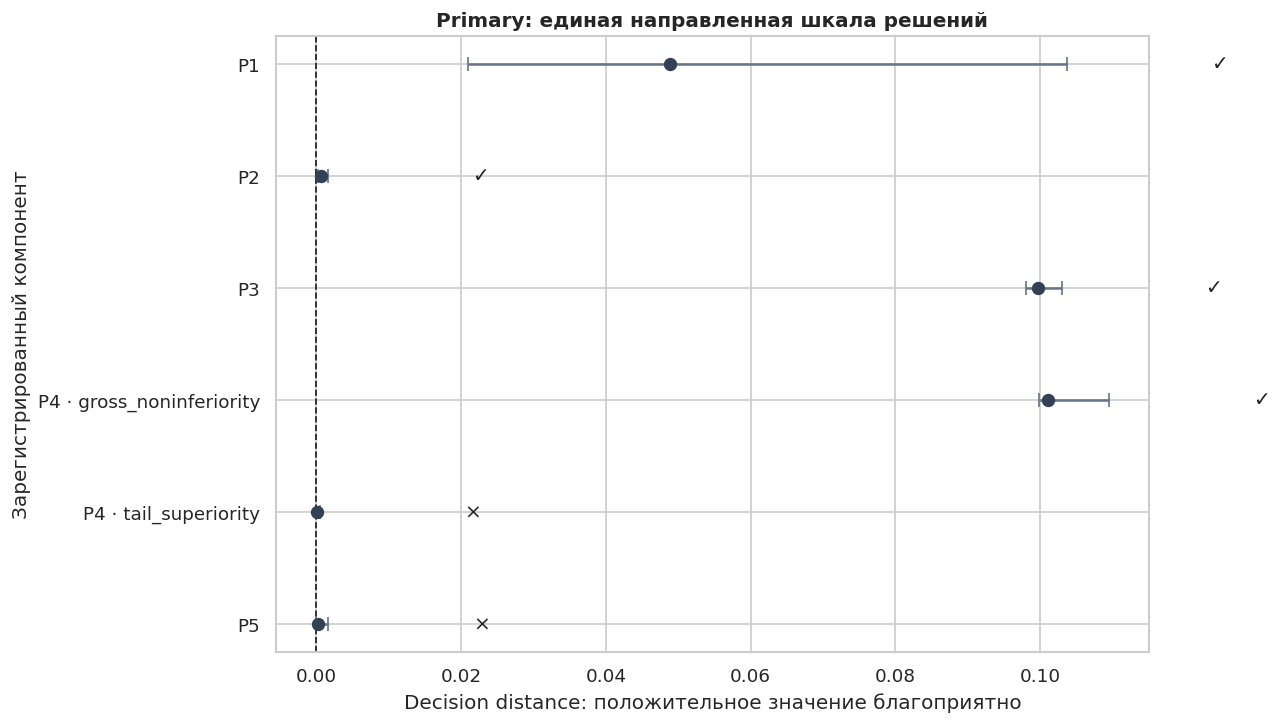

In [32]:
figure_data = PRIMARY_COMPONENT_RESULTS.copy()
figure_data["label"] = figure_data.id + np.where(figure_data.component.eq("main"), "", " · " + figure_data.component)
figure_data = figure_data.sort_values(["id", "component"])
y = np.arange(len(figure_data)); fig, ax = plt.subplots(figsize=(11, 6.2))
ax.errorbar(figure_data.decision_estimate, y,
            xerr=[figure_data.decision_estimate-figure_data.decision_ci_low,
                  figure_data.decision_ci_high-figure_data.decision_estimate],
            fmt="o", ecolor="#64748B", color="#334155", capsize=4, ms=7)
ax.axvline(0, color="#111827", ls="--", lw=1)
ax.set_yticks(y, figure_data.label); ax.invert_yaxis()
ax.set(xlabel="Decision distance: положительное значение благоприятно",
       ylabel="Зарегистрированный компонент", title="Primary: единая направленная шкала решений")
for yi, row in enumerate(figure_data.itertuples()):
    ax.text(row.decision_ci_high+.02, yi, "✓" if row.direction_supported else "×", va="center")
save_figure(fig, "01_primary_decision_distance", figure_data); FIGURE_STAGE.tick(note="1/8")


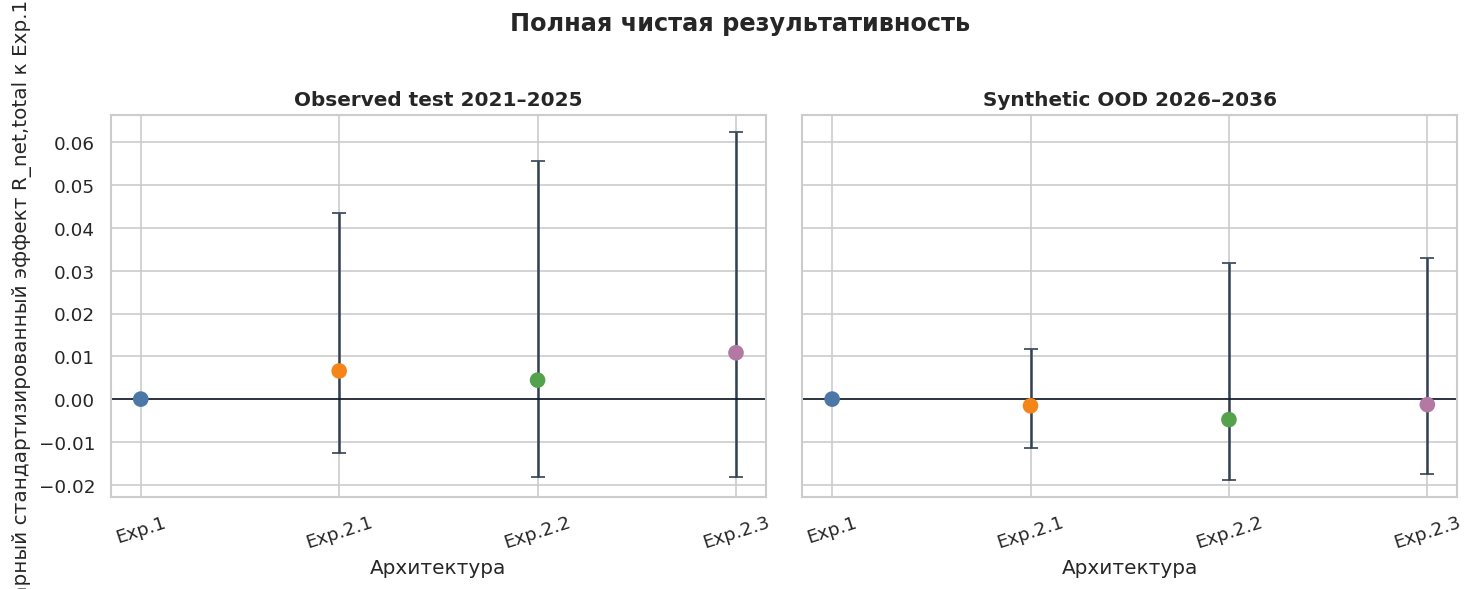

In [33]:
rows=[]
for split in ("observed_test", "synthetic_ood"):
    for architecture in ARCHITECTURES:
        if architecture == "Exp.1":
            rows.append({"split":split,"architecture":architecture,"estimate":0.,"ci_low":0.,"ci_high":0.})
        else:
            units,_=paired_architecture_units(EVAL_COALITION[EVAL_COALITION.split==split],"mean_r_net_total","Exp.1",architecture)
            lo,hi=hierarchical_seed_bootstrap_ci(units,"effect_sd",seed=stable_int_seed("figure2",split,architecture))
            rows.append({"split":split,"architecture":architecture,"estimate":iqm(units.effect_sd),"ci_low":lo,"ci_high":hi})
figure_data=pd.DataFrame(rows); fig,axes=plt.subplots(1,2,figsize=(12.5,4.8),sharey=True)
for ax,split,title in zip(axes,("observed_test","synthetic_ood"),("Observed test 2021–2025","Synthetic OOD 2026–2036")):
    block=figure_data[figure_data.split==split]; x=np.arange(len(block))
    ax.errorbar(x,block.estimate,yerr=[block.estimate-block.ci_low,block.ci_high-block.estimate],fmt="none",ecolor="#334155",capsize=4)
    ax.scatter(x,block.estimate,c=[ARCH_COLORS[a] for a in block.architecture],s=70,zorder=3); ax.axhline(0,color="#111827",lw=1)
    ax.set_xticks(x,block.architecture,rotation=18); ax.set_title(title); ax.set_xlabel("Архитектура")
axes[0].set_ylabel("Парный стандартизированный эффект R_net,total к Exp.1")
fig.suptitle("Полная чистая результативность",y=1.02,fontweight="semibold")
save_figure(fig,"02_net_effects_by_split",figure_data); FIGURE_STAGE.tick(note="2/8")


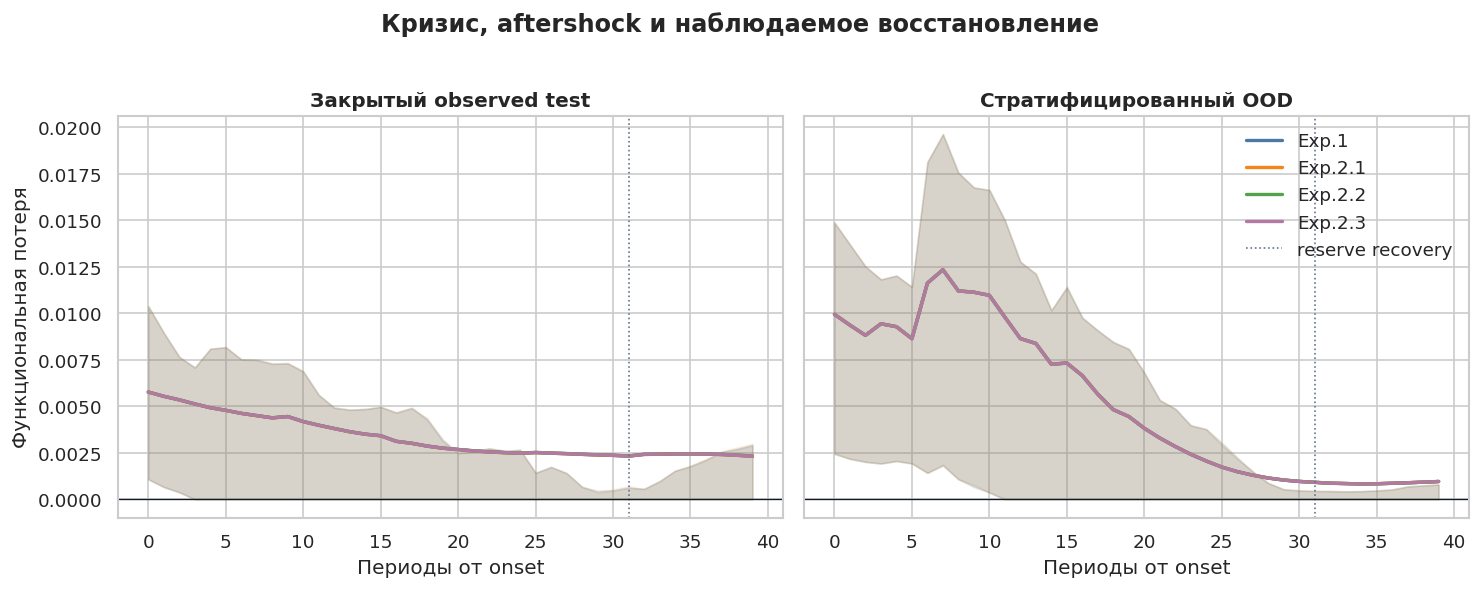

In [34]:
figure_data=LOSS_PROFILES.groupby(["split","architecture","event_time"],observed=True).loss.agg(mean="mean",q25=lambda x:x.quantile(.25),q75=lambda x:x.quantile(.75)).reset_index(); fig,axes=plt.subplots(1,2,figsize=(12.5,4.8),sharey=True)
for ax,split,title in zip(axes,("observed_test","synthetic_ood"),("Закрытый observed test","Стратифицированный OOD")):
    for architecture in ARCHITECTURES:
        block=figure_data[(figure_data.split==split)&(figure_data.architecture==architecture)]; ax.plot(block.event_time,block["mean"],color=ARCH_COLORS[architecture],lw=2,label=architecture); ax.fill_between(block.event_time,block.q25,block.q75,color=ARCH_COLORS[architecture],alpha=.10)
    ax.axvline(SHOCK_ENGINE.active_horizon,color="#64748B",ls=":",lw=1,label="reserve recovery"); ax.set(xlabel="Периоды от onset",title=title); ax.axhline(0,color="#111827",lw=.8)
axes[0].set_ylabel("Функциональная потеря"); axes[1].legend(frameon=False); fig.suptitle("Кризис, aftershock и наблюдаемое восстановление",y=1.02,fontweight="semibold"); save_figure(fig,"03_functional_loss_profiles",figure_data); FIGURE_STAGE.tick(note="3/8")


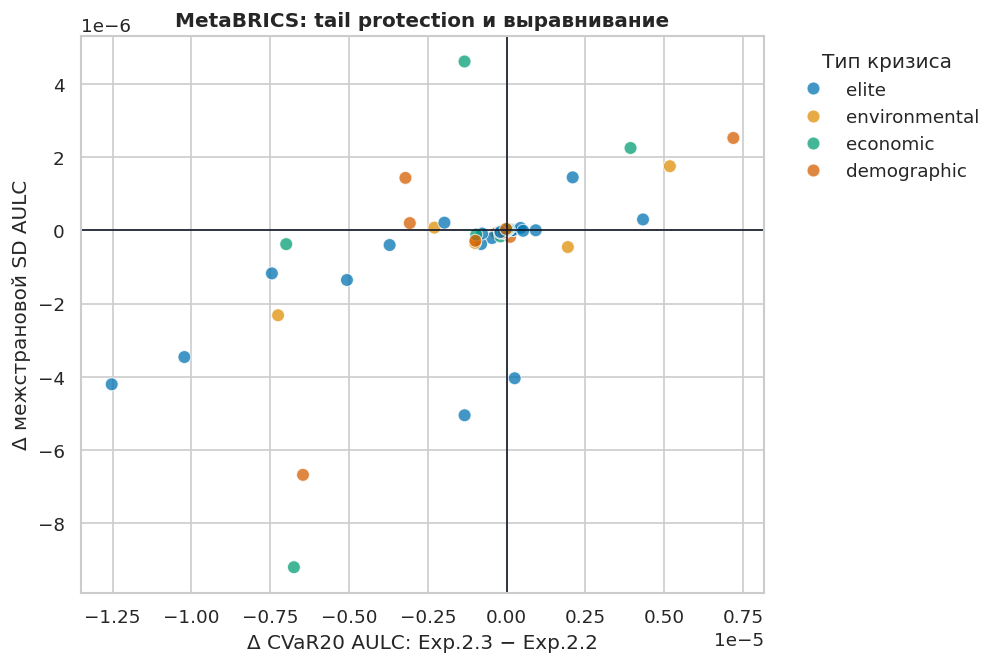

In [35]:
ood=LOSS_UNITS[LOSS_UNITS.split=="synthetic_ood"].pivot_table(index=["seed","scenario_id","crisis_type"],columns="architecture",values=["cvar20_aulc","aulc_dispersion"]).dropna()
figure_data=pd.DataFrame({"seed":ood.index.get_level_values("seed"),"scenario_id":ood.index.get_level_values("scenario_id"),"crisis_type":ood.index.get_level_values("crisis_type"),"delta_cvar20":ood[("cvar20_aulc","Exp.2.3")]-ood[("cvar20_aulc","Exp.2.2")],"delta_dispersion":ood[("aulc_dispersion","Exp.2.3")]-ood[("aulc_dispersion","Exp.2.2")]}).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(8.5,5.7)); sns.scatterplot(data=figure_data,x="delta_cvar20",y="delta_dispersion",hue="crisis_type",palette="colorblind",s=60,alpha=.75,ax=ax); ax.axvline(0,color="#111827",lw=1); ax.axhline(0,color="#111827",lw=1); ax.set(xlabel="Δ CVaR20 AULC: Exp.2.3 − Exp.2.2",ylabel="Δ межстрановой SD AULC",title="MetaBRICS: tail protection и выравнивание"); ax.legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left",title="Тип кризиса"); save_figure(fig,"04_coalition_protection_frontier",figure_data); FIGURE_STAGE.tick(note="4/8")


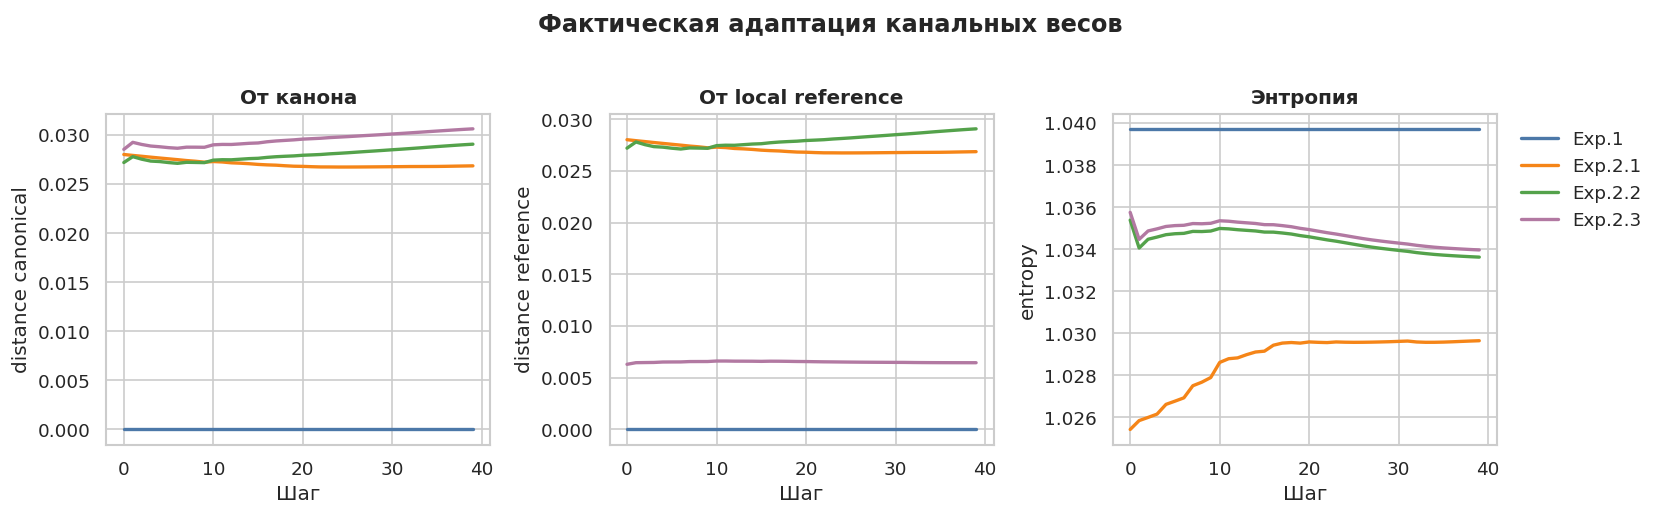

In [36]:
figure_data=EVAL_WEIGHTS.groupby(["architecture","step"],observed=True).agg(distance_canonical=("distance_from_canonical","mean"),distance_reference=("distance_from_reference","mean"),entropy=("weight_entropy","mean"),churn=("weight_change","mean")).reset_index(); panels=[("distance_canonical","От канона"),("distance_reference","От local reference"),("entropy","Энтропия")]; fig,axes=plt.subplots(1,3,figsize=(14,4.2))
for ax,(metric,title) in zip(axes,panels):
    for architecture in ARCHITECTURES:
        block=figure_data[figure_data.architecture==architecture]; ax.plot(block.step,block[metric],color=ARCH_COLORS[architecture],lw=2,label=architecture)
    ax.set(xlabel="Шаг",ylabel=metric.replace("_"," "),title=title)
axes[-1].legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left"); fig.suptitle("Фактическая адаптация канальных весов",y=1.02,fontweight="semibold"); save_figure(fig,"05_weight_adaptation_diagnostics",figure_data); FIGURE_STAGE.tick(note="5/8")


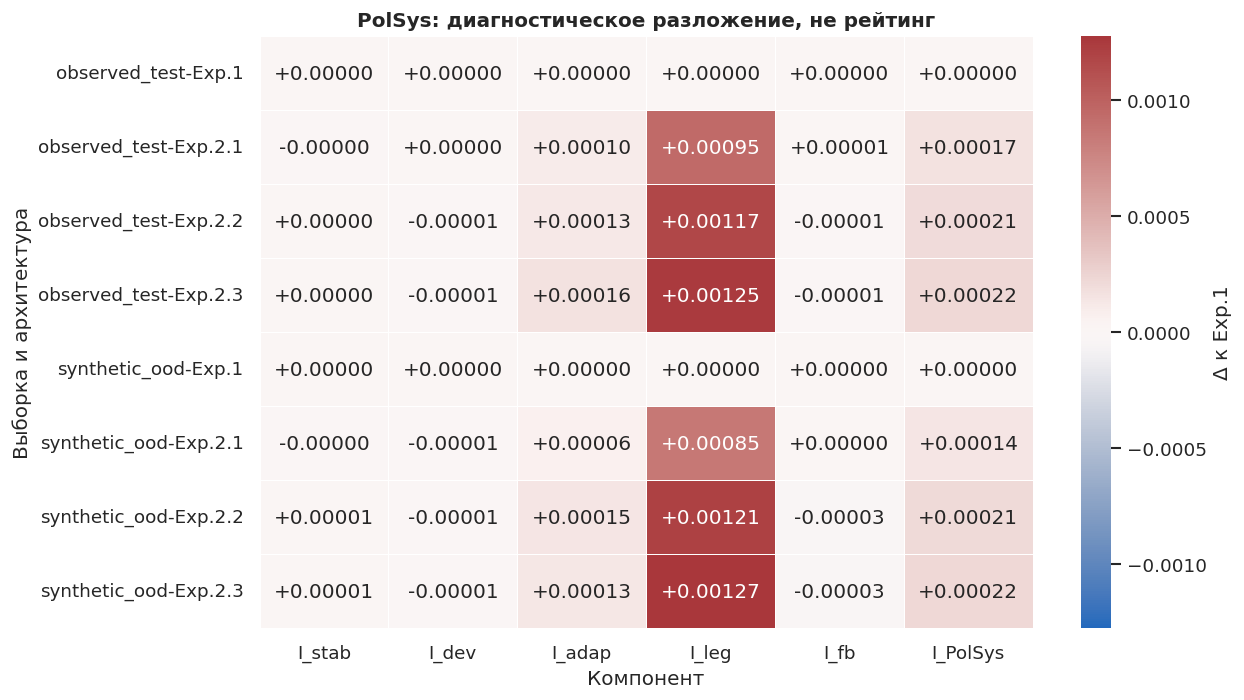

In [37]:
components=["I_stab","I_dev","I_adap","I_leg","I_fb","I_PolSys"]
means=POLSYS_FULL.groupby(["split","architecture"],observed=True)[components].mean().reset_index()
base=means[means.architecture=="Exp.1"].set_index("split")[components]; rows=[]
for row in means.itertuples(index=False):
    for component in components: rows.append({"split":row.split,"architecture":row.architecture,"component":component,"delta":getattr(row,component)-base.loc[row.split,component]})
figure_data=pd.DataFrame(rows); matrix=figure_data.pivot(index=["split","architecture"],columns="component",values="delta").reindex(columns=components)
limit=max(float(np.nanmax(np.abs(matrix.to_numpy()))),1e-5); fig,ax=plt.subplots(figsize=(10.5,6))
sns.heatmap(matrix,annot=True,fmt="+.5f",cmap="vlag",center=0,vmin=-limit,vmax=limit,linewidths=.5,cbar_kws={"label":"Δ к Exp.1"},ax=ax)
ax.set(xlabel="Компонент",ylabel="Выборка и архитектура",title="PolSys: диагностическое разложение, не рейтинг")
save_figure(fig,"06_polsys_components_delta",figure_data); FIGURE_STAGE.tick(note="6/8")


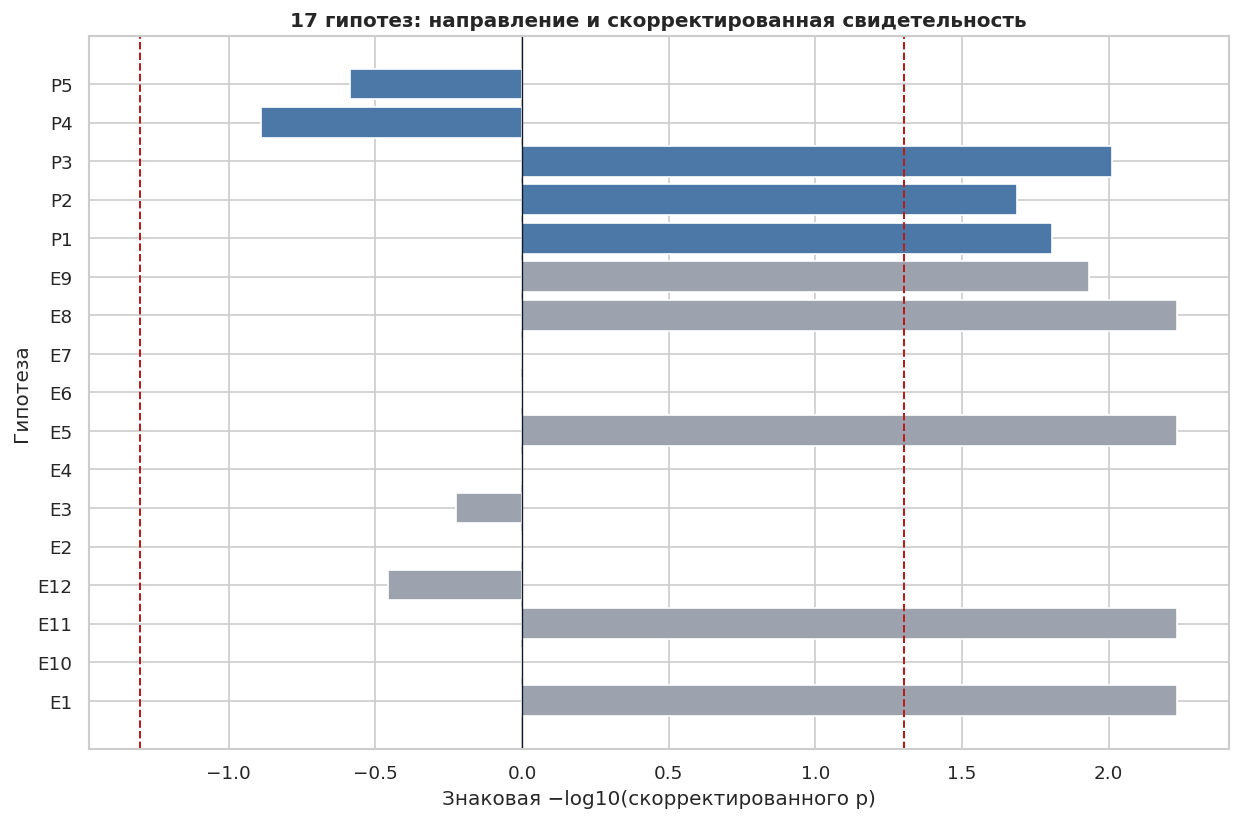

In [38]:
figure_data=HYPOTHESIS_RESULTS.copy(); figure_data["evidence"]=-np.log10(figure_data.p_adjusted.clip(lower=1e-12))
figure_data["signed_evidence"]=np.where(figure_data.direction_supported,1.,-1.)*figure_data.evidence
figure_data=figure_data.sort_values(["family","id"]); fig,ax=plt.subplots(figsize=(10.5,7))
colors=np.where(figure_data.family=="primary","#4C78A8","#9CA3AF")
ax.barh(figure_data.id,figure_data.signed_evidence,color=colors); threshold=-math.log10(.05)
ax.axvline(threshold,color="#B91C1C",ls="--",lw=1.2); ax.axvline(-threshold,color="#B91C1C",ls="--",lw=1.2); ax.axvline(0,color="#111827",lw=.8)
ax.set(xlabel="Знаковая −log10(скорректированного p)",ylabel="Гипотеза",title="17 гипотез: направление и скорректированная свидетельность")
save_figure(fig,"07_hypothesis_evidence",figure_data); FIGURE_STAGE.tick(note="7/8")


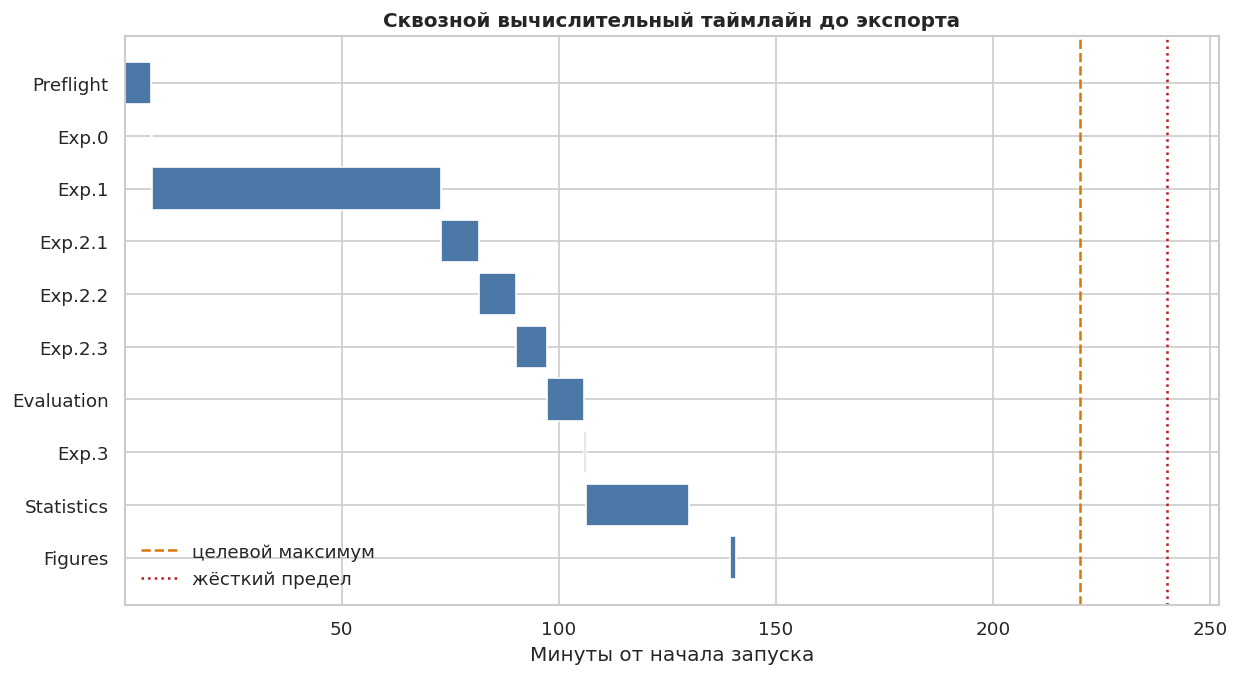

In [39]:
FIGURE_STAGE.tick(note="8/8"); FIGURE_STAGE.__exit__(None,None,None)
figure_data=PROGRESS.frame().copy(); figure_data=figure_data[figure_data.status.isin(["completed","resumed"])].sort_values("started_min").drop_duplicates("stage",keep="last")
fig,ax=plt.subplots(figsize=(10.5,5.8)); y=np.arange(len(figure_data)); ax.barh(y,figure_data.duration_min,left=figure_data.started_min,color="#4C78A8")
ax.set_yticks(y,figure_data.stage); ax.invert_yaxis(); ax.set(xlabel="Минуты от начала запуска",ylabel="",title="Сквозной вычислительный таймлайн до экспорта")
ax.axvline(CFG.target_runtime_max,color="#D97706",ls="--",label="целевой максимум"); ax.axvline(CFG.hard_runtime_min,color="#B91C1C",ls=":",label="жёсткий предел"); ax.legend(frameon=False)
save_figure(fig,"08_runtime_timeline",figure_data)


## 22. Атомарный Excel/Parquet/ZIP-экспорт

Шесть Excel-книг разделяют интерпретацию, единицы вывода, механизмы, полный аудит E1–E12, PolSys и данные фигур. После записи каждая книга открывается повторно и проверяется. ZIP создаётся во временный файл, проходит `testzip()`, затем атомарно публикуется. Checkpoints и cache не включаются.


In [40]:
EXCEL_MAX_DATA_ROWS=1_048_000


def excel_safe(frame:pd.DataFrame)->pd.DataFrame:
    out=frame.copy()
    for column in out.select_dtypes(include=["object"]).columns: out[column]=out[column].map(lambda x:json.dumps(x,ensure_ascii=False) if isinstance(x,(dict,list,tuple,set)) else x)
    return out.replace([np.inf,-np.inf],np.nan)


def write_styled_sheet(writer:pd.ExcelWriter,name:str,frame:pd.DataFrame,startrow:int=0)->None:
    safe=excel_safe(frame); safe.to_excel(writer,sheet_name=name[:31],index=False,startrow=startrow); worksheet,workbook=writer.sheets[name[:31]],writer.book
    header=workbook.add_format({"bold":True,"font_color":"white","bg_color":"#1F4E78","text_wrap":True,"valign":"top"})
    for col,value in enumerate(safe.columns):
        worksheet.write(startrow,col,value,header); sample=safe[value].astype(str).head(200) if len(safe) else pd.Series(dtype=str); width=min(42,max(11,len(str(value))+2,int(sample.str.len().quantile(.90))+2 if len(sample) else 11)); worksheet.set_column(col,col,width)
    worksheet.freeze_panes(startrow+1,0)
    if len(safe): worksheet.autofilter(startrow,0,startrow+len(safe),len(safe.columns)-1)


def write_chunked_sheet(writer:pd.ExcelWriter,base_name:str,frame:pd.DataFrame)->list[str]:
    names=[]
    for part,start in enumerate(range(0,max(1,len(frame)),EXCEL_MAX_DATA_ROWS),start=1):
        name=base_name if len(frame)<=EXCEL_MAX_DATA_ROWS else f"{base_name}_{part:02d}"; write_styled_sheet(writer,name,frame.iloc[start:start+EXCEL_MAX_DATA_ROWS]); names.append(name[:31])
    return names


def write_workbook(path:Path,sheets:Mapping[str,pd.DataFrame])->Path:
    with pd.ExcelWriter(path,engine="xlsxwriter",engine_kwargs={"options":{"nan_inf_to_errors":True,"strings_to_urls":False}}) as writer:
        for name,frame in sheets.items(): write_chunked_sheet(writer,name,frame)
        writer.book.set_properties({"title":f"{CFG.project} {CFG.version}","subject":"Counterfactual political-science experiment","author":"BRICS–PolSys MARL research pipeline","comments":"Model-internal counterfactual experiment; not a forecast or country ranking."})
    return path


def readme_frame(rows:Sequence[tuple[str,str]])->pd.DataFrame: return pd.DataFrame(rows,columns=["Раздел","Описание"])


def penalty_ablation_table(trajectories:pd.DataFrame)->pd.DataFrame:
    variants={"baseline":(CFG.coord_penalty,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),"coord_0x":(0.,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),"coord_2x":(2*CFG.coord_penalty,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),"uncertainty_0x":(CFG.coord_penalty,0.,CFG.proxy_drift_penalty),"uncertainty_2x":(CFG.coord_penalty,2*CFG.uncertainty_penalty,CFG.proxy_drift_penalty),"proxy_drift_0x":(CFG.coord_penalty,CFG.uncertainty_penalty,0.),"proxy_drift_2x":(CFG.coord_penalty,CFG.uncertainty_penalty,2*CFG.proxy_drift_penalty)}; rows=[]
    for name,(coord,uncertainty,drift) in variants.items():
        temp=trajectories[["seed","architecture","split","scenario_id"]].copy(); temp["r_net_ablation"]=trajectories.r_gross-coord*trajectories.coordination_cost_total-uncertainty*trajectories.uncertainty-drift*trajectories.proxy_drift
        agg=temp.groupby(["seed","architecture","split","scenario_id"],observed=True).r_net_ablation.mean().reset_index(); agg["variant"],agg["coord_coef"],agg["uncertainty_coef"],agg["proxy_drift_coef"]=name,coord,uncertainty,drift; rows.append(agg)
    return pd.concat(rows,ignore_index=True)


def seed_point_table(frame:pd.DataFrame)->pd.DataFrame:
    return frame.groupby(["seed","architecture","split"],observed=True).agg(mean_r_net_total=("mean_r_net_total","mean"),mean_r_gross=("mean_r_gross","mean"),median_r_net_total=("mean_r_net_total","median"),bottom20_r_net_total=("bottom20_r_net_total","mean"),country_r_net_total_sd=("country_r_net_total_sd","mean"),mean_proxy_drift=("mean_proxy_drift","mean"),mean_coordination_cost_total=("mean_coordination_cost_total","mean")).reset_index()


def scenario_registry_table()->pd.DataFrame:
    rows=[]
    for split in ("observed_test","synthetic_ood"):
        for scenario in EVAL_SCENARIOS[split]: rows.append({"split":split,"scenario_id":scenario.scenario_id,"scenario_name":scenario.name,"start_year":scenario.start_year,"end_year":scenario.end_year,"crisis_type":scenario.crisis_type,"crisis_ids":";".join(str(c.id) for c in scenario.crises),"n_crises":len(scenario.crises),"compound":scenario.compound,"stress_multiplier":scenario.stress_multiplier,"aftershock_ratio":scenario.aftershock_ratio,"tail_decay":scenario.tail_decay,"recovery_reserve_steps":CFG.recovery_reserve_steps})
    return pd.DataFrame(rows)


def mechanism_unit_table()->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","country"]; columns=keys+["aulc","peak_loss","persistent_loss_share","late_loss","recovery_time","rmst_contribution","event_observed","baseline_functional","recovery_tolerance"]
    return EVAL_COUNTRY.merge(RECOVERY[columns],on=keys,how="left",validate="one_to_one")


def weight_summaries(weights:pd.DataFrame)->tuple[pd.DataFrame,pd.DataFrame]:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country"]
    unit=weights.groupby(keys,observed=True).agg(deeds_mean=("weight_deeds","mean"),words_mean=("weight_words","mean"),images_mean=("weight_images","mean"),deeds_sd=("weight_deeds","std"),words_sd=("weight_words","std"),images_sd=("weight_images","std"),canonical_distance=("distance_from_canonical","mean"),reference_distance=("distance_from_reference","mean"),entropy_mean=("weight_entropy","mean"),churn=("weight_change","mean")).reset_index()
    step=weights.groupby(["architecture","split","step"],observed=True).agg(deeds_mean=("weight_deeds","mean"),words_mean=("weight_words","mean"),images_mean=("weight_images","mean"),canonical_distance=("distance_from_canonical","mean"),reference_distance=("distance_from_reference","mean"),entropy_mean=("weight_entropy","mean"),churn=("weight_change","mean")).reset_index(); return unit,step


In [41]:
def compact_audit_frames() -> dict[str, pd.DataFrame]:
    result = {}
    for key, frame in EXPLORATORY_AUDIT.items():
        compact = frame.copy()
        if len(compact) > 250_000 and not CFG.export_full_mechanism_steps:
            compact = compact.groupby([c for c in ["seed","architecture","split","scenario_id","country"] if c in compact], observed=True).mean(numeric_only=True).reset_index()
        result[key] = compact
    return result


PENALTY_ABLATIONS = penalty_ablation_table(EVAL_TRAJECTORIES)
SEED_POINTS = seed_point_table(EVAL_COALITION)
SCENARIO_REGISTRY = scenario_registry_table()
MECHANISM_UNITS = mechanism_unit_table()
WEIGHT_UNITS, WEIGHT_STEPS = weight_summaries(EVAL_WEIGHTS)
MECHANISM_AUDIT = compact_audit_frames()
training_summary = pd.concat([
    EXP1_TRAINING.groupby("seed").agg(iterations=("episode","count"),best_validation=("validation_reward","max")).assign(stage="Exp.1").reset_index(),
    EXP21_TRAINING.groupby("seed").agg(iterations=("round","count"),best_validation=("best_fitness","max")).assign(stage="Exp.2.1").reset_index(),
    EXP22_TRAINING.groupby("seed").agg(iterations=("round","count"),best_validation=("best_fitness","max")).assign(stage="Exp.2.2").reset_index(),
    EXP23_TRAINING.groupby("seed").agg(iterations=("round","count"),best_validation=("best_objective","max")).assign(stage="Exp.2.3").reset_index(),
], ignore_index=True)
RUN_METADATA.update({"finished_utc":pd.Timestamp.utcnow().isoformat(),"elapsed_minutes_before_export":round(PROGRESS.elapsed_min(),2),
                     "action_order_sha256":hashlib.sha256("\n".join(ACTION_NAMES).encode("utf-8")).hexdigest(),
                     "n_coalition_units":len(EVAL_COALITION),"n_country_units":len(EVAL_COUNTRY),"n_step_rows":len(EVAL_TRAJECTORIES)})
EXPORT_STAGE=PROGRESS.stage("Export"); EXPORT_STAGE.__enter__(); EXPORT_STAGE.tick(note="аналитические сводки")


In [42]:
state_dictionary=pd.DataFrame([{"position":i,"name":name,"block":next(block for block,names in STATE_BLOCKS.items() if name in names),"definition":STATE_DEFINITIONS[name],"orientation":"negative" if name in NEGATIVE_STATE_FEATURES else "neutral" if name in NEUTRAL_STATE_FEATURES else "positive"} for i,name in enumerate(STATE_NAMES)])
action_dictionary=pd.DataFrame([{"position":i,"name":name,"group":next(group for group,idx in ACTION_GROUPS.items() if i in idx),"definition":ACTION_DEFINITIONS[name]} for i,name in enumerate(ACTION_NAMES)])
design=pd.DataFrame([{"parameter":key,"value":json.dumps(value,ensure_ascii=False) if isinstance(value,(dict,list,tuple)) else value} for key,value in {**asdict(CFG),"selected_profile":asdict(PROFILE),"world_dynamics_mode":WORLD_DYNAMICS_MODE,"architectures":ARCHITECTURE_LABELS}.items()])
overview_readme=readme_frame([("Назначение","Главная книга дизайна, endpoint, потерь и 17 гипотез V10."),("Temporal design","Gate: ≤2018 / 2019–2020; closed observed test: 2021–2025."),("Primary","P1–P5; Holm; независимая единица seed."),("Exploratory","E1–E12; BH-FDR; механизмные модельные связи."),("Ограничение","Контрфактический эксперимент; не прогноз и не рейтинг государств.")])
OVERVIEW_PATH=write_workbook(XLSX_DIR/"01_Overview.xlsx",{"README":overview_readme,"Run_Metadata":pd.DataFrame([{"key":k,"value":v} for k,v in RUN_METADATA.items()]),"Design":design,"Scenario_Registry":SCENARIO_REGISTRY,"State_Ontology":state_dictionary,"Action_Ontology":action_dictionary,"World_Model_Validation":WM_METRICS,"Architecture_Summary":ENDPOINT_SUMMARY,"Loss_Summary":LOSS_ENDPOINT_SUMMARY,"Seed_Points":SEED_POINTS,"Training_Summary":training_summary,"Penalty_Ablations":PENALTY_ABLATIONS,"Primary_Components":PRIMARY_COMPONENT_RESULTS,"Hypotheses":HYPOTHESIS_RESULTS}); EXPORT_STAGE.tick(note="01_Overview.xlsx")


In [43]:
inference_readme=readme_frame([("Coalition_Episodes","Primary-level seed × scenario × architecture."),("Country_Episodes","Страны вложены в seed; таблица не является рейтингом."),("Recovery_Country","Censoring, RMST, AULC и устойчивое восстановление."),("Coalition_Loss","Mean, CVaR20, dispersion, Gini и RMST.")])
INFERENCE_PATH=write_workbook(XLSX_DIR/"02_Inference_Units.xlsx",{"README":inference_readme,"Coalition_Episodes":EVAL_COALITION,"Country_Episodes":EVAL_COUNTRY,"Recovery_Country":RECOVERY,"Coalition_Loss":LOSS_UNITS}); EXPORT_STAGE.tick(note="02_Inference_Units.xlsx")
mechanism_readme=readme_frame([("Mechanism_Units","Страновой эпизод: outcome, shock, preconditions и recovery."),("Weight_Units","Веса, расстояния, entropy и churn."),("Mechanism_Evidence","E1–E12 после BH-FDR."),("Полный аудит","Точные расчётные строки находятся в 04_Mechanism_Audit.xlsx.")])
MECHANISM_PATH=write_workbook(XLSX_DIR/"03_Mechanisms_Compact.xlsx",{"README":mechanism_readme,"Mechanism_Units":MECHANISM_UNITS,"Weight_Units":WEIGHT_UNITS,"Weight_Steps":WEIGHT_STEPS,"Mechanism_Evidence":HYPOTHESIS_RESULTS[HYPOTHESIS_RESULTS.family=="exploratory"]}); EXPORT_STAGE.tick(note="03_Mechanisms_Compact.xlsx")


In [44]:
audit_index=pd.DataFrame([{"hypothesis":key,"rows":len(frame),"columns":";".join(frame.columns),"cluster":"seed"} for key,frame in MECHANISM_AUDIT.items()])
audit_sheets={"README":readme_frame([("Назначение","Точные строки и переменные расчёта E1–E12."),("Кластер","Десять seed; scenario/country/step вложены."),("Воспроизведение","Exact wild signs или зарегистрированный hierarchical bootstrap.")]),"Audit_Index":audit_index,**{f"Audit_{key}":frame for key,frame in MECHANISM_AUDIT.items()}}
MECHANISM_AUDIT_PATH=write_workbook(XLSX_DIR/"04_Mechanism_Audit.xlsx",audit_sheets); EXPORT_STAGE.tick(note="04_Mechanism_Audit.xlsx")
component_definitions=pd.DataFrame([("I_stab","функциональная стабильность и ограничение риска",.25),("I_dev","развитие и операциональный канал",.20),("I_adap","AULC, peak и persistent loss",.25),("I_leg","легитимность, доверие и слова",.15),("I_fb","обратная связь без proxy drift и word–deed gap",.15),("I_resilience","стабильность, адаптация и feedback",np.nan),("I_capacity","развитие и легитимность",np.nan),("I_PolSys","диагностическая композиция пяти компонентов",1.),("dominant_component_share","доля крупнейшего компонента в абсолютной дельте",np.nan)],columns=["component","definition","weight"])
POLSYS_PATH=write_workbook(XLSX_DIR/"05_PolSys.xlsx",{"README":readme_frame([("PolSys_Full","seed × architecture × split × scenario × country."),("Dominance","Флаг >0.75 предупреждает об одном доминирующем компоненте."),("Интерпретация","Эндогенная диагностика; не универсальная шкала режимов и не рейтинг.")]),"Component_Definitions":component_definitions,"PolSys_Full":POLSYS_FULL,"PolSys_Summary":POLSYS_SUMMARY}); EXPORT_STAGE.tick(note="05_PolSys.xlsx")


In [45]:
figure_readme=readme_frame([(slug,f"Точный источник фигуры {slug}; PNG/SVG находятся в figures.") for slug in FIGURE_DATA]); figure_sheets={"README":figure_readme}
for index,(slug,frame) in enumerate(FIGURE_DATA.items(),start=1): figure_sheets[f"F{index:02d}_{slug[3:25]}"]=frame
FIGURE_DATA_PATH=write_workbook(XLSX_DIR/"06_Figure_Data.xlsx",figure_sheets); EXPORT_STAGE.tick(note="06_Figure_Data.xlsx")

# Машиночитаемые компактные артефакты.
DATA_DIR=ROOT/"data"; DATA_DIR.mkdir(exist_ok=True)
for name,frame in {"hypotheses":HYPOTHESIS_RESULTS,"primary_components":PRIMARY_COMPONENT_RESULTS,"coalition_units":EVAL_COALITION,"loss_units":LOSS_UNITS,"polsys":POLSYS_FULL,"progress":PROGRESS.frame()}.items():
    path=DATA_DIR/f"{name}.parquet"; tmp=path.with_suffix(".tmp.parquet"); frame.to_parquet(tmp,index=False); tmp.replace(path)
EXPORT_STAGE.tick(note="Parquet")


In [46]:
def sha256_file(path: Path) -> str:
    h=hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda:stream.read(1024*1024),b""): h.update(chunk)
    return h.hexdigest()


readme_text=f"""# BRICS–PolSys MARL v{CFG.version}: результаты

Контрфактический политологический многоагентный эксперимент; не прогноз и не рейтинг государств.

## Порядок чтения
1. `excel/01_Overview.xlsx` — дизайн, gate, endpoint, потери, P1–P5 и E1–E12.
2. `excel/02_Inference_Units.xlsx` — seed×scenario, censored recovery и распределительные потери.
3. `excel/03_Mechanisms_Compact.xlsx` — механизм-единицы и диагностика весов.
4. `excel/04_Mechanism_Audit.xlsx` — точные строки E1–E12.
5. `excel/05_PolSys.xlsx` — диагностические компоненты и dominance.
6. `excel/06_Figure_Data.xlsx` — точные источники восьми графиков.

Primary: Holm. Exploratory: BH-FDR. Независимая единица — seed.
World dynamics: {WORLD_DYNAMICS_MODE}. Outer observed test 2021–2025 не использован при gate.
Профиль: {PROFILE.name}. Сиды: {', '.join(map(str,CFG.seeds))}. Горизонт: {CFG.horizon}.
"""
(GUIDE_DIR/"README_RESULTS.md").write_text(textwrap.dedent(readme_text),encoding="utf-8")
(GUIDE_DIR/"ARCHIVE_CONTENTS.md").write_text("""# Содержание архива

- `excel/` — шесть проверенных книг;
- `figures/` — восемь PNG/SVG;
- `data/` — компактные Parquet;
- `guides/` — правила чтения;
- `artifact_manifest.json` — SHA-256 и размеры.

Checkpoints, optimizers и cache исключены.
""",encoding="utf-8")

# Повторное открытие всех Excel до публикации.
for path in sorted(XLSX_DIR.glob("*.xlsx")):
    book=pd.ExcelFile(path)
    if not book.sheet_names: raise IOError(f"Пустая книга {path.name}")
EXPORT_STAGE.tick(note="Excel validation")

manifest=[]
for path in sorted(p for p in ROOT.rglob("*") if p.is_file()):
    manifest.append({"path":str(path.relative_to(ROOT)),"bytes":path.stat().st_size,"sha256":sha256_file(path)})
atomic_json(ROOT/"artifact_manifest.json",{"project":CFG.project,"version":CFG.version,"namespace":RUN_NAMESPACE,"files":manifest})
EXPORT_STAGE.tick(note="manifest")

ARCHIVE_PATH=Path("/content")/"BRICS_PolSys_MARL_v10_0_results.zip"
TEMP_ARCHIVE_PATH=ARCHIVE_PATH.with_suffix(".tmp.zip")
TEMP_ARCHIVE_PATH.unlink(missing_ok=True)
with zipfile.ZipFile(TEMP_ARCHIVE_PATH,"w",compression=zipfile.ZIP_DEFLATED,compresslevel=7) as archive:
    for path in sorted(ROOT.rglob("*")):
        if path.is_file(): archive.write(path,path.relative_to(ROOT.parent))
with zipfile.ZipFile(TEMP_ARCHIVE_PATH,"r") as archive:
    bad=archive.testzip()
    if bad is not None: raise IOError(f"ZIP CRC error: {bad}")
TEMP_ARCHIVE_PATH.replace(ARCHIVE_PATH)
EXPORT_STAGE.tick(note="atomic ZIP"); EXPORT_STAGE.__exit__(None,None,None); PROGRESS.close()
if not CFG.keep_checkpoints and CHECKPOINT_DIR.exists(): shutil.rmtree(CHECKPOINT_DIR)
print(f"Архив: {ARCHIVE_PATH} · {ARCHIVE_PATH.stat().st_size/1024**2:.1f} MB")
print(PROGRESS.frame()[["stage","duration_min","completed_units","unused_units","status"]].to_string(index=False))


Архив: /content/BRICS_PolSys_MARL_v10_0_results.zip · 516.8 MB
     stage  duration_min  completed_units  unused_units    status
 Preflight      6.183553                7             1 completed
     Exp.0      0.094139              415           435 completed
     Exp.1     66.592630             3776          1424 completed
   Exp.2.1      8.631348              452           348 completed
   Exp.2.2      8.667441              458           342 completed
   Exp.2.3      7.188378              578           322 completed
Evaluation      8.332192              360             0 completed
     Exp.3      0.563568                5             0 completed
Statistics     23.731485               17             0 completed
   Figures      1.400888                8             0 completed
    Export     11.832071                8             0 completed


In [47]:
if not ARCHIVE_PATH.exists() or ARCHIVE_PATH.stat().st_size == 0:
    raise FileNotFoundError("Финальный ZIP не создан")
try:
    from google.colab import files
    files.download(str(ARCHIVE_PATH))
except ImportError:
    print(f"Загрузка доступна в Colab; локальный путь: {ARCHIVE_PATH}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 23. GitHub-релиз

Рекомендуемый порядок:

1. `File → Save a copy in GitHub` для исполненного notebook.
2. Сопоставить SHA-256 notebook с release notes.
3. Приложить итоговый ZIP как release asset.
4. Не коммитить `work/`, checkpoints, cache или исходные данные с ограничениями распространения.
5. GitHub Actions проверяет синтаксис всех code cells и unit-тесты статистического ядра; полный production-run выполняется в Colab с исходными книгами и GPU.
